In [226]:

# Imports & configuration
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set results folders for Group 4
FORECAST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4"               # forward forecasts
BACKTEST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4"      # rolling backtests

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "homosex"

# Group columns used throughout
GROUP_COLS = ["generation","gender","race","edu_level"]

# Label sets
ABORT4   = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "abortion":
    CATS = ABORT4
    OUTCOME_PREFIX = "abortion"
elif OUTCOME == "homosex":
    CATS = HOMOSEX4
    OUTCOME_PREFIX = "homosex"
else:
    raise ValueError("Set OUTCOME to 'abortion' or 'homosex'.")

In [227]:
# Loaders (forecasts & backtests)
def load_forecasts(forecast_dir, outcome_key):
    """
    Loads all forecast CSVs matching forecasts_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(forecast_dir, f"forecasts_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No forecast files found: {pattern}")
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"forecasts_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "target_year" in df.columns: df["target_year"] = df["target_year"].astype(int)
        if "anchor_year" in df.columns: df["anchor_year"] = df["anchor_year"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

def load_backtests(backtest_dir, outcome_key):
    """
    Loads all backtest CSVs matching backtest_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(backtest_dir, f"backtest_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[warn] No backtest files found: {pattern}")
        return pd.DataFrame()
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"backtest_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "year_t" in df.columns: df["year_t"] = df["year_t"].astype(int)
        if "year_t1" in df.columns: df["year_t1"] = df["year_t1"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

df_fore = load_forecasts(FORECAST_DIR, OUTCOME)
df_back = load_backtests(BACKTEST_DIR, OUTCOME)

print("Forecasts:", df_fore.shape, "Backtests:", df_back.shape)
print("Experiments (forecasts):", sorted(df_fore["experiment"].unique().tolist()))
if not df_back.empty:
    print("Experiments (backtests):", sorted(df_back["experiment"].unique().tolist()))

Forecasts: (1301, 30) Backtests: (1411, 30)
Experiments (forecasts): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']
Experiments (backtests): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']


In [228]:
# Helpers to go long/tidy
def melt_probs(df_in, columns_prefix, cats, id_cols):
    cols = [f"{columns_prefix}_{c}" for c in cats if f"{columns_prefix}_{c}" in df_in.columns]
    if not cols:
        return None
    sub = df_in[id_cols + cols].copy()
    long = sub.melt(
        id_vars=id_cols,
        value_vars=cols,
        var_name="category",
        value_name=columns_prefix
    )
    long["category"] = long["category"].str.replace(f"{columns_prefix}_", "", regex=False)
    return long

def list_groups(df_any):
    if df_any.empty: return []
    return df_any[GROUP_COLS].drop_duplicates().apply(tuple, axis=1).tolist()

In [229]:
# Build long frames
# Forecasts use 'target_year' (and 'anchor_year')
ID_F = ["experiment"] + GROUP_COLS + ["target_year","anchor_year"]

long_hat_f   = melt_probs(df_fore, "p_hat",   CATS, id_cols=ID_F)
long_trans_f = melt_probs(df_fore, "p_trans", CATS, id_cols=ID_F)
long_marg_f  = melt_probs(df_fore, "p_margin",CATS, id_cols=ID_F)
long_obs_f   = melt_probs(df_fore, "p_obs",   CATS, id_cols=ID_F)

frames_f = [x for x in [long_hat_f, long_trans_f, long_marg_f, long_obs_f] if x is not None]
df_fore_long = frames_f[0]
for f in frames_f[1:]:
    df_fore_long = df_fore_long.merge(
        f, on=ID_F+["category"], how="left"
    )

# Backtests use 'year_t1' for the target year
if not df_back.empty:
    ID_B = ["experiment"] + GROUP_COLS + ["year_t","year_t1"]
    long_hat_b   = melt_probs(df_back, "p_hat",   CATS, id_cols=ID_B)
    long_trans_b = melt_probs(df_back, "p_trans", CATS, id_cols=ID_B)
    long_marg_b  = melt_probs(df_back, "p_margin",CATS, id_cols=ID_B)
    long_obs_b   = melt_probs(df_back, "p_obs",   CATS, id_cols=ID_B)

    frames_b = [x for x in [long_hat_b, long_trans_b, long_marg_b, long_obs_b] if x is not None]
    if frames_b:
        df_back_long = frames_b[0]
        for f in frames_b[1:]:
            df_back_long = df_back_long.merge(
                f, on=ID_B+["category"], how="left"
            )
    else:
        df_back_long = pd.DataFrame()
else:
    df_back_long = pd.DataFrame()

print("Long forecast shape:", df_fore_long.shape)
print("Long backtest shape:", df_back_long.shape)

Long forecast shape: (5204, 12)
Long backtest shape: (5644, 12)


In [230]:
# # Per-group plotting: Forecasts
# def plot_forecast_for_group(
#     group_tuple, df_fore_long, cats=CATS, show_components=False, save_path=None
# ):
#     """
#     Clean plot: Observed vs LLM p_hat only.
#     Adds shaded training window per experiment.
#     """

#     if df_fore_long.empty:
#         print("No forecast data.")
#         return

#     # filter to the selected group
#     mask = np.ones(len(df_fore_long), dtype=bool)
#     for col, val in zip(GROUP_COLS, group_tuple):
#         mask &= (df_fore_long[col] == val)
#     dfg = df_fore_long.loc[mask].copy()
#     if dfg.empty:
#         print("No rows for group:", group_tuple)
#         return

#     # identify experiments
#     exps = sorted(dfg["experiment"].unique())

#     # parse training cutoff from experiment name (like exp_A_train_le_2022)
#     cutoff_years = {}
#     for exp in exps:
#         yr = None
#         for y in [2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022]:
#             if str(y) in exp:
#                 yr = y
#                 break
#         cutoff_years[exp] = yr

#     n_panels = len(cats)
#     nrows = 2 if n_panels > 2 else 1
#     ncols = (n_panels + nrows - 1) // nrows
#     fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.6*nrows), sharex=True, sharey=True)
#     axes = np.atleast_1d(axes).ravel()

#     group_label = "; ".join(f"{c}={v}" for c, v in zip(GROUP_COLS, group_tuple))
#     fig.suptitle(f"[Forecasts] {OUTCOME_PREFIX.upper()} — {group_label}", y=1.02, fontsize=12)

#     palette = ["#e14b31", "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#17becf"]

#     for i, cat in enumerate(cats):
#         ax = axes[i]
#         # observed line (shared across experiments)
#         d_obs = dfg[dfg["category"] == cat].dropna(subset=["p_obs"]).sort_values("target_year")
#         if not d_obs.empty:
#             ax.plot(
#                 d_obs["target_year"], d_obs["p_obs"],
#                 marker="o", linestyle="-", color="black", linewidth=1.6, label="Observed"
#             )

#         # plot p_hat for each experiment
#         for j, exp in enumerate(exps):
#             de = (
#                 dfg[(dfg["category"] == cat) & (dfg["experiment"] == exp)]
#                 .sort_values("target_year")
#             )
#             if "p_hat" not in de.columns or de["p_hat"].isna().all():
#                 continue
#             color = palette[j % len(palette)]
#             ax.plot(
#                 de["target_year"], de["p_hat"],
#                 marker="^", linestyle=":", linewidth=1.8, color=color, label=f"{exp}"
#             )

#             # add shaded training area (before cutoff)
#             cutoff = cutoff_years.get(exp)
#             if cutoff is not None:
#                 ax.axvspan(2006, cutoff, color=color, alpha=0.08)

#         # aesthetics
#         ax.set_title(cat)
#         ax.set_xticks(range(2006, 2026, 2))
#         ax.set_ylim(0, 1)
#         ax.grid(alpha=0.3)
#         if i % ncols == 0:
#             ax.set_ylabel("Proportion")
#         if i // ncols == (nrows - 1):
#             ax.set_xlabel("Year")

#     # de-duplicated legend
#     handles, labels = axes[0].get_legend_handles_labels()
#     seen = set(); h2, l2 = [], []
#     for h, l in zip(handles, labels):
#         if l not in seen:
#             seen.add(l)
#             h2.append(h)
#             l2.append(l)
#     fig.legend(h2, l2, loc="lower center", ncol=min(5, len(l2)), bbox_to_anchor=(0.5, -0.02))
#     plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, dpi=200, bbox_inches="tight")
#         print("Saved:", save_path)

#     plt.show()


In [231]:
# # Per-group plotting: Backtests
# def plot_backtest_for_group(
#     group_tuple, df_back_long, cats=CATS, show_components=True, save_path=None
# ):
#     """
#     Plots Observed vs LLM backtest predictions across year_t1 (targets),
#     overlaying multiple experiments, faceted by category.
#     """
#     if df_back_long.empty:
#         print("No backtest data.")
#         return

#     mask = np.ones(len(df_back_long), dtype=bool)
#     for col, val in zip(GROUP_COLS, group_tuple):
#         mask &= (df_back_long[col] == val)
#     dfg = df_back_long.loc[mask].copy()
#     if dfg.empty:
#         print("No rows for group:", group_tuple); return

#     exps = sorted(dfg["experiment"].unique())
#     n_panels = len(cats)
#     nrows = 2 if n_panels > 2 else 1
#     ncols = (n_panels + nrows - 1) // nrows

#     fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.6*nrows), sharex=True, sharey=True)
#     axes = np.atleast_1d(axes).ravel()

#     group_label = "; ".join(f"{c}={v}" for c, v in zip(GROUP_COLS, group_tuple))
#     fig.suptitle(f"[Backtest] {OUTCOME_PREFIX} — {group_label}", y=1.02, fontsize=12)

#     palette = ["#e14b31", "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#17becf"]

#     for i, cat in enumerate(cats):
#         ax = axes[i]
#         d_obs = dfg[dfg["category"]==cat].dropna(subset=["p_obs"]).sort_values("year_t1")
#         if not d_obs.empty:
#             ax.plot(d_obs["year_t1"], d_obs["p_obs"], marker="o", linestyle="-", color="darkgrey", label="Observed")

#         for j, exp in enumerate(exps):
#             de = dfg[(dfg["category"]==cat) & (dfg["experiment"]==exp)].sort_values("year_t1")
#             if "p_hat" in de.columns:
#                 ax.plot(de["year_t1"], de["p_hat"], marker="^", linestyle=":", color=palette[j%len(palette)], label=f"{exp} (hat)")
#             if show_components:
#                 if "p_trans" in de.columns:
#                     ax.plot(de["year_t1"], de["p_trans"], linestyle="--", color=palette[j%len(palette)], alpha=0.5, label=f"{exp} (trans)")
#                 if "p_margin" in de.columns:
#                     ax.plot(de["year_t1"], de["p_margin"], linestyle="-.", color=palette[j%len(palette)], alpha=0.5, label=f"{exp} (margin)")

#         ax.set_title(cat)
#         ax.set_xticks(range(2006, 2026, 2))
#         ax.set_ylim(0,1); ax.grid(alpha=0.3)
#         if i % ncols == 0: ax.set_ylabel("Probability")
#         if i // ncols == (nrows - 1): ax.set_xlabel("Year")

#     handles, labels = axes[0].get_legend_handles_labels()
#     seen = set(); h2, l2 = [], []
#     for h, l in zip(handles, labels):
#         if l not in seen:
#             seen.add(l); h2.append(h); l2.append(l)
#     fig.legend(h2, l2, loc="lower center", ncol=min(6, len(l2)), bbox_to_anchor=(0.5, -0.02))
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=200, bbox_inches="tight"); print("Saved:", save_path)
#     plt.show()

In [232]:
# # Error summaries (JSD) by experiment
# def error_summary(df_any, jsd_col="JSD_hat_vs_obs", year_col=None, add_ci=True):
#     """
#     Summarize JSD by experiment (and optionally by year).
#     Accepts both forecast and backtest frames (wide). Uses the precomputed JSD columns if present.
#     """
#     if jsd_col not in df_any.columns:
#         print(f"[warn] {jsd_col} not found; skipping summary.")
#         return pd.DataFrame()

#     groupby_cols = ["experiment"]
#     if year_col is not None and year_col in df_any.columns:
#         groupby_cols.append(year_col)

#     d = df_any.dropna(subset=[jsd_col]).copy()
#     if d.empty:
#         print("[warn] No non-NA JSD rows.")
#         return pd.DataFrame()

#     g = d.groupby(groupby_cols)[jsd_col]
#     out = g.agg(["count","mean","median","std"]).reset_index()
#     if add_ci:
#         out["se"] = out["std"] / np.sqrt(out["count"].clip(lower=1))
#         out["ci95_lo"] = out["mean"] - 1.96*out["se"]
#         out["ci95_hi"] = out["mean"] + 1.96*out["se"]
#     return out

# def plot_jsd_errorbars(summary_df, title="JSD mean ± 95% CI by experiment"):
#     if summary_df.empty: 
#         print("No summary to plot."); return
#     fig, ax = plt.subplots(figsize=(8,5))
#     x = np.arange(len(summary_df))
#     ax.errorbar(x, summary_df["mean"], 
#                 yerr=(summary_df["ci95_hi"] - summary_df["mean"]) if "ci95_hi" in summary_df.columns else None,
#                 fmt="o")
#     ax.set_xticks(x)
#     xt = summary_df["experiment"].astype(str)
#     if "target_year" in summary_df.columns:
#         xt = xt + " | y=" + summary_df["target_year"].astype(str)
#     if "year_t1" in summary_df.columns:
#         xt = xt + " | y=" + summary_df["year_t1"].astype(str)
#     ax.set_xticklabels(xt, rotation=30, ha="right")
#     ax.set_ylabel("JSD (hat vs observed)")
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout(); plt.show()

In [233]:
# # Calibration scatter (p_hat vs p_obs)
# def calibration_scatter(df_any, cats=CATS, use_backtest=False, max_points=20000, title="Calibration: forecast vs observed"):
#     """
#     Works with either forecast (target_year) or backtest (year_t1) frames.
#     """
#     cols = [f"p_hat_{c}" for c in cats] + [f"p_obs_{c}" for c in cats]
#     missing = [c for c in cols if c not in df_any.columns]
#     if missing:
#         print("[warn] Missing columns:", missing, " — skipping calibration.")
#         return

#     rows = []
#     for c in cats:
#         sub = df_any[[f"p_hat_{c}", f"p_obs_{c}"]].rename(columns={f"p_hat_{c}":"p_hat", f"p_obs_{c}":"p_obs"}).dropna()
#         sub["category"] = c
#         rows.append(sub)
#     d = pd.concat(rows, ignore_index=True)
#     if len(d) > max_points:
#         d = d.sample(max_points, random_state=0)

#     fig, ax = plt.subplots(figsize=(6,6))
#     ax.scatter(d["p_obs"], d["p_hat"], s=10, alpha=0.4)
#     ax.plot([0,1],[0,1])  # identity
#     ax.set_xlim(0,1); ax.set_ylim(0,1)
#     ax.set_xlabel("Observed probability")
#     ax.set_ylabel("Forecast probability")
#     ax.set_title(title)
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout(); plt.show()

In [234]:
# Available groups
available_groups = list_groups(df_fore_long)
print("Example groups:", available_groups[:5])

Example groups: [('Baby Boomer', 'Female', 'Black', "Associate or Bachelor's Degree"), ('Baby Boomer', 'Female', 'Black', 'Graduate Degree'), ('Baby Boomer', 'Female', 'Black', 'Less or equal to high school'), ('Baby Boomer', 'Female', 'Other', "Associate or Bachelor's Degree"), ('Baby Boomer', 'Female', 'Other', 'Graduate Degree')]


In [235]:
# # Plotting Time!
# # Example group (edit as needed)
# G = ("Millennial","Female","Other","Less or equal to high school")

# # Forecast plots for that group (all experiments overlaid)
# plot_forecast_for_group(G, df_fore_long, cats=CATS, show_components=True)

# # # Backtest plots for that group (if you ran backtests)
# # plot_backtest_for_group(G, df_back_long, cats=CATS, show_components=True)

# # # Error summaries
# # summ_f = error_summary(df_fore, jsd_col="JSD_hat_vs_obs", year_col="target_year")
# # plot_jsd_errorbars(summ_f, title=f"{OUTCOME} — Forecast JSD mean ± 95% CI")
# # if not df_back.empty:
# #     summ_b = error_summary(df_back, jsd_col="JSD_hat_vs_obs", year_col="year_t1")
# #     plot_jsd_errorbars(summ_b, title=f"{OUTCOME} — Backtest JSD mean ± 95% CI")

# # # Calibration scatter (forecasts)
# # calibration_scatter(df_fore, cats=CATS, title=f"{OUTCOME} — Calibration (forecasts)")

# # # Calibration scatter (backtests), if available
# # if not df_back.empty:
# #     calibration_scatter(df_back, cats=CATS, title=f"{OUTCOME} — Calibration (backtests)")


In [236]:
# # Re-run the timeline plot cell (fresh state)
# import matplotlib.pyplot as plt
# import numpy as np

# # Years from 2006 to 2024 (inclusive) step 2
# years = list(range(2006, 2026, 2))

# # Define experiments with their training cutoffs and forecast targets
# experiments = {
#     "Exp C (train ≤ 2010)": {"train_end": 2010, "forecast_years": [2012, 2014, 2016, 2018, 2020, 2022, 2024]},
#     "Exp B (train ≤ 2018)": {"train_end": 2018, "forecast_years": [2020, 2022, 2024]},
#     "Exp A (train ≤ 2022)": {"train_end": 2022, "forecast_years": [2024]},
# }

# # Y positions
# exp_names = list(experiments.keys())
# y_positions = np.arange(len(exp_names))[::-1]  # top to bottom

# fig, ax = plt.subplots(figsize=(10, 4))

# # Vertical light guides at each year
# for y in years:
#     ax.vlines(y, ymin=-0.8, ymax=len(exp_names)-0.2, linestyles=":", linewidth=0.6, alpha=0.4)

# ax.vlines(2023, ymin=-0.8, ymax=len(exp_names)-0.2, linestyles="--", linewidth=1, color='red', label='Knowledge Cutoff of LLaMA-3.1-8B', alpha=0.6)
# # Draw per-experiment training bar and markers
# for i, name in enumerate(exp_names):
#     info = experiments[name]
#     train_end = info["train_end"]
#     fyears = info["forecast_years"]

#     # Training segment
#     x0, x1 = min(years), train_end
#     ax.hlines(y=i, xmin=x0, xmax=x1, linewidth=8, color='red', alpha=0.2)

#     # Training dots
#     train_years = [yr for yr in years if yr <= train_end]
#     ax.plot(train_years, [i]*len(train_years), marker="o", color='black', linestyle="None", markersize=6)

#     # Forecast dots (open)
#     if fyears:
#         ax.plot(fyears, [i]*len(fyears), marker="o", linestyle="None", color='darkgrey', markersize=7, markerfacecolor="white")

# # Title/axes
# #ax.set_title("Temporal Design of T-LLM Experiments (Training vs Forecast Years)")
# ax.set_yticks(y_positions)
# ax.set_yticklabels(exp_names[::-1])
# ax.set_xlim(min(years)-1, max(years)+1)
# ax.set_xticks(years)
# #ax.set_xlabel("Year")
# ax.set_ylim(-0.5, len(exp_names)-0.5)
# ax.grid(False)

# # Legend-like note
# ax.annotate("● Training years    ○ Forecast years",
#             xy=(0.65, 0.02), xycoords="axes fraction", ha="right", va="bottom",
#             fontsize=9, bbox=dict(boxstyle="round,pad=0.3", alpha=0.05))

# plt.text(2023+0.1, 1, 'Knowledge Cutoff of LLaMA-3.1-8B', fontsize=10, color='red', rotation=90, va='center')
# plt.tight_layout()
# plt.show()
# # out_path = "/mnt/data/exp_timeline_training_vs_forecast.png"
# # plt.savefig(out_path, dpi=200, bbox_inches="tight")
# # out_path


In [237]:
# CONFIG
# import os, json, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
# from transformers import AutoTokenizer, AutoModelForCausalLM
# from peft import PeftModel

# Base backbone
BASE_MODEL_NAME = "meta-llama/llama-3.1-8b"

# Experiments (point these to your trained folders from Exp-A/B/C)
ROOT = "/content/drive/MyDrive/LLM_POC_Study_2025_v2/outputs_gss_r_trial_homosex_g4"
EXPERIMENTS = [
    {
        "name": "exp_A_train_le_2022",
        "SAVE_DIR": f"{ROOT}/exp_A_train_le_2022/final_ckpt",
        "HEAD_PATH": f"{ROOT}/exp_A_train_le_2022/final_ckpt/two_head_exp_A_train_le_2022.pt",
        "FORECAST_YEARS": [2024],
    },
    {
        "name": "exp_B_train_le_2018",
        "SAVE_DIR": f"{ROOT}/exp_B_train_le_2018/final_ckpt",
        "HEAD_PATH": f"{ROOT}/exp_B_train_le_2018/final_ckpt/two_head_exp_B_train_le_2018.pt",
        "FORECAST_YEARS": [2020, 2022, 2024],
    },
    {
        "name": "exp_C_train_le_2010",
        "SAVE_DIR": f"{ROOT}/exp_C_train_le_2010/final_ckpt",
        "HEAD_PATH": f"{ROOT}/exp_C_train_le_2010/final_ckpt/two_head_exp_C_train_le_2010.pt",
        "FORECAST_YEARS": [2012, 2014, 2016, 2018, 2020, 2022, 2024],
    },
]

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "homosex"

# Cross-sectional CSV (full, for evaluation)
CS_CSV = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/GSS/gss_abt_cs_homosex.csv"  # change per OUTCOME if separate files

# Grouping
GROUP_COLS = ["generation","gender","race","edu_level"]

################
# LABEL SPACES
ABORT4 = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "homosex":
    CATS = HOMOSEX4
    TARGET_COL = "homosex"
elif OUTCOME == "abortion":
    CATS = ABORT4
    TARGET_COL = "abortion_att4"
else:
    raise ValueError("Unknown OUTCOME")

K = len(CATS)

# OBSERVED MARGINS (FULL DATA, FOR EVAL ONLY)
cs = pd.read_csv(CS_CSV)
cs["year"] = cs["year"].apply(lambda x: 2020 if x==2021 else x)
cs = cs[cs[TARGET_COL].astype(str).str.strip().isin(CATS)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts):
        d[str(v).strip()] += float(w)
    vec = np.array([d[c] for c in cats], dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

p_cs_full = {}
for (gvals, df_g) in cs.groupby(GROUP_COLS):
    for y, df_y in df_g.groupby("year"):
        p = weighted_probs(df_y[TARGET_COL].tolist(), df_y["wt"].tolist(), CATS)
        if p is not None:
            p_cs_full[(gvals, int(y))] = p

In [238]:
def _cutoff_from_exp(exp_name, candidates=(2008,2010,2012,2014,2016,2018,2020,2022,2024)):
    for y in candidates:
        if str(y) in exp_name:
            return y
    return None


def plot_forecast_per_experiment_group_connected(
    experiment, group_tuple, df_fore_long, p_cs_full, cats, 
    title_prefix=None, save_path=None
):
    """
    One figure per experiment & group.

    Uses:
      - p_cs_full[(g_tuple, year)] -> observed vector (length K) for any year you have
      - df_fore_long (forecast CSVs) -> p_hat_* for target_year after cutoff

    Draws:
      - observed (thin black) across all available years
      - model (thick blue) SOLID up to cutoff (observed)
      - model (thick blue) DASHED after cutoff (forecast)
      - dashed line connects smoothly from last training point
    """

    # filter to exp + group for forecast lines
    mask = (df_fore_long["experiment"] == experiment)
    for col, val in zip(GROUP_COLS, group_tuple):
        mask &= (df_fore_long[col] == val)
    dfg = df_fore_long.loc[mask].copy()

    cutoff = _cutoff_from_exp(experiment)
    if cutoff is None:
        print(f"[warn] Could not parse a cutoff from '{experiment}'. Will only plot forecast if present.")

    # years with forecasts for this exp+group
    years_fore = sorted(dfg["target_year"].dropna().astype(int).unique()) if not dfg.empty else []
    # years with observed for this group (from full CS margins)
    years_obs = sorted([y for (g,y) in p_cs_full.keys() if g == group_tuple])
    if not years_fore and not years_obs:
        print(f"No data to plot for experiment={experiment}, group={group_tuple}")
        return

    n_panels = len(cats)
    nrows = 2 if n_panels > 2 else 1
    ncols = (n_panels + nrows - 1) // nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(GROUP_COLS, group_tuple))
    # title = title_prefix or f"{experiment} — {group_label}"
    # fig.suptitle(title, y=1.02, fontsize=12)

    # Helper to fetch observed vector for a year
    def _p_obs_for_year(y):
        vec = p_cs_full.get((group_tuple, int(y)))
        return np.array(vec, dtype=float) if vec is not None else None

    # For a clean x-axis use all years we can show (observed union forecast)
    years_all = sorted(set(years_obs) | set(years_fore))

    for i, cat in enumerate(cats):
        ax = axes[i]

        # --- 1) Observed (thin black) ---
        y_obs_series = []
        for y in years_all:
            pobs = _p_obs_for_year(y)
            y_obs_series.append(pobs[cats.index(cat)] if pobs is not None else np.nan)
        y_obs_series = np.array(y_obs_series, dtype=float)
        if np.isfinite(y_obs_series).any():
            finite = np.isfinite(y_obs_series)
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], y_obs_series[s:e],
                    marker="o", markersize=3.5, linewidth=1.2,
                    linestyle="-", color="black", alpha=0.5,
                    label="Observed" if i==0 and s==idx[0] else None
                )

        # --- 2) Model: solid train, dashed forecast ---
        y_train, y_fore = [np.nan]*len(years_all), [np.nan]*len(years_all)

        # Fill training part
        for j, y in enumerate(years_all):
            if cutoff is not None and y <= cutoff:
                pobs = _p_obs_for_year(y)
                if pobs is not None:
                    y_train[j] = pobs[cats.index(cat)]

        # Fill forecast part
        if not dfg.empty:
            d_cat = dfg[dfg["category"] == cat]
            for _, row in d_cat.iterrows():
                y = int(row["target_year"])
                if (cutoff is None) or (y > cutoff):
                    if y in years_all:
                        j = years_all.index(y)
                        y_fore[j] = float(row["p_hat"]) if pd.notna(row["p_hat"]) else np.nan

        # --- Draw solid training part ---
        finite = np.isfinite(y_train)
        if finite.any():
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], np.array(y_train)[s:e],
                    marker="^", markersize=4.5, linestyle="-",
                    linewidth=2.0, color="#19c550",
                    label="LLM Train" if i==0 and s==idx[0] else None
                )

        # --- Draw dashed forecast part + connect ---
        finite_fore = np.isfinite(y_fore)
        if finite_fore.any():
            idx = np.where(np.diff(np.concatenate(([False], finite_fore, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                # connect from last training point (if it exists)
                if cutoff is not None and np.any(np.isfinite(y_train)):
                    last_train_idx = np.where((np.array(years_all) <= cutoff) & np.isfinite(y_train))[0]
                    if len(last_train_idx) > 0:
                        last_idx = last_train_idx[-1]
                        if years_all[last_idx] < years_all[s]:
                            ax.plot(
                                [years_all[last_idx], years_all[s]],
                                [y_train[last_idx], y_fore[s]],
                                linestyle=":", color="#19c550", linewidth=2.0
                            )
                ax.plot(
                    years_all[s:e], np.array(y_fore)[s:e],
                    marker="^", markersize=4.5, linestyle=":",
                    linewidth=2.0, color="#19c550",
                    label="LLM Forecast" if i==0 and s==idx[0] else None
                )

        # Styling
        ax.set_title(cat)
        ax.set_xticks(range(2006, 2026, 2))
        ax.set_ylim(-0.1, 1.1)
        ax.grid(alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("Proportion")
        # if i // ncols == (nrows - 1):
        #     ax.set_xlabel("Year")

    # --- Legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l and l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc='upper right', ncol=1, bbox_to_anchor=(0.98, 0.92))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()


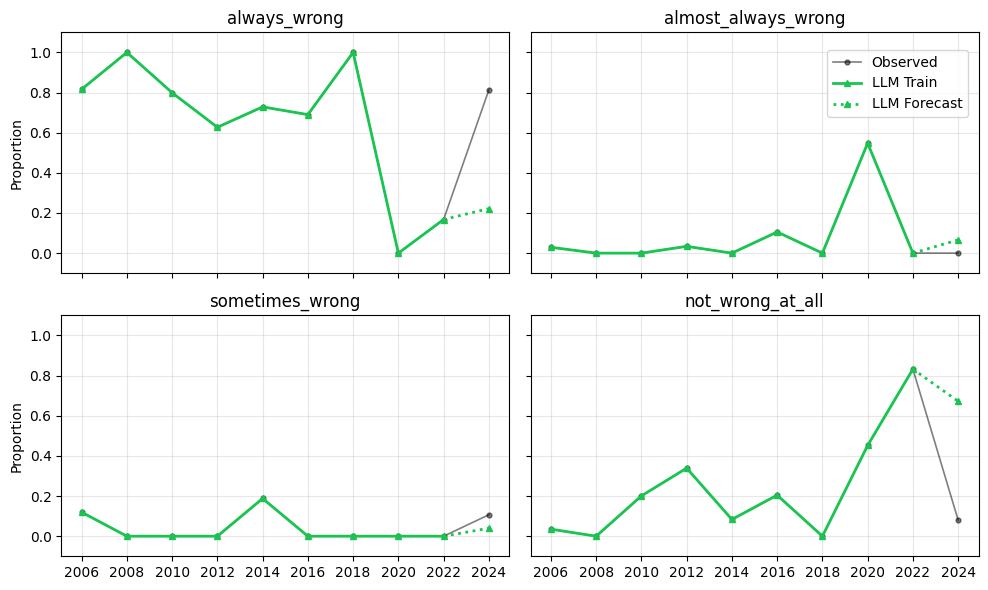

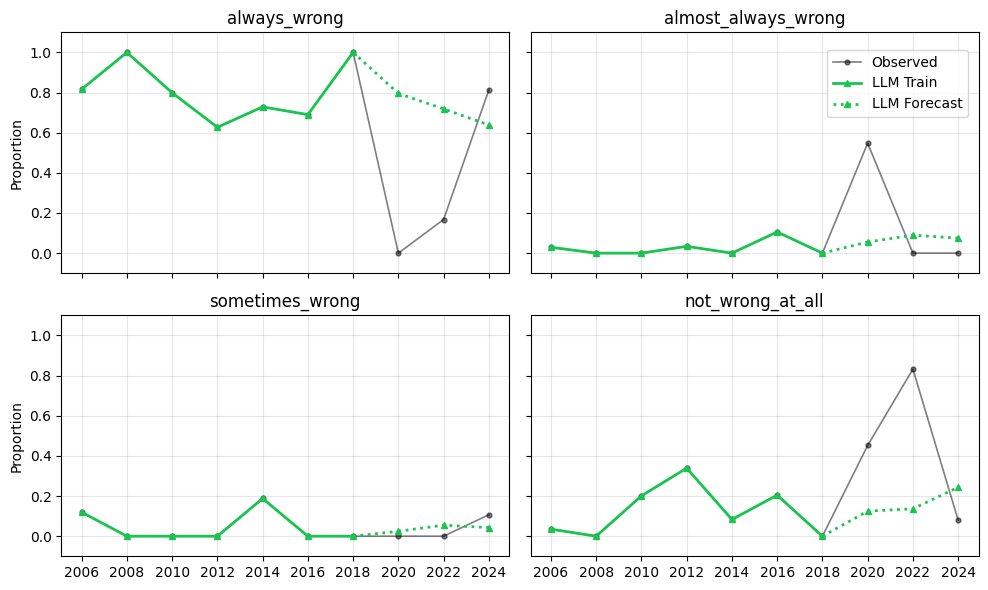

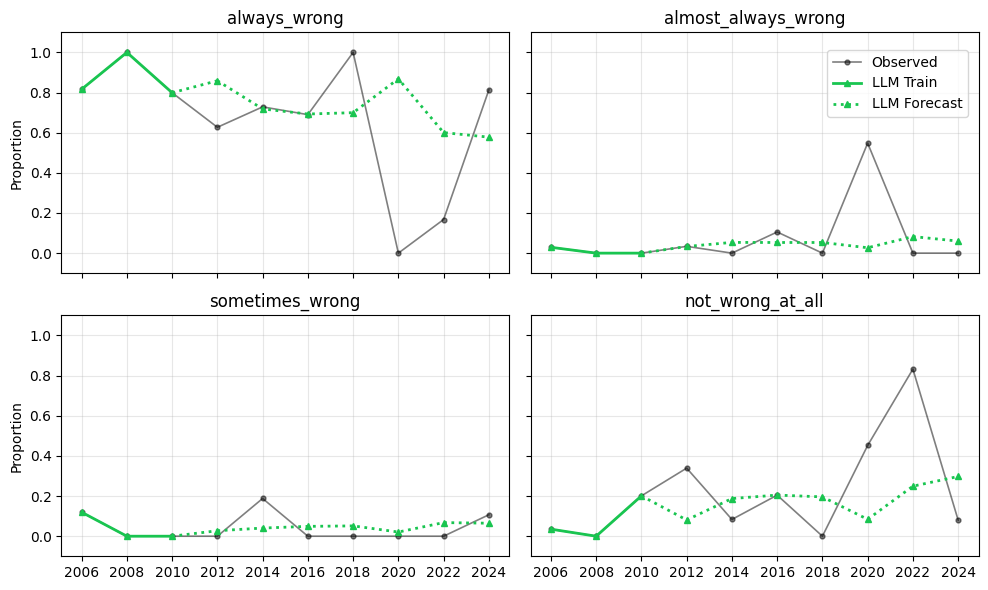

In [239]:
# Pick a group
G = ("Silent Generation","Female","Black","Less or equal to high school")

for exp in sorted(df_fore_long["experiment"].unique()):
    plot_forecast_per_experiment_group_connected(
        experiment=exp,
        group_tuple=G,
        df_fore_long=df_fore_long,
        p_cs_full=p_cs_full,
        cats=CATS,
        # title_prefix=f"[Forecasts] {OUTCOME.upper()} — {exp}",
        save_path=None
    )



## HOMOSEX, Group 1

In [240]:

# Set results folders for Group 4
FORECAST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group1"               # forward forecasts
BACKTEST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1"      # rolling backtests

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "homosex"

# Group columns used throughout
GROUP_COLS = ["generation"]

# Label sets
ABORT4   = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "abortion":
    CATS = ABORT4
    OUTCOME_PREFIX = "abortion"
elif OUTCOME == "homosex":
    CATS = HOMOSEX4
    OUTCOME_PREFIX = "homosex"
else:
    raise ValueError("Set OUTCOME to 'abortion' or 'homosex'.")

In [241]:
# Loaders (forecasts & backtests)
def load_forecasts(forecast_dir, outcome_key):
    """
    Loads all forecast CSVs matching forecasts_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(forecast_dir, f"forecasts_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No forecast files found: {pattern}")
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"forecasts_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "target_year" in df.columns: df["target_year"] = df["target_year"].astype(int)
        if "anchor_year" in df.columns: df["anchor_year"] = df["anchor_year"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

def load_backtests(backtest_dir, outcome_key):
    """
    Loads all backtest CSVs matching backtest_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(backtest_dir, f"backtest_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[warn] No backtest files found: {pattern}")
        return pd.DataFrame()
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"backtest_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "year_t" in df.columns: df["year_t"] = df["year_t"].astype(int)
        if "year_t1" in df.columns: df["year_t1"] = df["year_t1"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

df_fore = load_forecasts(FORECAST_DIR, OUTCOME)
df_back = load_backtests(BACKTEST_DIR, OUTCOME)

print("Forecasts:", df_fore.shape, "Backtests:", df_back.shape)
print("Experiments (forecasts):", sorted(df_fore["experiment"].unique().tolist()))
if not df_back.empty:
    print("Experiments (backtests):", sorted(df_back["experiment"].unique().tolist()))

Forecasts: (63, 27) Backtests: (101, 27)
Experiments (forecasts): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']
Experiments (backtests): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']


In [242]:
# Helpers to go long/tidy
def melt_probs(df_in, columns_prefix, cats, id_cols):
    cols = [f"{columns_prefix}_{c}" for c in cats if f"{columns_prefix}_{c}" in df_in.columns]
    if not cols:
        return None
    sub = df_in[id_cols + cols].copy()
    long = sub.melt(
        id_vars=id_cols,
        value_vars=cols,
        var_name="category",
        value_name=columns_prefix
    )
    long["category"] = long["category"].str.replace(f"{columns_prefix}_", "", regex=False)
    return long

def list_groups(df_any):
    if df_any.empty: return []
    return df_any[GROUP_COLS].drop_duplicates().apply(tuple, axis=1).tolist()

In [243]:
# Build long frames
# Forecasts use 'target_year' (and 'anchor_year')
ID_F = ["experiment"] + GROUP_COLS + ["target_year","anchor_year"]

long_hat_f   = melt_probs(df_fore, "p_hat",   CATS, id_cols=ID_F)
long_trans_f = melt_probs(df_fore, "p_trans", CATS, id_cols=ID_F)
long_marg_f  = melt_probs(df_fore, "p_margin",CATS, id_cols=ID_F)
long_obs_f   = melt_probs(df_fore, "p_obs",   CATS, id_cols=ID_F)

frames_f = [x for x in [long_hat_f, long_trans_f, long_marg_f, long_obs_f] if x is not None]
df_fore_long = frames_f[0]
for f in frames_f[1:]:
    df_fore_long = df_fore_long.merge(
        f, on=ID_F+["category"], how="left"
    )

# Backtests use 'year_t1' for the target year
if not df_back.empty:
    ID_B = ["experiment"] + GROUP_COLS + ["year_t","year_t1"]
    long_hat_b   = melt_probs(df_back, "p_hat",   CATS, id_cols=ID_B)
    long_trans_b = melt_probs(df_back, "p_trans", CATS, id_cols=ID_B)
    long_marg_b  = melt_probs(df_back, "p_margin",CATS, id_cols=ID_B)
    long_obs_b   = melt_probs(df_back, "p_obs",   CATS, id_cols=ID_B)

    frames_b = [x for x in [long_hat_b, long_trans_b, long_marg_b, long_obs_b] if x is not None]
    if frames_b:
        df_back_long = frames_b[0]
        for f in frames_b[1:]:
            df_back_long = df_back_long.merge(
                f, on=ID_B+["category"], how="left"
            )
    else:
        df_back_long = pd.DataFrame()
else:
    df_back_long = pd.DataFrame()

print("Long forecast shape:", df_fore_long.shape)
print("Long backtest shape:", df_back_long.shape)

Long forecast shape: (252, 9)
Long backtest shape: (404, 9)


In [244]:
# Available groups
available_groups = list_groups(df_fore_long)
print("Example groups:", available_groups[:5])

Example groups: [('Baby Boomer',), ('Generation X',), ('Generation Z',), ('Millennial',), ('Silent Generation',)]


In [245]:
# CONFIG
# import os, json, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
# from transformers import AutoTokenizer, AutoModelForCausalLM
# from peft import PeftModel

# Base backbone
BASE_MODEL_NAME = "meta-llama/llama-3.1-8b"

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "homosex"

# Cross-sectional CSV (full, for evaluation)
CS_CSV = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/GSS/gss_abt_cs_homosex.csv"  # change per OUTCOME if separate files

# Grouping
GROUP_COLS = ["generation"]

################
# LABEL SPACES
ABORT4 = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "homosex":
    CATS = HOMOSEX4
    TARGET_COL = "homosex"
elif OUTCOME == "abortion":
    CATS = ABORT4
    TARGET_COL = "abortion_att4"
else:
    raise ValueError("Unknown OUTCOME")

K = len(CATS)

# OBSERVED MARGINS (FULL DATA, FOR EVAL ONLY)
cs = pd.read_csv(CS_CSV)
cs["year"] = cs["year"].apply(lambda x: 2020 if x==2021 else x)
cs = cs[cs[TARGET_COL].astype(str).str.strip().isin(CATS)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts):
        d[str(v).strip()] += float(w)
    vec = np.array([d[c] for c in cats], dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

p_cs_full = {}
for (gvals, df_g) in cs.groupby(GROUP_COLS):
    for y, df_y in df_g.groupby("year"):
        p = weighted_probs(df_y[TARGET_COL].tolist(), df_y["wt"].tolist(), CATS)
        if p is not None:
            p_cs_full[(gvals, int(y))] = p

In [246]:
def _cutoff_from_exp(exp_name, candidates=(2008,2010,2012,2014,2016,2018,2020,2022,2024)):
    for y in candidates:
        if str(y) in exp_name:
            return y
    return None


def plot_forecast_per_experiment_group_connected(
    experiment, group_tuple, df_fore_long, p_cs_full, cats, 
    title_prefix=None, save_path=None
):
    """
    One figure per experiment & group.

    Uses:
      - p_cs_full[(g_tuple, year)] -> observed vector (length K) for any year you have
      - df_fore_long (forecast CSVs) -> p_hat_* for target_year after cutoff

    Draws:
      - observed (thin black) across all available years
      - model (thick blue) SOLID up to cutoff (observed)
      - model (thick blue) DASHED after cutoff (forecast)
      - dashed line connects smoothly from last training point
    """

    # filter to exp + group for forecast lines
    mask = (df_fore_long["experiment"] == experiment)
    for col, val in zip(GROUP_COLS, group_tuple):
        mask &= (df_fore_long[col] == val)
    dfg = df_fore_long.loc[mask].copy()

    cutoff = _cutoff_from_exp(experiment)
    if cutoff is None:
        print(f"[warn] Could not parse a cutoff from '{experiment}'. Will only plot forecast if present.")

    # years with forecasts for this exp+group
    years_fore = sorted(dfg["target_year"].dropna().astype(int).unique()) if not dfg.empty else []
    # years with observed for this group (from full CS margins)
    years_obs = sorted([y for (g,y) in p_cs_full.keys() if g == group_tuple])
    if not years_fore and not years_obs:
        print(f"No data to plot for experiment={experiment}, group={group_tuple}")
        return

    n_panels = len(cats)
    nrows = 2 if n_panels > 2 else 1
    ncols = (n_panels + nrows - 1) // nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(GROUP_COLS, group_tuple))
    # title = title_prefix or f"{experiment} — {group_label}"
    # fig.suptitle(title, y=1.02, fontsize=12)

    # Helper to fetch observed vector for a year
    def _p_obs_for_year(y):
        vec = p_cs_full.get((group_tuple, int(y)))
        return np.array(vec, dtype=float) if vec is not None else None

    # For a clean x-axis use all years we can show (observed union forecast)
    years_all = sorted(set(years_obs) | set(years_fore))

    for i, cat in enumerate(cats):
        ax = axes[i]

        # --- 1) Observed (thin black) ---
        y_obs_series = []
        for y in years_all:
            pobs = _p_obs_for_year(y)
            y_obs_series.append(pobs[cats.index(cat)] if pobs is not None else np.nan)
        y_obs_series = np.array(y_obs_series, dtype=float)
        if np.isfinite(y_obs_series).any():
            finite = np.isfinite(y_obs_series)
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], y_obs_series[s:e],
                    marker="o", markersize=3.5, linewidth=1.2,
                    linestyle="-", color="black", alpha=0.5,
                    label="Observed" if i==0 and s==idx[0] else None
                )

        # --- 2) Model: solid train, dashed forecast ---
        y_train, y_fore = [np.nan]*len(years_all), [np.nan]*len(years_all)

        # Fill training part
        for j, y in enumerate(years_all):
            if cutoff is not None and y <= cutoff:
                pobs = _p_obs_for_year(y)
                if pobs is not None:
                    y_train[j] = pobs[cats.index(cat)]

        # Fill forecast part
        if not dfg.empty:
            d_cat = dfg[dfg["category"] == cat]
            for _, row in d_cat.iterrows():
                y = int(row["target_year"])
                if (cutoff is None) or (y > cutoff):
                    if y in years_all:
                        j = years_all.index(y)
                        y_fore[j] = float(row["p_hat"]) if pd.notna(row["p_hat"]) else np.nan

        # --- Draw solid training part ---
        finite = np.isfinite(y_train)
        if finite.any():
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], np.array(y_train)[s:e],
                    marker="^", markersize=4.5, linestyle="-",
                    linewidth=2.0, color="#19c550",
                    label="LLM Train" if i==0 and s==idx[0] else None
                )

        # --- Draw dashed forecast part + connect ---
        finite_fore = np.isfinite(y_fore)
        if finite_fore.any():
            idx = np.where(np.diff(np.concatenate(([False], finite_fore, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                # connect from last training point (if it exists)
                if cutoff is not None and np.any(np.isfinite(y_train)):
                    last_train_idx = np.where((np.array(years_all) <= cutoff) & np.isfinite(y_train))[0]
                    if len(last_train_idx) > 0:
                        last_idx = last_train_idx[-1]
                        if years_all[last_idx] < years_all[s]:
                            ax.plot(
                                [years_all[last_idx], years_all[s]],
                                [y_train[last_idx], y_fore[s]],
                                linestyle=":", color="#19c550", linewidth=2.0
                            )
                ax.plot(
                    years_all[s:e], np.array(y_fore)[s:e],
                    marker="^", markersize=4.5, linestyle=":",
                    linewidth=2.0, color="#19c550",
                    label="LLM Forecast" if i==0 and s==idx[0] else None
                )

        # Styling
        ax.set_title(cat)
        ax.set_xticks(range(2006, 2026, 2))
        ax.set_ylim(-0.1, 1.1)
        ax.grid(alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("Proportion")
        # if i // ncols == (nrows - 1):
        #     ax.set_xlabel("Year")

    # --- Legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l and l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc='upper right', ncol=1, bbox_to_anchor=(0.98, 0.92))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()


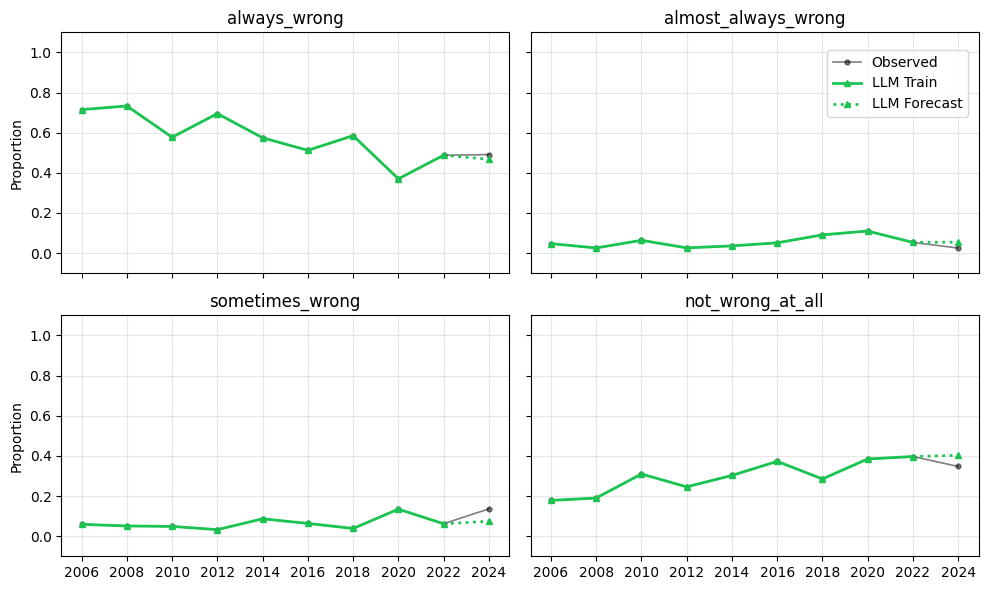

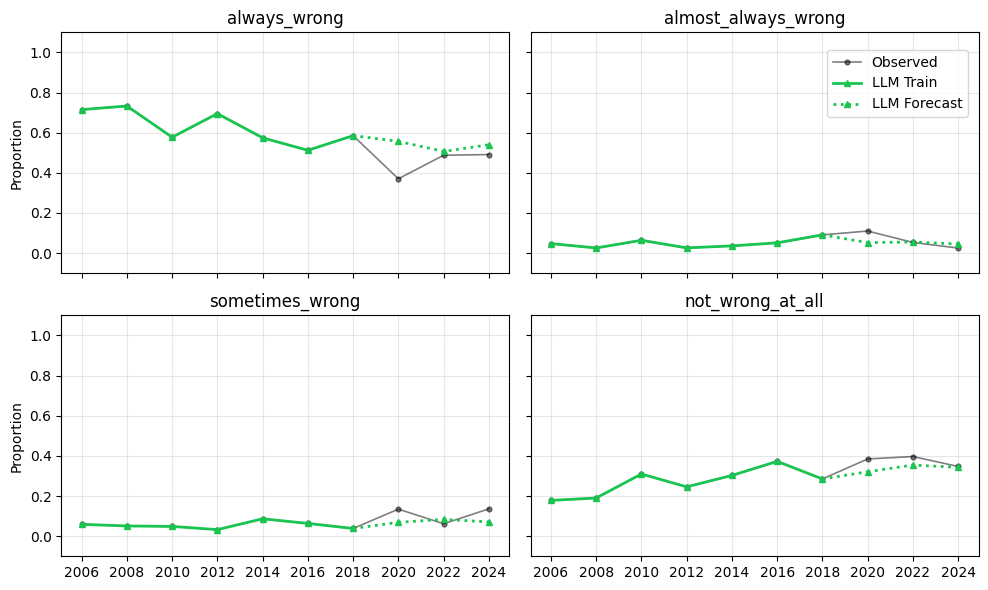

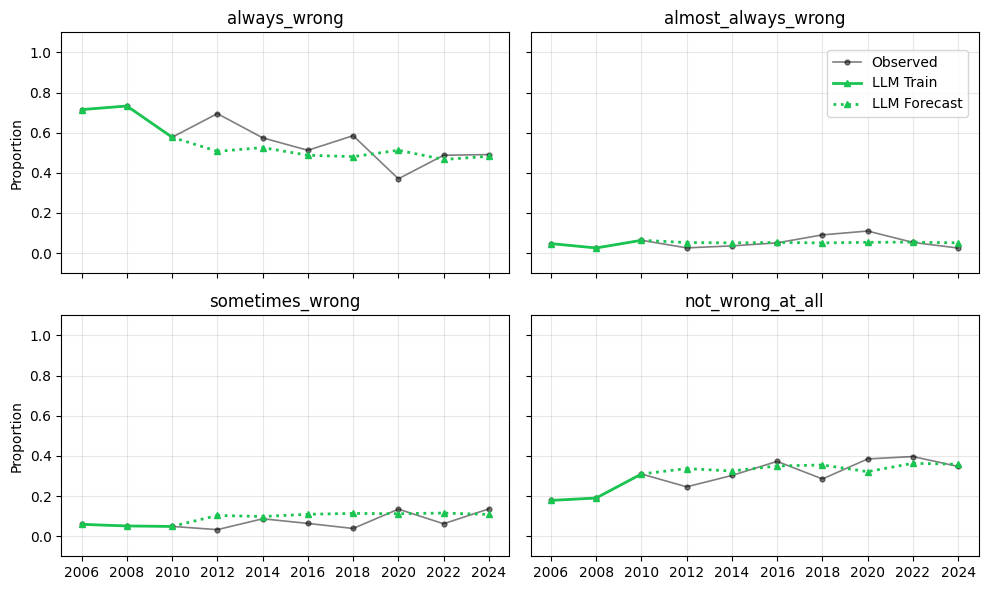

In [247]:
# Pick a group
G = ("Silent Generation",)

for exp in sorted(df_fore_long["experiment"].unique()):
    plot_forecast_per_experiment_group_connected(
        experiment=exp,
        group_tuple=G,
        df_fore_long=df_fore_long,
        p_cs_full=p_cs_full,
        cats=CATS,
        # title_prefix=f"[Forecasts] {OUTCOME.upper()} — {exp}",
        save_path=None
    )



## Abortion, G4

In [248]:

# Set results folders for Group 4
FORECAST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4"               # forward forecasts
BACKTEST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4"      # rolling backtests

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "abortion"

# Group columns used throughout
GROUP_COLS = ["generation","gender","race","edu_level"]

# Label sets
ABORT4   = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "abortion":
    CATS = ABORT4
    OUTCOME_PREFIX = "abortion"
elif OUTCOME == "homosex":
    CATS = HOMOSEX4
    OUTCOME_PREFIX = "homosex"
else:
    raise ValueError("Set OUTCOME to 'abortion' or 'homosex'.")

In [249]:
# Loaders (forecasts & backtests)
def load_forecasts(forecast_dir, outcome_key):
    """
    Loads all forecast CSVs matching forecasts_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(forecast_dir, f"forecasts_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No forecast files found: {pattern}")
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"forecasts_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "target_year" in df.columns: df["target_year"] = df["target_year"].astype(int)
        if "anchor_year" in df.columns: df["anchor_year"] = df["anchor_year"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

def load_backtests(backtest_dir, outcome_key):
    """
    Loads all backtest CSVs matching backtest_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(backtest_dir, f"backtest_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[warn] No backtest files found: {pattern}")
        return pd.DataFrame()
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"backtest_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "year_t" in df.columns: df["year_t"] = df["year_t"].astype(int)
        if "year_t1" in df.columns: df["year_t1"] = df["year_t1"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

df_fore = load_forecasts(FORECAST_DIR, OUTCOME)
df_back = load_backtests(BACKTEST_DIR, OUTCOME)

print("Forecasts:", df_fore.shape, "Backtests:", df_back.shape)
print("Experiments (forecasts):", sorted(df_fore["experiment"].unique().tolist()))
if not df_back.empty:
    print("Experiments (backtests):", sorted(df_back["experiment"].unique().tolist()))

Forecasts: (1167, 30) Backtests: (1359, 30)
Experiments (forecasts): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']
Experiments (backtests): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']


In [250]:
# Helpers to go long/tidy
def melt_probs(df_in, columns_prefix, cats, id_cols):
    cols = [f"{columns_prefix}_{c}" for c in cats if f"{columns_prefix}_{c}" in df_in.columns]
    if not cols:
        return None
    sub = df_in[id_cols + cols].copy()
    long = sub.melt(
        id_vars=id_cols,
        value_vars=cols,
        var_name="category",
        value_name=columns_prefix
    )
    long["category"] = long["category"].str.replace(f"{columns_prefix}_", "", regex=False)
    return long

def list_groups(df_any):
    if df_any.empty: return []
    return df_any[GROUP_COLS].drop_duplicates().apply(tuple, axis=1).tolist()

In [251]:
# Build long frames
# Forecasts use 'target_year' (and 'anchor_year')
ID_F = ["experiment"] + GROUP_COLS + ["target_year","anchor_year"]

long_hat_f   = melt_probs(df_fore, "p_hat",   CATS, id_cols=ID_F)
long_trans_f = melt_probs(df_fore, "p_trans", CATS, id_cols=ID_F)
long_marg_f  = melt_probs(df_fore, "p_margin",CATS, id_cols=ID_F)
long_obs_f   = melt_probs(df_fore, "p_obs",   CATS, id_cols=ID_F)

frames_f = [x for x in [long_hat_f, long_trans_f, long_marg_f, long_obs_f] if x is not None]
df_fore_long = frames_f[0]
for f in frames_f[1:]:
    df_fore_long = df_fore_long.merge(
        f, on=ID_F+["category"], how="left"
    )

# Backtests use 'year_t1' for the target year
if not df_back.empty:
    ID_B = ["experiment"] + GROUP_COLS + ["year_t","year_t1"]
    long_hat_b   = melt_probs(df_back, "p_hat",   CATS, id_cols=ID_B)
    long_trans_b = melt_probs(df_back, "p_trans", CATS, id_cols=ID_B)
    long_marg_b  = melt_probs(df_back, "p_margin",CATS, id_cols=ID_B)
    long_obs_b   = melt_probs(df_back, "p_obs",   CATS, id_cols=ID_B)

    frames_b = [x for x in [long_hat_b, long_trans_b, long_marg_b, long_obs_b] if x is not None]
    if frames_b:
        df_back_long = frames_b[0]
        for f in frames_b[1:]:
            df_back_long = df_back_long.merge(
                f, on=ID_B+["category"], how="left"
            )
    else:
        df_back_long = pd.DataFrame()
else:
    df_back_long = pd.DataFrame()

print("Long forecast shape:", df_fore_long.shape)
print("Long backtest shape:", df_back_long.shape)

Long forecast shape: (4668, 12)
Long backtest shape: (5436, 12)


In [252]:
# CONFIG
# import os, json, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
# from transformers import AutoTokenizer, AutoModelForCausalLM
# from peft import PeftModel

# Base backbone
BASE_MODEL_NAME = "meta-llama/llama-3.1-8b"

# Experiments (point these to your trained folders from Exp-A/B/C)
ROOT = "/content/drive/MyDrive/LLM_POC_Study_2025_v2/outputs_gss_r_trial_homosex_g4"
EXPERIMENTS = [
    {
        "name": "exp_A_train_le_2022",
        "SAVE_DIR": f"{ROOT}/exp_A_train_le_2022/final_ckpt",
        "HEAD_PATH": f"{ROOT}/exp_A_train_le_2022/final_ckpt/two_head_exp_A_train_le_2022.pt",
        "FORECAST_YEARS": [2024],
    },
    {
        "name": "exp_B_train_le_2018",
        "SAVE_DIR": f"{ROOT}/exp_B_train_le_2018/final_ckpt",
        "HEAD_PATH": f"{ROOT}/exp_B_train_le_2018/final_ckpt/two_head_exp_B_train_le_2018.pt",
        "FORECAST_YEARS": [2020, 2022, 2024],
    },
    {
        "name": "exp_C_train_le_2010",
        "SAVE_DIR": f"{ROOT}/exp_C_train_le_2010/final_ckpt",
        "HEAD_PATH": f"{ROOT}/exp_C_train_le_2010/final_ckpt/two_head_exp_C_train_le_2010.pt",
        "FORECAST_YEARS": [2012, 2014, 2016, 2018, 2020, 2022, 2024],
    },
]

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "abortion"

# Cross-sectional CSV (full, for evaluation)
CS_CSV = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/GSS/gss_abt_cs_abortion.csv"  # change per OUTCOME if separate files

# Grouping
GROUP_COLS = ["generation","gender","race","edu_level"]

################
# LABEL SPACES
ABORT4 = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "homosex":
    CATS = HOMOSEX4
    TARGET_COL = "homosex"
elif OUTCOME == "abortion":
    CATS = ABORT4
    TARGET_COL = "abortion_att4"
else:
    raise ValueError("Unknown OUTCOME")

K = len(CATS)

# OBSERVED MARGINS (FULL DATA, FOR EVAL ONLY)
cs = pd.read_csv(CS_CSV)
cs["year"] = cs["year"].apply(lambda x: 2020 if x==2021 else x)
cs = cs[cs[TARGET_COL].astype(str).str.strip().isin(CATS)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts):
        d[str(v).strip()] += float(w)
    vec = np.array([d[c] for c in cats], dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

p_cs_full = {}
for (gvals, df_g) in cs.groupby(GROUP_COLS):
    for y, df_y in df_g.groupby("year"):
        p = weighted_probs(df_y[TARGET_COL].tolist(), df_y["wt"].tolist(), CATS)
        if p is not None:
            p_cs_full[(gvals, int(y))] = p

In [253]:
def _cutoff_from_exp(exp_name, candidates=(2008,2010,2012,2014,2016,2018,2020,2022,2024)):
    for y in candidates:
        if str(y) in exp_name:
            return y
    return None


def plot_forecast_per_experiment_group_connected(
    experiment, group_tuple, df_fore_long, p_cs_full, cats, 
    title_prefix=None, save_path=None
):
    """
    One figure per experiment & group.

    Uses:
      - p_cs_full[(g_tuple, year)] -> observed vector (length K) for any year you have
      - df_fore_long (forecast CSVs) -> p_hat_* for target_year after cutoff

    Draws:
      - observed (thin black) across all available years
      - model (thick blue) SOLID up to cutoff (observed)
      - model (thick blue) DASHED after cutoff (forecast)
      - dashed line connects smoothly from last training point
    """

    # filter to exp + group for forecast lines
    mask = (df_fore_long["experiment"] == experiment)
    for col, val in zip(GROUP_COLS, group_tuple):
        mask &= (df_fore_long[col] == val)
    dfg = df_fore_long.loc[mask].copy()

    cutoff = _cutoff_from_exp(experiment)
    if cutoff is None:
        print(f"[warn] Could not parse a cutoff from '{experiment}'. Will only plot forecast if present.")

    # years with forecasts for this exp+group
    years_fore = sorted(dfg["target_year"].dropna().astype(int).unique()) if not dfg.empty else []
    # years with observed for this group (from full CS margins)
    years_obs = sorted([y for (g,y) in p_cs_full.keys() if g == group_tuple])
    if not years_fore and not years_obs:
        print(f"No data to plot for experiment={experiment}, group={group_tuple}")
        return

    n_panels = len(cats)
    nrows = 2 if n_panels > 2 else 1
    ncols = (n_panels + nrows - 1) // nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(GROUP_COLS, group_tuple))
    # title = title_prefix or f"{experiment} — {group_label}"
    # fig.suptitle(title, y=1.02, fontsize=12)

    # Helper to fetch observed vector for a year
    def _p_obs_for_year(y):
        vec = p_cs_full.get((group_tuple, int(y)))
        return np.array(vec, dtype=float) if vec is not None else None

    # For a clean x-axis use all years we can show (observed union forecast)
    years_all = sorted(set(years_obs) | set(years_fore))

    for i, cat in enumerate(cats):
        ax = axes[i]

        # --- 1) Observed (thin black) ---
        y_obs_series = []
        for y in years_all:
            pobs = _p_obs_for_year(y)
            y_obs_series.append(pobs[cats.index(cat)] if pobs is not None else np.nan)
        y_obs_series = np.array(y_obs_series, dtype=float)
        if np.isfinite(y_obs_series).any():
            finite = np.isfinite(y_obs_series)
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], y_obs_series[s:e],
                    marker="o", markersize=3.5, linewidth=1.2,
                    linestyle="-", color="black", alpha=0.5,
                    label="Observed" if i==0 and s==idx[0] else None
                )

        # --- 2) Model: solid train, dashed forecast ---
        y_train, y_fore = [np.nan]*len(years_all), [np.nan]*len(years_all)

        # Fill training part
        for j, y in enumerate(years_all):
            if cutoff is not None and y <= cutoff:
                pobs = _p_obs_for_year(y)
                if pobs is not None:
                    y_train[j] = pobs[cats.index(cat)]

        # Fill forecast part
        if not dfg.empty:
            d_cat = dfg[dfg["category"] == cat]
            for _, row in d_cat.iterrows():
                y = int(row["target_year"])
                if (cutoff is None) or (y > cutoff):
                    if y in years_all:
                        j = years_all.index(y)
                        y_fore[j] = float(row["p_hat"]) if pd.notna(row["p_hat"]) else np.nan

        # --- Draw solid training part ---
        finite = np.isfinite(y_train)
        if finite.any():
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], np.array(y_train)[s:e],
                    marker="^", markersize=4.5, linestyle="-",
                    linewidth=2.0, color="#19c550",
                    label="LLM Train" if i==0 and s==idx[0] else None
                )

        # --- Draw dashed forecast part + connect ---
        finite_fore = np.isfinite(y_fore)
        if finite_fore.any():
            idx = np.where(np.diff(np.concatenate(([False], finite_fore, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                # connect from last training point (if it exists)
                if cutoff is not None and np.any(np.isfinite(y_train)):
                    last_train_idx = np.where((np.array(years_all) <= cutoff) & np.isfinite(y_train))[0]
                    if len(last_train_idx) > 0:
                        last_idx = last_train_idx[-1]
                        if years_all[last_idx] < years_all[s]:
                            ax.plot(
                                [years_all[last_idx], years_all[s]],
                                [y_train[last_idx], y_fore[s]],
                                linestyle=":", color="#19c550", linewidth=2.0
                            )
                ax.plot(
                    years_all[s:e], np.array(y_fore)[s:e],
                    marker="^", markersize=4.5, linestyle=":",
                    linewidth=2.0, color="#19c550",
                    label="LLM Forecast" if i==0 and s==idx[0] else None
                )

        # Styling
        ax.set_title(cat)
        ax.set_xticks(range(2006, 2026, 2))
        ax.set_ylim(-0.1, 1.1)
        ax.grid(alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("Proportion")
        # if i // ncols == (nrows - 1):
        #     ax.set_xlabel("Year")

    # --- Legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l and l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc='upper right', ncol=1, bbox_to_anchor=(0.98, 0.92))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()


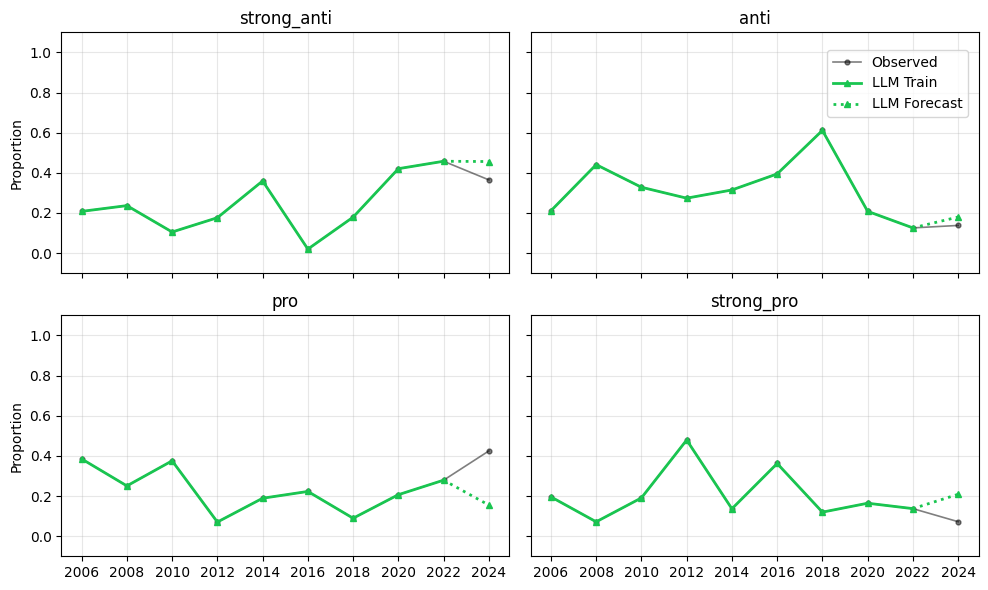

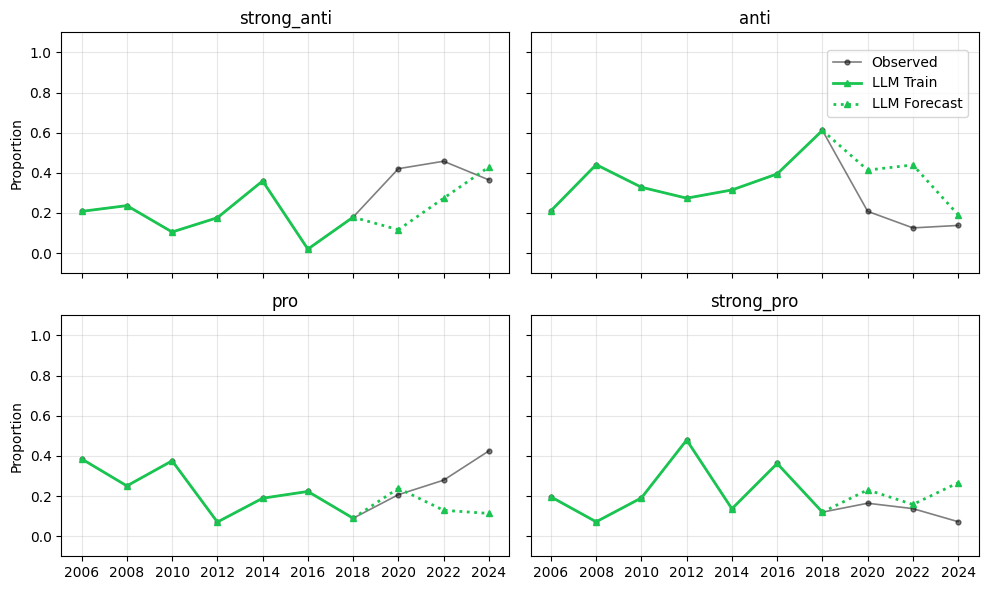

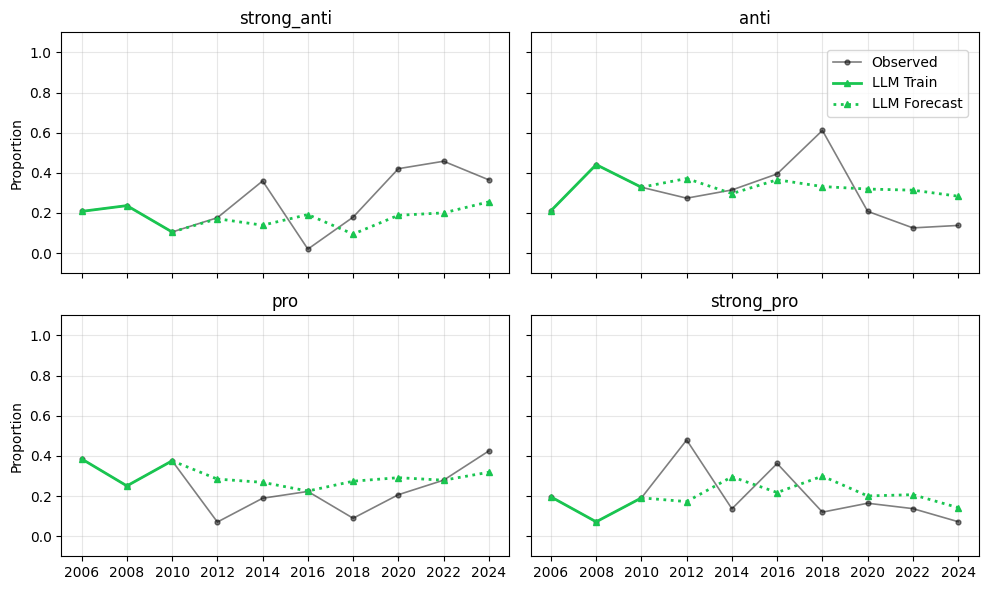

In [254]:
# Pick a group
G = ("Millennial","Female","Other","Less or equal to high school")

for exp in sorted(df_fore_long["experiment"].unique()):
    plot_forecast_per_experiment_group_connected(
        experiment=exp,
        group_tuple=G,
        df_fore_long=df_fore_long,
        p_cs_full=p_cs_full,
        cats=CATS,
        # title_prefix=f"[Forecasts] {OUTCOME.upper()} — {exp}",
        save_path=None
    )



## Abortion, G1

In [255]:

# Set results folders for Group 4
FORECAST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group1"               # forward forecasts
BACKTEST_DIR = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1"      # rolling backtests

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "abortion"

# Group columns used throughout
GROUP_COLS = ["generation"]

# Label sets
ABORT4   = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "abortion":
    CATS = ABORT4
    OUTCOME_PREFIX = "abortion"
elif OUTCOME == "homosex":
    CATS = HOMOSEX4
    OUTCOME_PREFIX = "homosex"
else:
    raise ValueError("Set OUTCOME to 'abortion' or 'homosex'.")

In [256]:
# Loaders (forecasts & backtests)
def load_forecasts(forecast_dir, outcome_key):
    """
    Loads all forecast CSVs matching forecasts_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(forecast_dir, f"forecasts_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No forecast files found: {pattern}")
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"forecasts_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "target_year" in df.columns: df["target_year"] = df["target_year"].astype(int)
        if "anchor_year" in df.columns: df["anchor_year"] = df["anchor_year"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

def load_backtests(backtest_dir, outcome_key):
    """
    Loads all backtest CSVs matching backtest_{OUTCOME}_*.csv
    Returns a single DataFrame with an 'experiment' column.
    """
    pattern = os.path.join(backtest_dir, f"backtest_{outcome_key}_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[warn] No backtest files found: {pattern}")
        return pd.DataFrame()
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        if "experiment" not in df.columns:
            exp = os.path.splitext(os.path.basename(fp))[0].replace(f"backtest_{outcome_key}_", "")
            df["experiment"] = exp
        # enforce dtypes
        if "year_t" in df.columns: df["year_t"] = df["year_t"].astype(int)
        if "year_t1" in df.columns: df["year_t1"] = df["year_t1"].astype(int)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

df_fore = load_forecasts(FORECAST_DIR, OUTCOME)
df_back = load_backtests(BACKTEST_DIR, OUTCOME)

print("Forecasts:", df_fore.shape, "Backtests:", df_back.shape)
print("Experiments (forecasts):", sorted(df_fore["experiment"].unique().tolist()))
if not df_back.empty:
    print("Experiments (backtests):", sorted(df_back["experiment"].unique().tolist()))

Forecasts: (63, 27) Backtests: (101, 27)
Experiments (forecasts): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']
Experiments (backtests): ['exp_A_train_le_2022', 'exp_B_train_le_2018', 'exp_C_train_le_2010']


In [257]:
# Helpers to go long/tidy
def melt_probs(df_in, columns_prefix, cats, id_cols):
    cols = [f"{columns_prefix}_{c}" for c in cats if f"{columns_prefix}_{c}" in df_in.columns]
    if not cols:
        return None
    sub = df_in[id_cols + cols].copy()
    long = sub.melt(
        id_vars=id_cols,
        value_vars=cols,
        var_name="category",
        value_name=columns_prefix
    )
    long["category"] = long["category"].str.replace(f"{columns_prefix}_", "", regex=False)
    return long

def list_groups(df_any):
    if df_any.empty: return []
    return df_any[GROUP_COLS].drop_duplicates().apply(tuple, axis=1).tolist()

In [258]:
# Build long frames
# Forecasts use 'target_year' (and 'anchor_year')
ID_F = ["experiment"] + GROUP_COLS + ["target_year","anchor_year"]

long_hat_f   = melt_probs(df_fore, "p_hat",   CATS, id_cols=ID_F)
long_trans_f = melt_probs(df_fore, "p_trans", CATS, id_cols=ID_F)
long_marg_f  = melt_probs(df_fore, "p_margin",CATS, id_cols=ID_F)
long_obs_f   = melt_probs(df_fore, "p_obs",   CATS, id_cols=ID_F)

frames_f = [x for x in [long_hat_f, long_trans_f, long_marg_f, long_obs_f] if x is not None]
df_fore_long = frames_f[0]
for f in frames_f[1:]:
    df_fore_long = df_fore_long.merge(
        f, on=ID_F+["category"], how="left"
    )

# Backtests use 'year_t1' for the target year
if not df_back.empty:
    ID_B = ["experiment"] + GROUP_COLS + ["year_t","year_t1"]
    long_hat_b   = melt_probs(df_back, "p_hat",   CATS, id_cols=ID_B)
    long_trans_b = melt_probs(df_back, "p_trans", CATS, id_cols=ID_B)
    long_marg_b  = melt_probs(df_back, "p_margin",CATS, id_cols=ID_B)
    long_obs_b   = melt_probs(df_back, "p_obs",   CATS, id_cols=ID_B)

    frames_b = [x for x in [long_hat_b, long_trans_b, long_marg_b, long_obs_b] if x is not None]
    if frames_b:
        df_back_long = frames_b[0]
        for f in frames_b[1:]:
            df_back_long = df_back_long.merge(
                f, on=ID_B+["category"], how="left"
            )
    else:
        df_back_long = pd.DataFrame()
else:
    df_back_long = pd.DataFrame()

print("Long forecast shape:", df_fore_long.shape)
print("Long backtest shape:", df_back_long.shape)

Long forecast shape: (252, 9)
Long backtest shape: (404, 9)


In [259]:
# Available groups
available_groups = list_groups(df_fore_long)
print("Example groups:", available_groups[:5])

Example groups: [('Baby Boomer',), ('Generation X',), ('Generation Z',), ('Millennial',), ('Silent Generation',)]


In [260]:
# CONFIG
# import os, json, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
# from transformers import AutoTokenizer, AutoModelForCausalLM
# from peft import PeftModel

# Base backbone
BASE_MODEL_NAME = "meta-llama/llama-3.1-8b"

# Outcome toggle: 'homosex' | 'abortion'
OUTCOME = "abortion"

# Cross-sectional CSV (full, for evaluation)
CS_CSV = "/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/GSS/gss_abt_cs_abortion.csv"  # change per OUTCOME if separate files

# Grouping
GROUP_COLS = ["generation"]

################
# LABEL SPACES
ABORT4 = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

if OUTCOME == "homosex":
    CATS = HOMOSEX4
    TARGET_COL = "homosex"
elif OUTCOME == "abortion":
    CATS = ABORT4
    TARGET_COL = "abortion_att4"
else:
    raise ValueError("Unknown OUTCOME")

K = len(CATS)

# OBSERVED MARGINS (FULL DATA, FOR EVAL ONLY)
cs = pd.read_csv(CS_CSV)
cs["year"] = cs["year"].apply(lambda x: 2020 if x==2021 else x)
cs = cs[cs[TARGET_COL].astype(str).str.strip().isin(CATS)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts):
        d[str(v).strip()] += float(w)
    vec = np.array([d[c] for c in cats], dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

p_cs_full = {}
for (gvals, df_g) in cs.groupby(GROUP_COLS):
    for y, df_y in df_g.groupby("year"):
        p = weighted_probs(df_y[TARGET_COL].tolist(), df_y["wt"].tolist(), CATS)
        if p is not None:
            p_cs_full[(gvals, int(y))] = p

In [261]:
def _cutoff_from_exp(exp_name, candidates=(2008,2010,2012,2014,2016,2018,2020,2022,2024)):
    for y in candidates:
        if str(y) in exp_name:
            return y
    return None


def plot_forecast_per_experiment_group_connected(
    experiment, group_tuple, df_fore_long, p_cs_full, cats, 
    title_prefix=None, save_path=None
):
    """
    One figure per experiment & group.

    Uses:
      - p_cs_full[(g_tuple, year)] -> observed vector (length K) for any year you have
      - df_fore_long (forecast CSVs) -> p_hat_* for target_year after cutoff

    Draws:
      - observed (thin black) across all available years
      - model (thick blue) SOLID up to cutoff (observed)
      - model (thick blue) DASHED after cutoff (forecast)
      - dashed line connects smoothly from last training point
    """

    # filter to exp + group for forecast lines
    mask = (df_fore_long["experiment"] == experiment)
    for col, val in zip(GROUP_COLS, group_tuple):
        mask &= (df_fore_long[col] == val)
    dfg = df_fore_long.loc[mask].copy()

    cutoff = _cutoff_from_exp(experiment)
    if cutoff is None:
        print(f"[warn] Could not parse a cutoff from '{experiment}'. Will only plot forecast if present.")

    # years with forecasts for this exp+group
    years_fore = sorted(dfg["target_year"].dropna().astype(int).unique()) if not dfg.empty else []
    # years with observed for this group (from full CS margins)
    years_obs = sorted([y for (g,y) in p_cs_full.keys() if g == group_tuple])
    if not years_fore and not years_obs:
        print(f"No data to plot for experiment={experiment}, group={group_tuple}")
        return

    n_panels = len(cats)
    nrows = 2 if n_panels > 2 else 1
    ncols = (n_panels + nrows - 1) // nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(GROUP_COLS, group_tuple))
    # title = title_prefix or f"{experiment} — {group_label}"
    # fig.suptitle(title, y=1.02, fontsize=12)

    # Helper to fetch observed vector for a year
    def _p_obs_for_year(y):
        vec = p_cs_full.get((group_tuple, int(y)))
        return np.array(vec, dtype=float) if vec is not None else None

    # For a clean x-axis use all years we can show (observed union forecast)
    years_all = sorted(set(years_obs) | set(years_fore))

    for i, cat in enumerate(cats):
        ax = axes[i]

        # --- 1) Observed (thin black) ---
        y_obs_series = []
        for y in years_all:
            pobs = _p_obs_for_year(y)
            y_obs_series.append(pobs[cats.index(cat)] if pobs is not None else np.nan)
        y_obs_series = np.array(y_obs_series, dtype=float)
        if np.isfinite(y_obs_series).any():
            finite = np.isfinite(y_obs_series)
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], y_obs_series[s:e],
                    marker="o", markersize=3.5, linewidth=1.2,
                    linestyle="-", color="black", alpha=0.5,
                    label="Observed" if i==0 and s==idx[0] else None
                )

        # --- 2) Model: solid train, dashed forecast ---
        y_train, y_fore = [np.nan]*len(years_all), [np.nan]*len(years_all)

        # Fill training part
        for j, y in enumerate(years_all):
            if cutoff is not None and y <= cutoff:
                pobs = _p_obs_for_year(y)
                if pobs is not None:
                    y_train[j] = pobs[cats.index(cat)]

        # Fill forecast part
        if not dfg.empty:
            d_cat = dfg[dfg["category"] == cat]
            for _, row in d_cat.iterrows():
                y = int(row["target_year"])
                if (cutoff is None) or (y > cutoff):
                    if y in years_all:
                        j = years_all.index(y)
                        y_fore[j] = float(row["p_hat"]) if pd.notna(row["p_hat"]) else np.nan

        # --- Draw solid training part ---
        finite = np.isfinite(y_train)
        if finite.any():
            idx = np.where(np.diff(np.concatenate(([False], finite, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                ax.plot(
                    years_all[s:e], np.array(y_train)[s:e],
                    marker="^", markersize=4.5, linestyle="-",
                    linewidth=2.0, color="#19c550",
                    label="LLM Train" if i==0 and s==idx[0] else None
                )

        # --- Draw dashed forecast part + connect ---
        finite_fore = np.isfinite(y_fore)
        if finite_fore.any():
            idx = np.where(np.diff(np.concatenate(([False], finite_fore, [False]))))[0]
            for s, e in zip(idx[0::2], idx[1::2]):
                # connect from last training point (if it exists)
                if cutoff is not None and np.any(np.isfinite(y_train)):
                    last_train_idx = np.where((np.array(years_all) <= cutoff) & np.isfinite(y_train))[0]
                    if len(last_train_idx) > 0:
                        last_idx = last_train_idx[-1]
                        if years_all[last_idx] < years_all[s]:
                            ax.plot(
                                [years_all[last_idx], years_all[s]],
                                [y_train[last_idx], y_fore[s]],
                                linestyle=":", color="#19c550", linewidth=2.0
                            )
                ax.plot(
                    years_all[s:e], np.array(y_fore)[s:e],
                    marker="^", markersize=4.5, linestyle=":",
                    linewidth=2.0, color="#19c550",
                    label="LLM Forecast" if i==0 and s==idx[0] else None
                )

        # Styling
        ax.set_title(cat)
        ax.set_xticks(range(2006, 2026, 2))
        ax.set_ylim(-0.1, 1.1)
        ax.grid(alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("Proportion")
        # if i // ncols == (nrows - 1):
        #     ax.set_xlabel("Year")

    # --- Legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l and l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc='upper right', ncol=1, bbox_to_anchor=(0.98, 0.92))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()


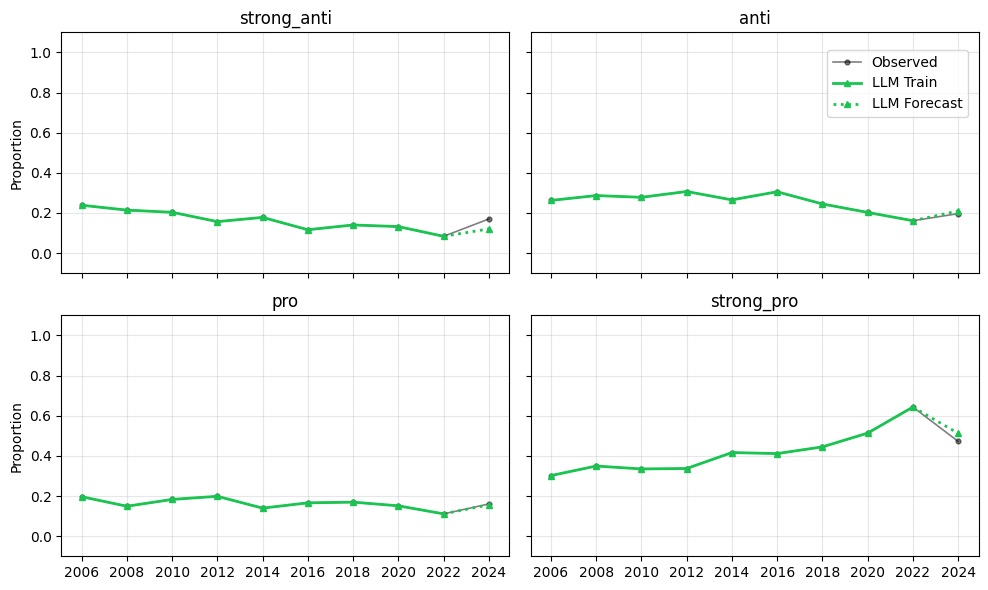

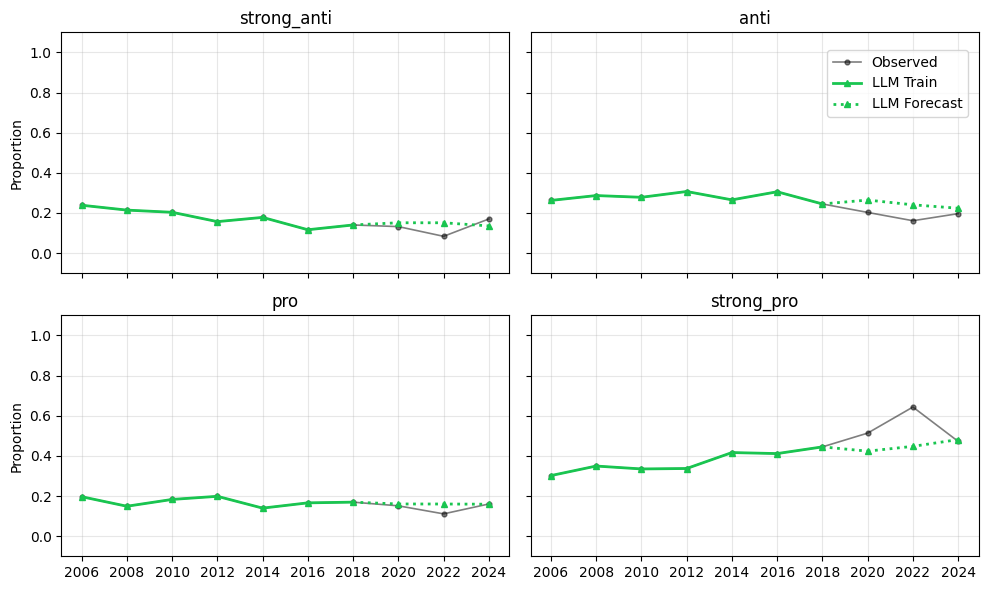

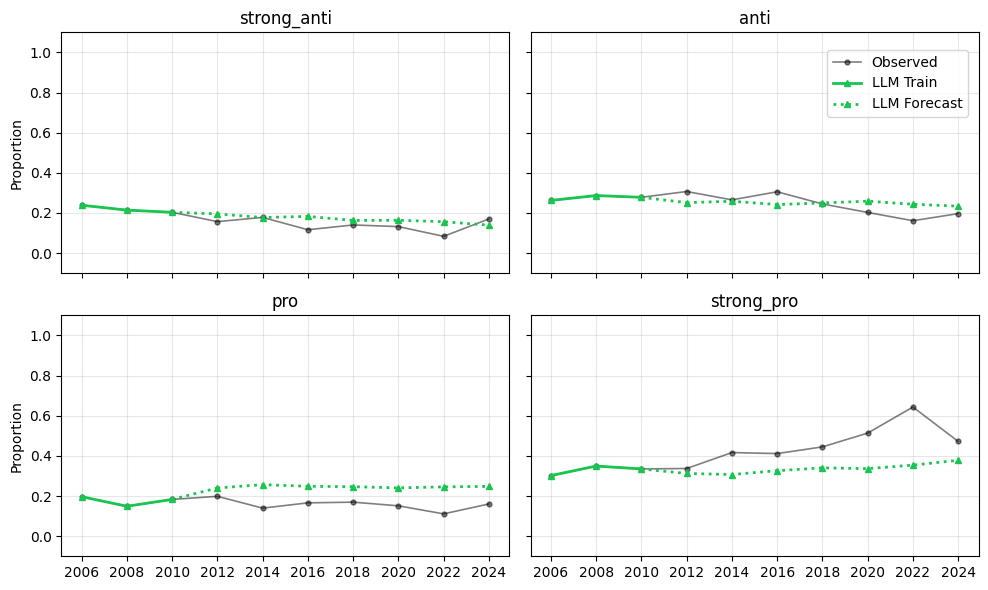

In [262]:
# Pick a group
G = ("Millennial",)

for exp in sorted(df_fore_long["experiment"].unique()):
    plot_forecast_per_experiment_group_connected(
        experiment=exp,
        group_tuple=G,
        df_fore_long=df_fore_long,
        p_cs_full=p_cs_full,
        cats=CATS,
        # title_prefix=f"[Forecasts] {OUTCOME.upper()} — {exp}",
        save_path=None
    )



In [281]:
# Load all backtest CSVs 
abo_g1_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1/backtest_abortion_exp_A_train_le_2022.csv")
abo_g2_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group2/backtest_abortion_exp_A_train_le_2022.csv")
abo_g3_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group3/backtest_abortion_exp_A_train_le_2022.csv")
abo_g4_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4/backtest_abortion_exp_A_train_le_2022.csv")

abo_g1_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1/backtest_abortion_exp_B_train_le_2018.csv")
abo_g2_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group2/backtest_abortion_exp_B_train_le_2018.csv")
abo_g3_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group3/backtest_abortion_exp_B_train_le_2018.csv")
abo_g4_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4/backtest_abortion_exp_B_train_le_2018.csv")

abo_g1_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1/backtest_abortion_exp_C_train_le_2010.csv")
abo_g2_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group2/backtest_abortion_exp_C_train_le_2010.csv")
abo_g3_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group3/backtest_abortion_exp_C_train_le_2010.csv")
abo_g4_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4/backtest_abortion_exp_C_train_le_2010.csv")

homo_g1_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1/backtest_homosex_exp_A_train_le_2022.csv")
homo_g2_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group2/backtest_homosex_exp_A_train_le_2022.csv")
homo_g3_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group3/backtest_homosex_exp_A_train_le_2022.csv")
homo_g4_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4/backtest_homosex_exp_A_train_le_2022.csv")

homo_g1_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1/backtest_homosex_exp_B_train_le_2018.csv")
homo_g2_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group2/backtest_homosex_exp_B_train_le_2018.csv")
homo_g3_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group3/backtest_homosex_exp_B_train_le_2018.csv")
homo_g4_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4/backtest_homosex_exp_B_train_le_2018.csv")

homo_g1_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group1/backtest_homosex_exp_C_train_le_2010.csv")
homo_g2_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group2/backtest_homosex_exp_C_train_le_2010.csv")
homo_g3_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group3/backtest_homosex_exp_C_train_le_2010.csv")
homo_g4_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/backtest/group4/backtest_homosex_exp_C_train_le_2010.csv")

In [282]:
# Add level column
abo_g1_a["level"] = "Level 1"
abo_g2_a["level"] = "Level 2"
abo_g3_a["level"] = "Level 3"
abo_g4_a["level"] = "Level 4"

abo_g1_b["level"] = "Level 1"
abo_g2_b["level"] = "Level 2"
abo_g3_b["level"] = "Level 3"
abo_g4_b["level"] = "Level 4"

abo_g1_c["level"] = "Level 1"
abo_g2_c["level"] = "Level 2"
abo_g3_c["level"] = "Level 3"
abo_g4_c["level"] = "Level 4"

homo_g1_a["level"] = "Level 1"
homo_g2_a["level"] = "Level 2"
homo_g3_a["level"] = "Level 3"
homo_g4_a["level"] = "Level 4"
homo_g1_b["level"] = "Level 1"
homo_g2_b["level"] = "Level 2"
homo_g3_b["level"] = "Level 3"  
homo_g4_b["level"] = "Level 4"
homo_g1_c["level"] = "Level 1"
homo_g2_c["level"] = "Level 2"
homo_g3_c["level"] = "Level 3"
homo_g4_c["level"] = "Level 4"

In [283]:
# Combine all backtest DataFrames
abo_backtests = pd.concat([
    abo_g1_a, abo_g2_a, abo_g3_a, abo_g4_a,
    abo_g1_b, abo_g2_b, abo_g3_b, abo_g4_b,
    abo_g1_c, abo_g2_c, abo_g3_c, abo_g4_c
], ignore_index=True)

homo_backtests = pd.concat([
    homo_g1_a, homo_g2_a, homo_g3_a, homo_g4_a,
    homo_g1_b, homo_g2_b, homo_g3_b, homo_g4_b,
    homo_g1_c, homo_g2_c, homo_g3_c, homo_g4_c
], ignore_index=True)

In [284]:
abo_backtests.head()

,experiment,generation,year_t,year_t1,p_prev_strong_anti,p_trans_strong_anti,p_margin_strong_anti,p_hat_strong_anti,p_prev_anti,p_trans_anti,...,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,level,gender,race,edu_level
0,exp_A_train_le_2022,Baby Boomer,2006,2008,0.169826,0.177485,0.164271,0.170878,0.308336,0.286932,...,0.290347,0.153132,0.399422,0.000215,0.000410,0.000114,Level 1,NaN,NaN,NaN
1,exp_A_train_le_2022,Baby Boomer,2008,2010,0.157098,0.170341,0.178362,0.174351,0.290347,0.284117,...,0.240697,0.174067,0.390495,0.001367,0.002525,0.001154,Level 1,NaN,NaN,NaN
2,exp_A_train_le_2022,Baby Boomer,2010,2012,0.194740,0.179919,0.190973,0.185446,0.240697,0.262099,...,0.254281,0.168292,0.393227,0.000188,0.001605,0.003019,Level 1,NaN,NaN,NaN
3,exp_A_train_le_2022,Baby Boomer,2012,2014,0.184200,0.175332,0.207989,0.191660,0.254281,0.272747,...,0.250353,0.147650,0.411347,0.000459,0.001018,0.003813,Level 1,NaN,NaN,NaN
4,exp_A_train_le_2022,Baby Boomer,2014,2016,0.190650,0.177241,0.201707,0.189474,0.250353,0.262984,...,0.257779,0.185050,0.377289,0.000589,0.004754,0.000910,Level 1,NaN,NaN,NaN


In [285]:
# Keep only the columns we need
df_abo_jsd = abo_backtests[["experiment", "year_t1", "JSD_hat_vs_obs", "level"]].dropna().copy()
df_abo_jsd.rename(columns={"JSD_hat_vs_obs": "JSD"}, inplace=True)
print(df_abo_jsd.head())

df_homo_jsd = homo_backtests[["experiment", "year_t1", "JSD_hat_vs_obs", "level"]].dropna().copy()
df_homo_jsd.rename(columns={"JSD_hat_vs_obs": "JSD"}, inplace=True)
print(df_homo_jsd.head())

            experiment  year_t1       JSD    level
0  exp_A_train_le_2022     2008  0.000215  Level 1
1  exp_A_train_le_2022     2010  0.001367  Level 1
2  exp_A_train_le_2022     2012  0.000188  Level 1
3  exp_A_train_le_2022     2014  0.000459  Level 1
4  exp_A_train_le_2022     2016  0.000589  Level 1
            experiment  year_t1       JSD    level
0  exp_A_train_le_2022     2008  0.000770  Level 1
1  exp_A_train_le_2022     2010  0.001238  Level 1
2  exp_A_train_le_2022     2012  0.000382  Level 1
3  exp_A_train_le_2022     2014  0.000530  Level 1
4  exp_A_train_le_2022     2016  0.000283  Level 1


In [288]:
# Calculate JSD for each experiment and level
df_abo_jsd.groupby(["experiment", "level"]).agg({"JSD": "mean"}).reset_index().to_csv("df_abo_jsd.csv", index=False)
df_homo_jsd.groupby(["experiment", "level"]).agg({"JSD": "mean"}).reset_index().to_csv("df_homo_jsd.csv", index=False)


/var/folders/2k/gr93l1l1533bh8zk2y4z2g4h0000gn/T/ipykernel_47944/2235416164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


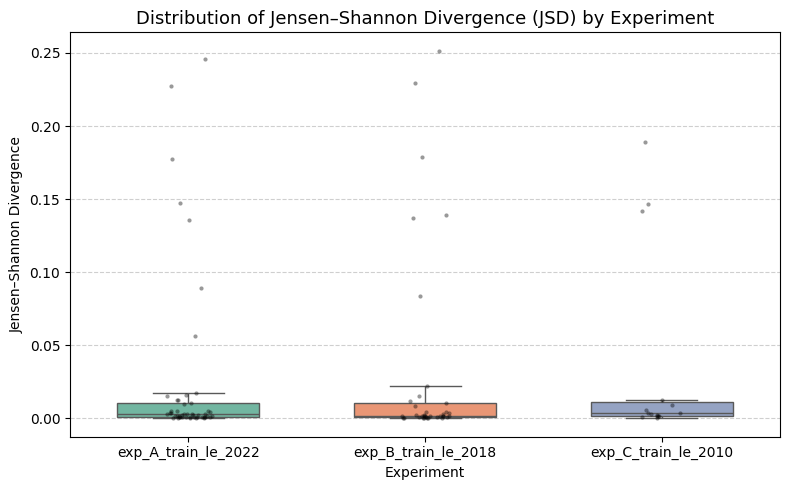

In [286]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x="experiment", y="JSD", data=df_abo_jsd[df_abo_jsd["level"] == "Level 1"],
    palette="Set2", width=0.6,
    showfliers=False  # hide extreme outliers for readability
)
sns.stripplot(
    x="experiment", y="JSD", data=df_abo_jsd[df_abo_jsd["level"] == "Level 1"],
    color="black", alpha=0.4, size=3, jitter=True
)
plt.title("Distribution of Jensen–Shannon Divergence (JSD) by Experiment", fontsize=13)
plt.xlabel("Experiment")
plt.ylabel("Jensen–Shannon Divergence")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


/var/folders/2k/gr93l1l1533bh8zk2y4z2g4h0000gn/T/ipykernel_47944/3029779398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


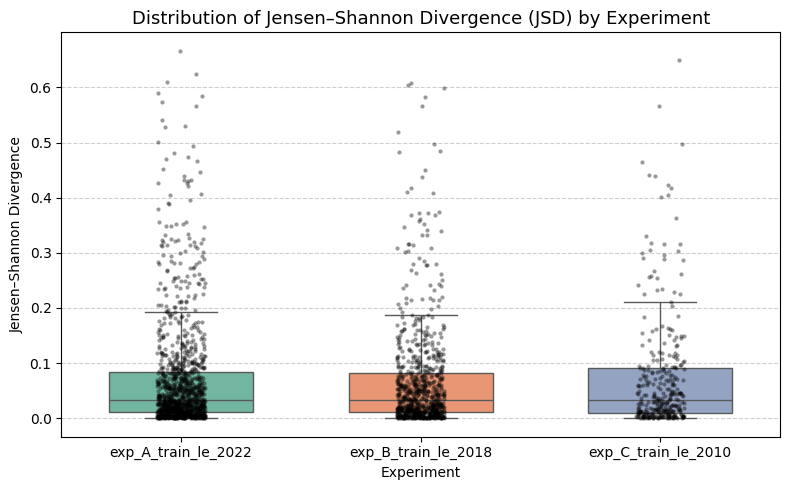

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x="experiment", y="JSD", data=df_homo_jsd,
    palette="Set2", width=0.6,
    showfliers=False  # hide extreme outliers for readability
)
sns.stripplot(
    x="experiment", y="JSD", data=df_homo_jsd,
    color="black", alpha=0.4, size=3, jitter=True
)
plt.title("Distribution of Jensen–Shannon Divergence (JSD) by Experiment", fontsize=13)
plt.xlabel("Experiment")
plt.ylabel("Jensen–Shannon Divergence")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [272]:
abo_g1_a.head()

,experiment,generation,year_t,year_t1,p_prev_strong_anti,p_trans_strong_anti,p_margin_strong_anti,p_hat_strong_anti,p_prev_anti,p_trans_anti,...,p_trans_strong_pro,p_margin_strong_pro,p_hat_strong_pro,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs
0,exp_A_train_le_2022,Baby Boomer,2006,2008,0.169826,0.177485,0.164271,0.170878,0.308336,0.286932,...,0.391971,0.405671,0.398821,0.157098,0.290347,0.153132,0.399422,0.000215,0.000410,0.000114
1,exp_A_train_le_2022,Baby Boomer,2008,2010,0.157098,0.170341,0.178362,0.174351,0.290347,0.284117,...,0.408667,0.365772,0.387219,0.194740,0.240697,0.174067,0.390495,0.001367,0.002525,0.001154
2,exp_A_train_le_2022,Baby Boomer,2010,2012,0.194740,0.179919,0.190973,0.185446,0.240697,0.262099,...,0.427561,0.324813,0.376187,0.184200,0.254281,0.168292,0.393227,0.000188,0.001605,0.003019
3,exp_A_train_le_2022,Baby Boomer,2012,2014,0.184200,0.175332,0.207989,0.191660,0.254281,0.272747,...,0.428296,0.340311,0.384303,0.190650,0.250353,0.147650,0.411347,0.000459,0.001018,0.003813
4,exp_A_train_le_2022,Baby Boomer,2014,2016,0.190650,0.177241,0.201707,0.189474,0.250353,0.262984,...,0.440064,0.354343,0.397203,0.179881,0.257779,0.185050,0.377289,0.000589,0.004754,0.000910


In [ ]:
abo_g1_a.shape, abo_g2_a.shape, abo_g3_a.shape, abo_g4_a.shape

((49, 27), (101, 28), (280, 29), (675, 30))

In [270]:
abo_g1_a.columns.tolist()

['experiment',
 'generation',
 'year_t',
 'year_t1',
 'p_prev_strong_anti',
 'p_trans_strong_anti',
 'p_margin_strong_anti',
 'p_hat_strong_anti',
 'p_prev_anti',
 'p_trans_anti',
 'p_margin_anti',
 'p_hat_anti',
 'p_prev_pro',
 'p_trans_pro',
 'p_margin_pro',
 'p_hat_pro',
 'p_prev_strong_pro',
 'p_trans_strong_pro',
 'p_margin_strong_pro',
 'p_hat_strong_pro',
 'p_obs_strong_anti',
 'p_obs_anti',
 'p_obs_pro',
 'p_obs_strong_pro',
 'JSD_hat_vs_obs',
 'JSD_trans_vs_obs',
 'JSD_margin_vs_obs']

In [271]:
abo_g2_a.columns.tolist()

['experiment',
 'generation',
 'gender',
 'year_t',
 'year_t1',
 'p_prev_strong_anti',
 'p_trans_strong_anti',
 'p_margin_strong_anti',
 'p_hat_strong_anti',
 'p_prev_anti',
 'p_trans_anti',
 'p_margin_anti',
 'p_hat_anti',
 'p_prev_pro',
 'p_trans_pro',
 'p_margin_pro',
 'p_hat_pro',
 'p_prev_strong_pro',
 'p_trans_strong_pro',
 'p_margin_strong_pro',
 'p_hat_strong_pro',
 'p_obs_strong_anti',
 'p_obs_anti',
 'p_obs_pro',
 'p_obs_strong_pro',
 'JSD_hat_vs_obs',
 'JSD_trans_vs_obs',
 'JSD_margin_vs_obs']

In [6]:
# Load our predicted values (p-hat)
df_pred_homosex_g4_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4/forecasts_homosex_exp_A_train_le_2022.csv")
df_pred_homosex_g4_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4/forecasts_homosex_exp_B_train_le_2018.csv")
df_pred_homosex_g4_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4/forecasts_homosex_exp_C_train_le_2010.csv")

# Concatenate
df_pred_homosex_g4 = pd.concat([df_pred_homosex_g4_a, df_pred_homosex_g4_b, df_pred_homosex_g4_c], axis=0)

# Load our predicted values (p-hat)
df_pred_abortion_g4_a = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4/forecasts_abortion_exp_A_train_le_2022.csv")
df_pred_abortion_g4_b = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4/forecasts_abortion_exp_B_train_le_2018.csv")
df_pred_abortion_g4_c = pd.read_csv("/Users/wooyongjung/Documents/WJ_Projects/LLM_POC_Study_2025_v2/data/r_trial_results/group4/forecasts_abortion_exp_C_train_le_2010.csv")

# Concatenate
df_pred_abortion_g4 = pd.concat([df_pred_abortion_g4_a, df_pred_abortion_g4_b, df_pred_abortion_g4_c], axis=0)


In [7]:
df_pred_homosex_g4.shape

(1301, 30)

In [8]:
df_pred_homosex_g4.head()

,experiment,generation,gender,race,edu_level,target_year,anchor_year,p_prev_always_wrong,p_trans_always_wrong,p_margin_always_wrong,...,p_trans_not_wrong_at_all,p_margin_not_wrong_at_all,p_hat_not_wrong_at_all,p_obs_always_wrong,p_obs_almost_always_wrong,p_obs_sometimes_wrong,p_obs_not_wrong_at_all,JSD_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs
0,exp_A_train_le_2022,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2024,2022,0.578647,0.476052,0.403922,...,0.286028,0.592326,0.439177,0.341443,0.000000,0.311933,0.346624,0.081229,0.082348,0.119938
1,exp_A_train_le_2022,Baby Boomer,Female,Black,Graduate Degree,2024,2022,0.779745,0.498119,0.554223,...,0.244671,0.445058,0.344865,0.127967,0.460101,0.000000,0.411932,0.166061,0.153417,0.230183
2,exp_A_train_le_2022,Baby Boomer,Female,Black,Less or equal to high school,2024,2022,0.627939,0.619920,0.421533,...,0.238526,0.560548,0.399537,0.729390,0.045802,0.026032,0.198775,0.026245,0.009393,0.074569
3,exp_A_train_le_2022,Baby Boomer,Female,Other,Associate or Bachelor's Degree,2024,2022,0.328288,0.233693,0.549996,...,0.539582,0.447465,0.493524,0.203023,0.000000,0.000000,0.796977,0.072981,0.091586,0.067273
4,exp_A_train_le_2022,Baby Boomer,Female,Other,Graduate Degree,2024,2022,0.000000,0.136407,0.042317,...,0.531251,0.945036,0.738144,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_4):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle="--", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

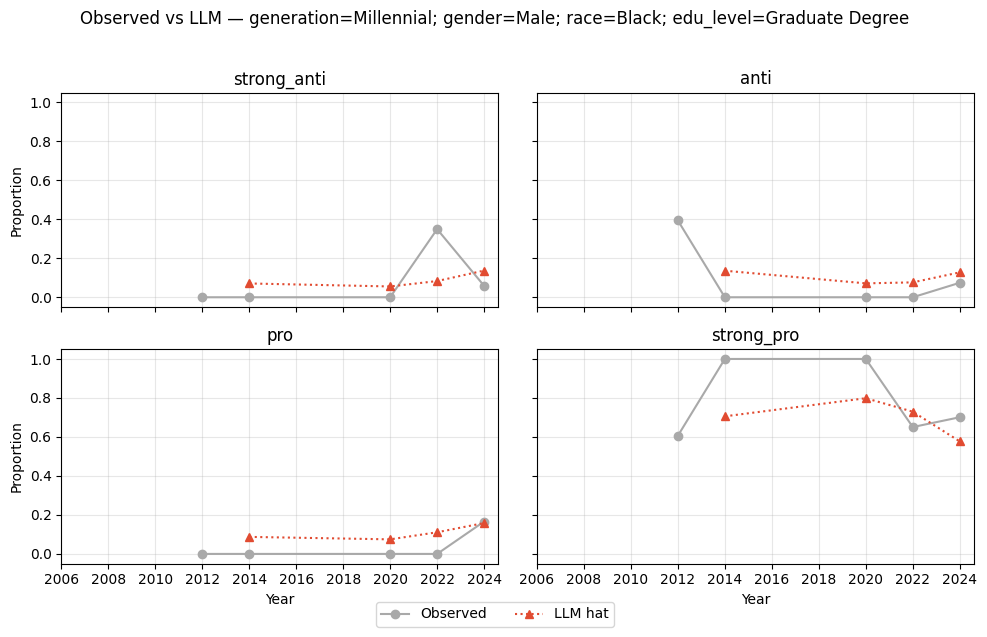

In [62]:
g = ('Millennial', 'Male', 'Black', "Graduate Degree")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, llm_series=("hat",))

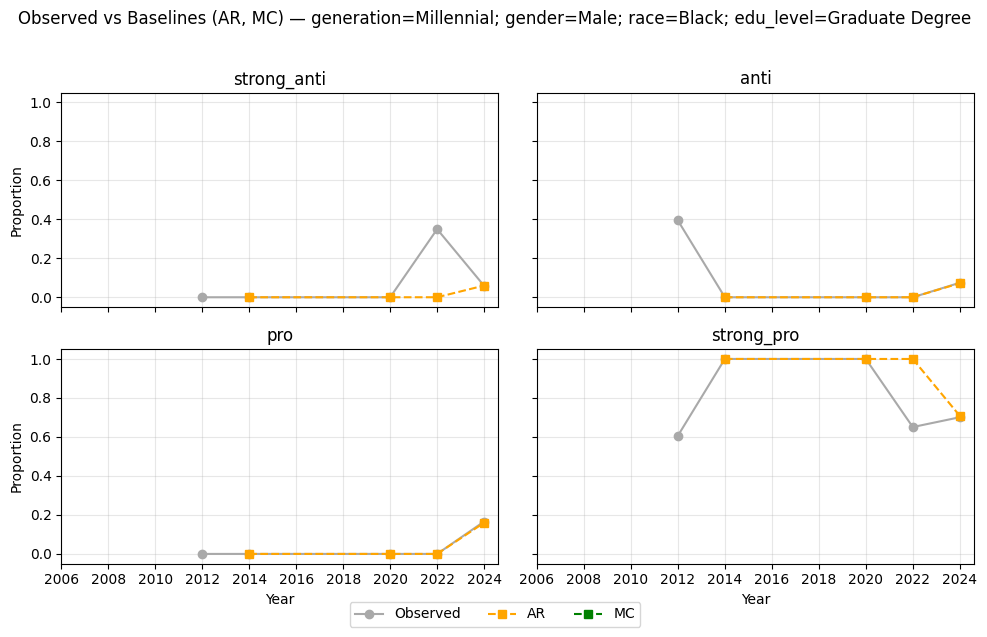

In [63]:
g = ('Millennial', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_baselines(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, llm_series=("hat",))

In [46]:
a = {v:i for i, v in enumerate(ABORT4)}
df_cs_abo['abortion_int4'] = df_cs_abo['abortion_att4'].map(a)

In [58]:
# Calculate weighted means and standard errors
df_cs_abo.groupby(['generation','edu_level','gender','race']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False).head(10)

,generation,edu_level,gender,race,wtssps_mean,wtssps_se
42,Generation Z,Associate or Bachelor's Degree,Male,Other,1.923226,1.372107
45,Generation Z,Graduate Degree,Female,Other,0.732209,0.529142
85,Silent Generation,Graduate Degree,Male,Black,1.645595,0.472436
83,Silent Generation,Graduate Degree,Female,Other,1.133605,0.438481
38,Generation Z,Associate or Bachelor's Degree,Female,Black,0.988419,0.433524
80,Silent Generation,Associate or Bachelor's Degree,Male,Other,1.174328,0.407938
39,Generation Z,Associate or Bachelor's Degree,Female,Other,0.843658,0.323392
66,Millennial,Graduate Degree,Male,Black,1.125565,0.318219
53,Generation Z,Less or equal to high school,Male,Other,2.008937,0.312843
86,Silent Generation,Graduate Degree,Male,Other,1.703957,0.279423


In [47]:
df_cs_abo.head()

,yearid,year,generation,edu_level,gender,race,political_views,natenvir,trust,abortion_att4,homosex,wtssps,abortion_int4
0,2006_4,2006,Baby Boomer,Less or equal to high school,Female,Black,Liberal,NaN,depends,strong_pro,not_wrong_at_all,0.385372,3
1,2006_5,2006,Millennial,Less or equal to high school,Male,Black,Liberal,NaN,distrust,strong_pro,always_wrong,1.387133,3
2,2006_9,2006,Millennial,Associate or Bachelor's Degree,Female,Black,Conservative,NaN,distrust,strong_pro,NaN,0.421749,3
3,2006_10,2006,Generation X,Graduate Degree,Female,Other,Liberal,too_little,NaN,strong_pro,always_wrong,0.527395,3
4,2006_12,2006,Baby Boomer,Less or equal to high school,Male,Black,Moderate,NaN,distrust,strong_anti,NaN,2.423198,0


## Abortion, Group 4

In [11]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 11), (17576, 12), (13647, 11))

In [16]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_4
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g4 = {}
effN_cs_g4 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_4):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs_g4[(g_vals, y)] = p
        effN_cs_g4[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C_g4 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g4 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g4 in df_pl_abo.groupby("yearid"):
    df_id_g4 = df_id_g4.sort_values("year")
    # collapse duplicates per year if any
    df_id_g4 = df_id_g4.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g4["year"].values.tolist()
    atts  = df_id_g4["abortion_att4"].values.tolist()
    wgts  = df_id_g4["w"].values.astype(float).tolist()
    gens  = df_id_g4["generation"].values.tolist()
    gend  = df_id_g4["gender"].values.tolist()
    race  = df_id_g4["race"].values.tolist()
    edu = df_id_g4["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1 and len(set(race))==1 and len(set(edu))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0],race[0],edu[0])

    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g4[(g,t,Δ)][ai, aj] += w
        Nfrom_g4[(g,t,Δ)][ai] += w

In [27]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g4 = cs_ar_fit_and_forecast(p_cs_g4, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g4 = panel_markov_forecast(p_cs_g4, C_g4, Nfrom_g4, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g4.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_4, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g4[(g, y)]
        if (g, y) in p_hat_AR_g4:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g4[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g4:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g4[(g,y)], p_obs))
        rows.append(rec)

bench_abo_g4 = pd.DataFrame(rows)
bench_abo_g4.head()

,generation,gender,race,edu_level,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.028272,0.346626
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.357902,0.064341
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.398768,0.229432
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.102151,0.196799
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.117836,0.055920


In [ ]:
bench_abo_g4['generation'].value_counts()

generation
Baby Boomer          161
Generation X         160
Millennial           151
Silent Generation    118
nan                   48
Generation Z          37
Name: count, dtype: int64

In [28]:
# Load our predicted values (p-hat)
df_pred_g4 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g4.csv")

# Convert year 2021 to 2020
df_pred_g4.loc[df_pred_g4['year'] == 2021, 'year'] = 2020
df_pred_g4.loc[df_pred_g4['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g4['year_t'] = df_pred_g4['year_prev']
df_pred_g4['year_t1'] = df_pred_g4['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g4['generation'] = df_pred_g4['generation'].map(gen_map)

df_pred_g4.head(2)

,generation,gender,race,edu_level,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.156398,0.409694,0.208237,0.225671,...,0.0,0.079963,0.000000,0.920037,0.099381,0.176772,0.248766,0.004162,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.000000,0.079963,0.000000,0.920037,...,0.0,0.209616,0.266931,0.523453,0.066700,0.176592,0.043720,0.131728,2008,2010


In [29]:
df_pred_g4.head(2)

,generation,gender,race,edu_level,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.156398,0.409694,0.208237,0.225671,...,0.0,0.079963,0.000000,0.920037,0.099381,0.176772,0.248766,0.004162,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.000000,0.079963,0.000000,0.920037,...,0.0,0.209616,0.266931,0.523453,0.066700,0.176592,0.043720,0.131728,2008,2010


In [30]:
df_pred_g4['year_prev'].value_counts()

year_prev
2020    98
2022    90
2016    77
2014    74
2018    72
2010    68
2012    67
2008    65
2006    64
Name: count, dtype: int64

In [45]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_4):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        # if i // 2 == 1:
        #     ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="upper right", ncol=1, bbox_to_anchor=(0.25, 0.4))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [46]:
# Calculate weighted means and standard errors for G4
temp = df_cs_abo.groupby(['generation', 'gender', 'race', 'edu_level']).agg(
        wtssps_mean=('wtssps', 'mean'),
        wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        count=('wtssps', 'size')
    ).reset_index().sort_values('wtssps_se', ascending=False)
# Reindex
temp = temp.reset_index(drop=True)

temp[temp['count']>=100].tail(15)

,generation,gender,race,edu_level,wtssps_mean,wtssps_se,count
71,Silent Generation,Male,White,Less or equal to high school,1.083917,0.036622,377
72,Generation X,Male,White,Associate or Bachelor's Degree,1.001261,0.036377,398
73,Millennial,Female,Black,Less or equal to high school,0.751267,0.035743,243
74,Generation X,Female,White,Graduate Degree,0.808297,0.034022,224
75,Baby Boomer,Male,White,Associate or Bachelor's Degree,0.962295,0.032837,478
77,Generation X,Male,White,Less or equal to high school,1.103672,0.032350,601
78,Millennial,Female,White,Associate or Bachelor's Degree,0.893277,0.031132,376
79,Generation X,Female,White,Less or equal to high school,1.036242,0.030425,712
80,Baby Boomer,Female,White,Associate or Bachelor's Degree,0.876174,0.030323,542
81,Baby Boomer,Female,White,Graduate Degree,0.771124,0.029287,283


In [47]:
df_pred_g4['generation'].value_counts()

generation
Baby Boomer          161
Generation X         160
Millennial           151
Silent Generation    118
Generation Z          37
Name: count, dtype: int64

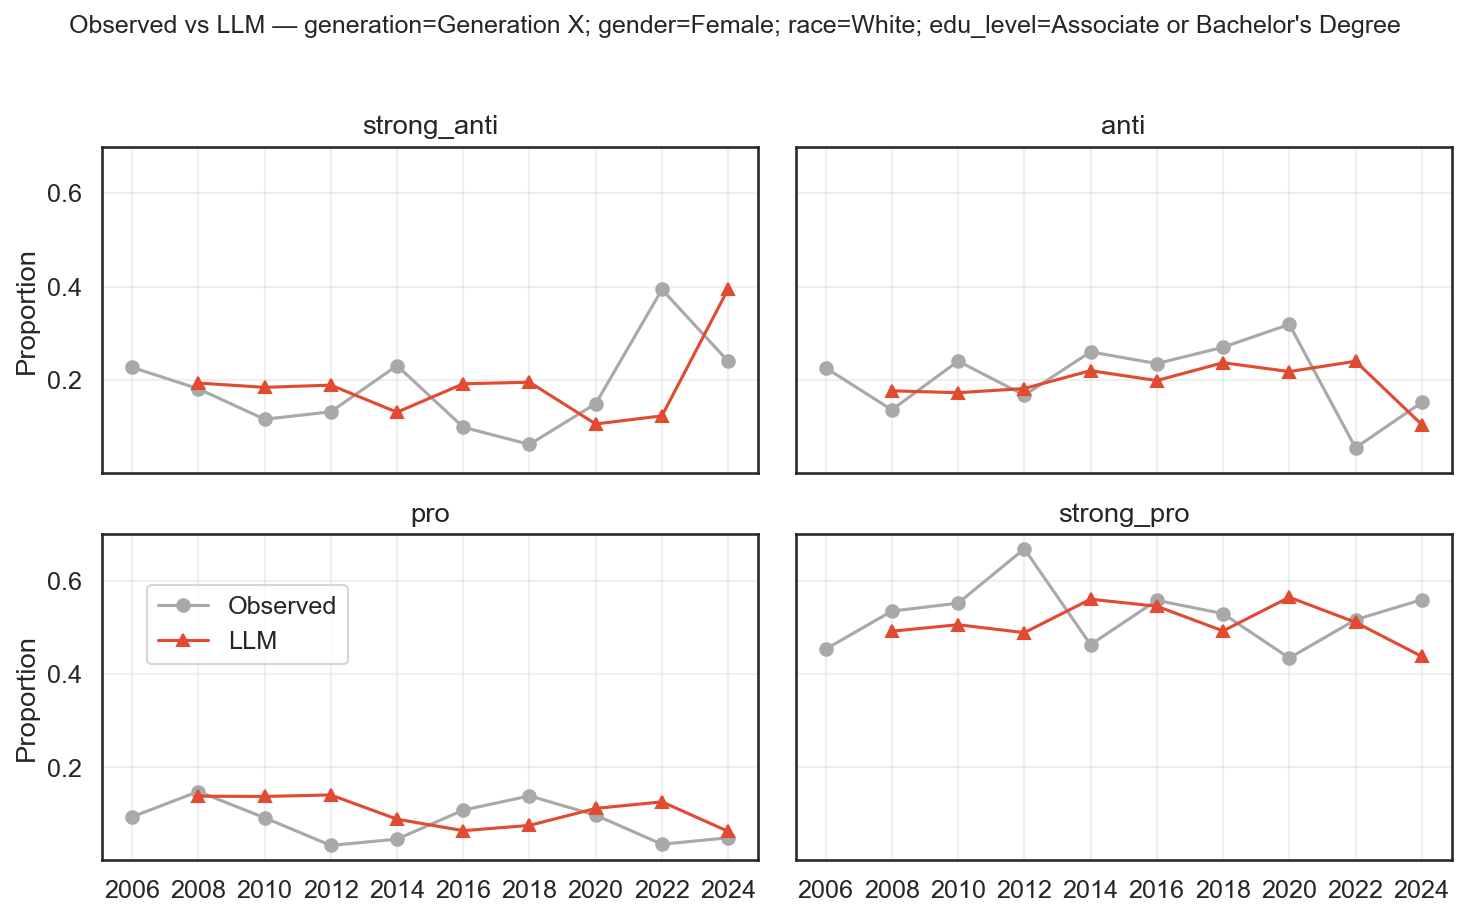

In [49]:
g = ('Generation X', "Female", "White", "Associate or Bachelor's Degree")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

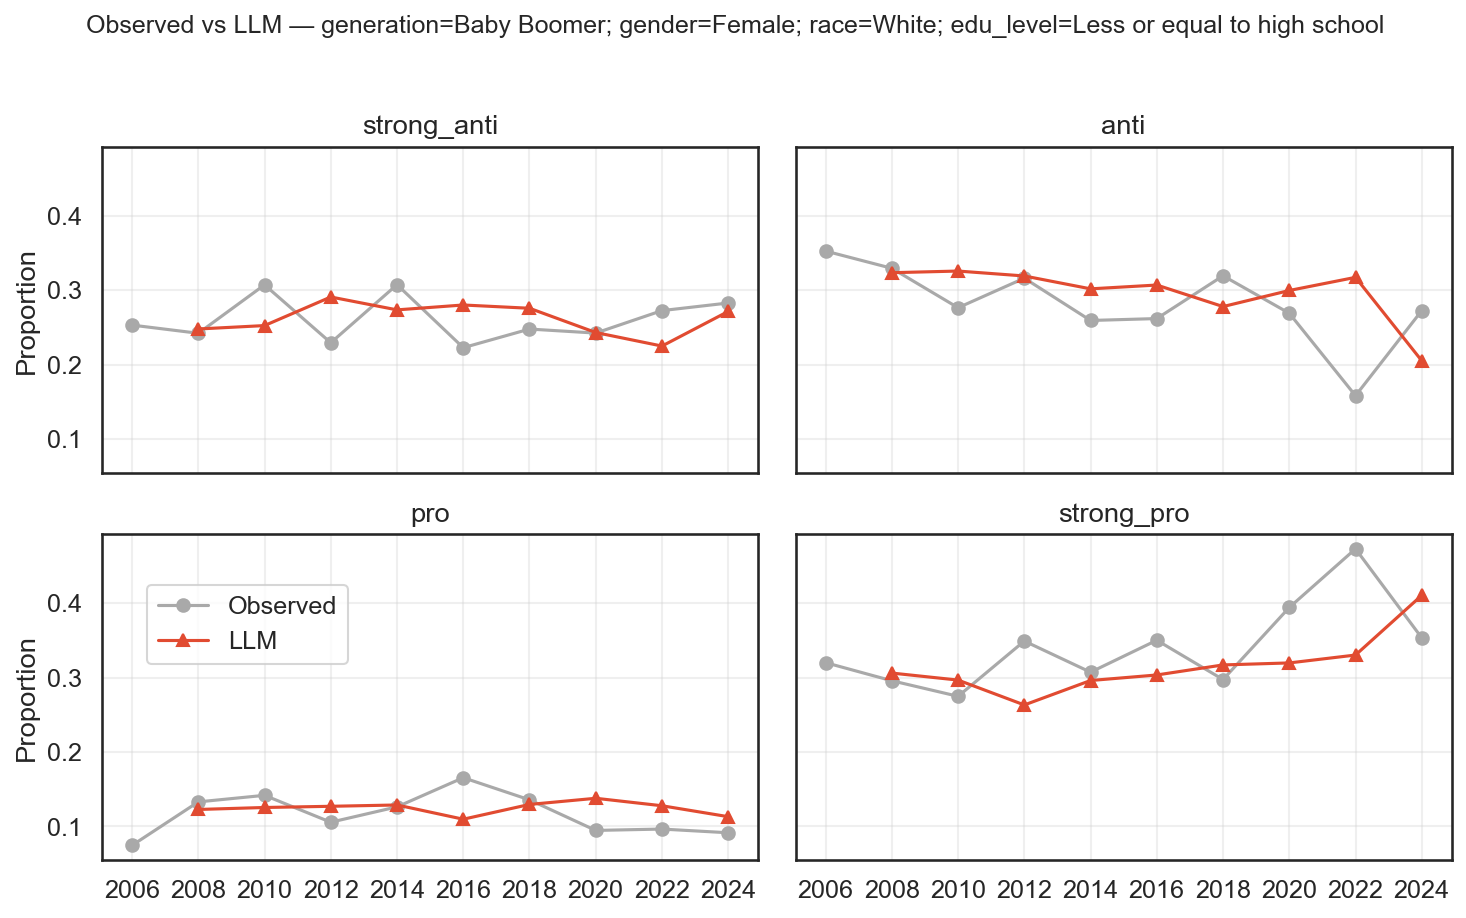

In [48]:
g = ('Baby Boomer', "Female", "White", "Less or equal to high school")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

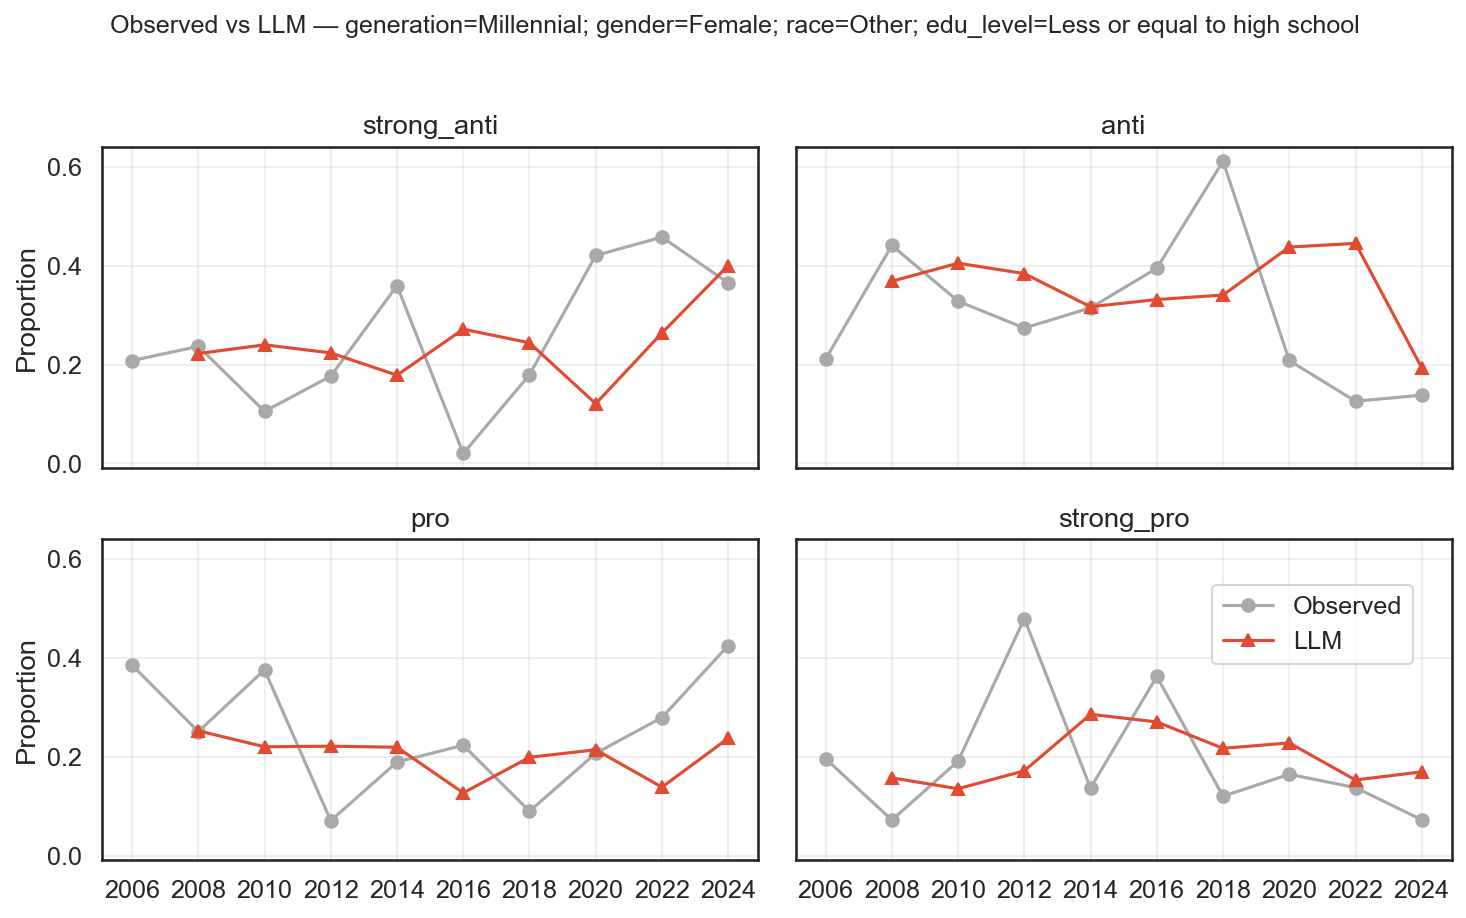

In [672]:
g = ('Millennial', "Female", "Other", "Less or equal to high school")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

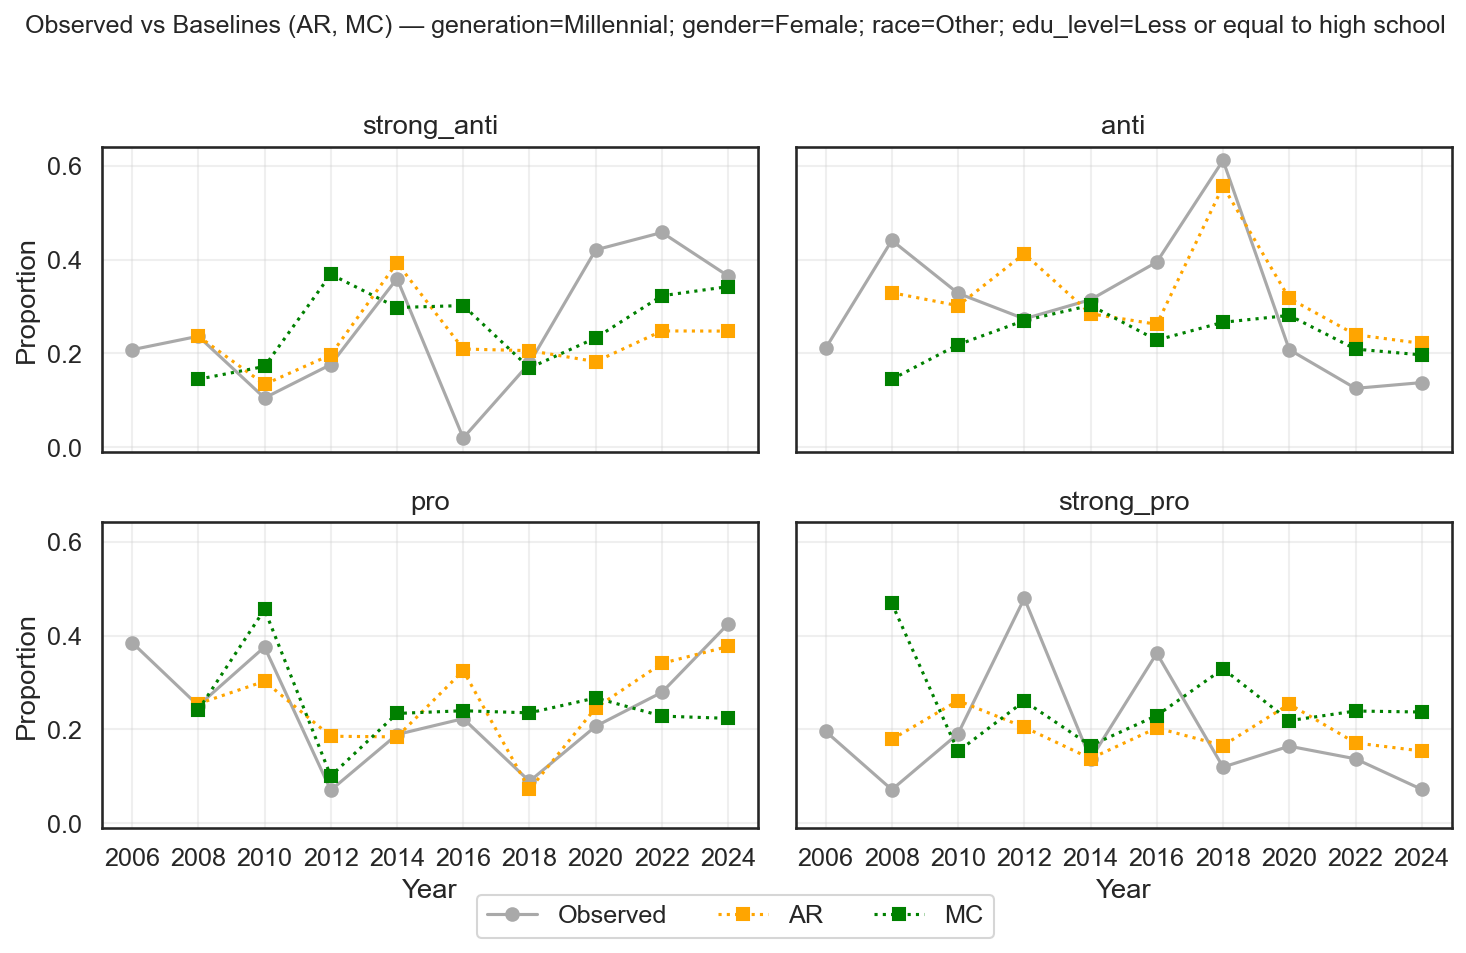

In [673]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

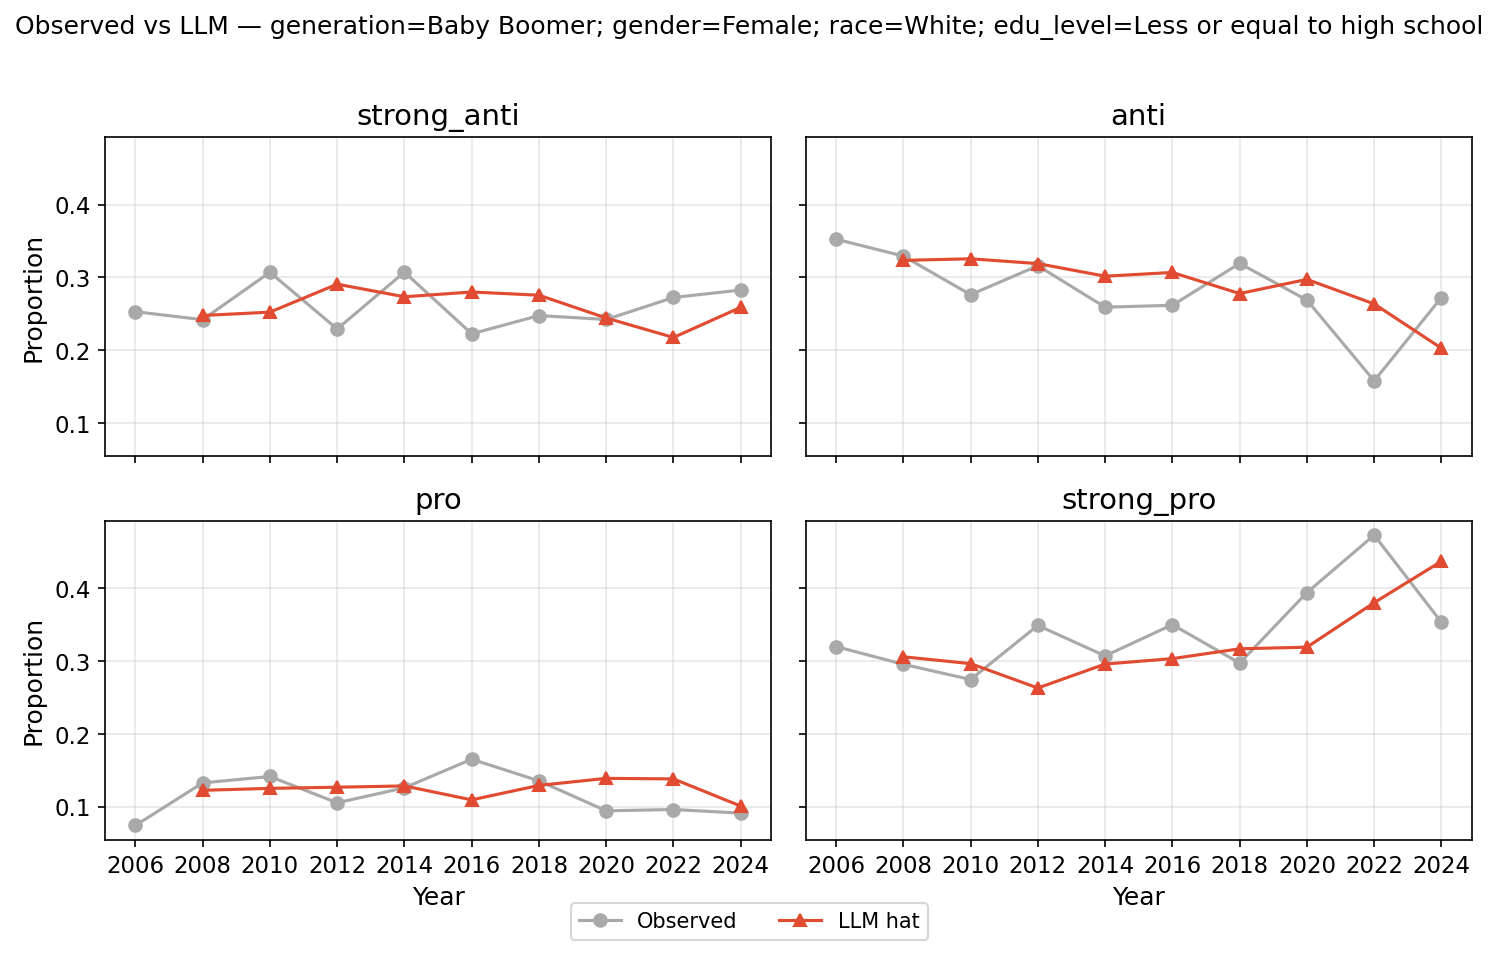

In [332]:
g = ('Baby Boomer', "Female", "White", "Less or equal to high school")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

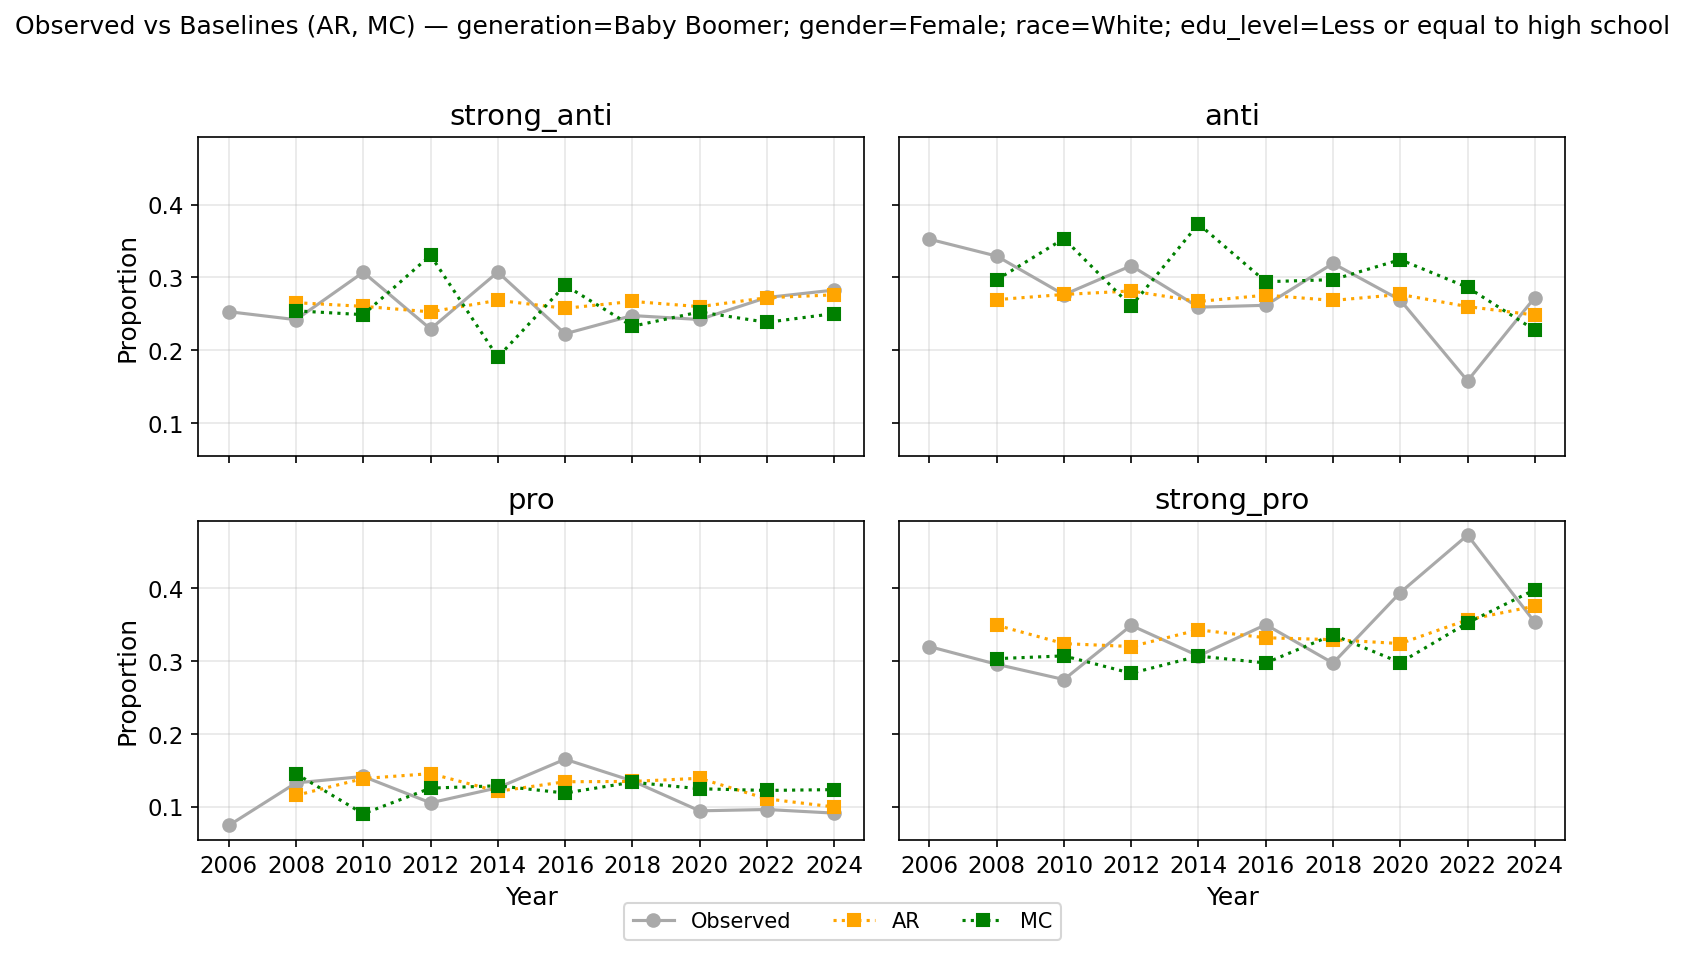

In [333]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

In [674]:
# Compare JSD
bt_abo_g4 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g4.csv")

#gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
#bt_abo_g2['generation'] = bt_abo_g2['generation'].map(gen_map)

bt_abo_g4.head()

,year_t,year_t1,generation,gender,race,edu_level,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,Female,Black,Associate or Bachelor's Degree,0.066700,0.043720,0.131728,0.176592
1,2008,2010,Baby Boomer,Female,Black,Graduate Degree,0.052464,0.111164,0.000221,0.083271
2,2008,2010,Baby Boomer,Female,Black,Less or equal to high school,0.037897,0.048121,0.032615,0.117326
3,2008,2010,Baby Boomer,Female,Other,Associate or Bachelor's Degree,0.195751,0.126384,0.357313,0.326649
4,2008,2010,Baby Boomer,Female,Other,Graduate Degree,0.615573,0.564847,0.685873,0.645377


In [675]:
bt_abo_g4['year_t'].value_counts()

year_t
2020    91
2022    90
2016    71
2018    70
2014    69
2012    63
2010    61
2008    60
Name: count, dtype: int64

In [676]:
bench_abo_g4.head()

,generation,gender,race,edu_level,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.028272,0.346626
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.357902,0.064341
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.398768,0.229432
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.102151,0.196799
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.117836,0.055920


In [677]:
# Convert bench to long format
bench_abo_g4_long = pd.melt(bench_abo_g4, id_vars=GROUP_COLS_4 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'MLAR', 'JSD_MC': 'MTM'}
bench_abo_g4_long['model'] = bench_abo_g4_long['model'].map(model_map)

# Prepare the data for plotting
bt_abo_g4['model'] = 'LLM'
bt_abo_g4 = bt_abo_g4.rename(columns={'JSD_hat':'jsd'})
combined_abo_g4 = pd.concat([bench_abo_g4_long, bt_abo_g4[['generation','gender','race','edu_level','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_abo_g4.head()

,generation,gender,race,edu_level,year_t,year_t1,model,jsd
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,MLAR,0.028272
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,MLAR,0.357902
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,MLAR,0.398768
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,MLAR,0.102151
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,MLAR,0.117836


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2906691004.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


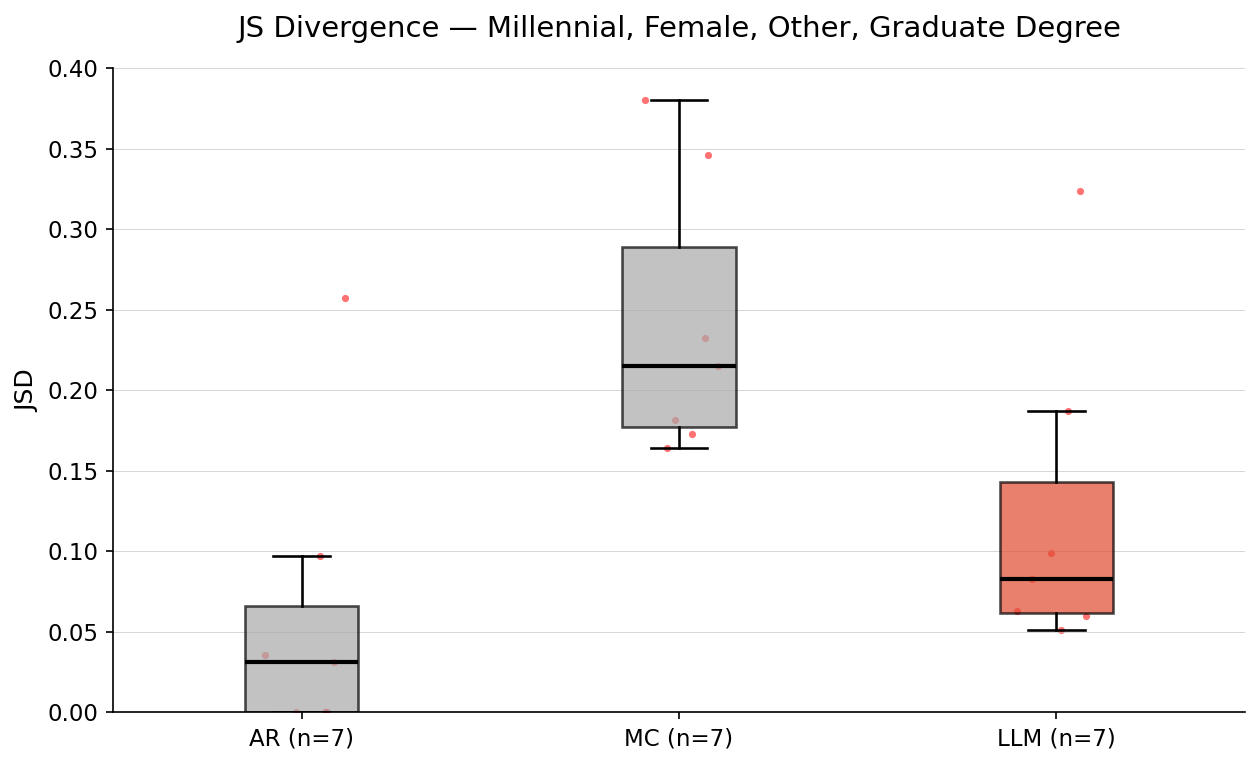

In [362]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g4[(combined_g4['generation'] == 'Millennial') & ((combined_g4['gender'] == 'Female')) & ((combined_g4['race'] == 'Other')) & ((combined_g4['edu_level'] == 'Graduate Degree')) & (combined_g4['year_t1'] >= 2010)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence — Millennial, Female, Other, Graduate Degree', pad=15)
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.4)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3115882972.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


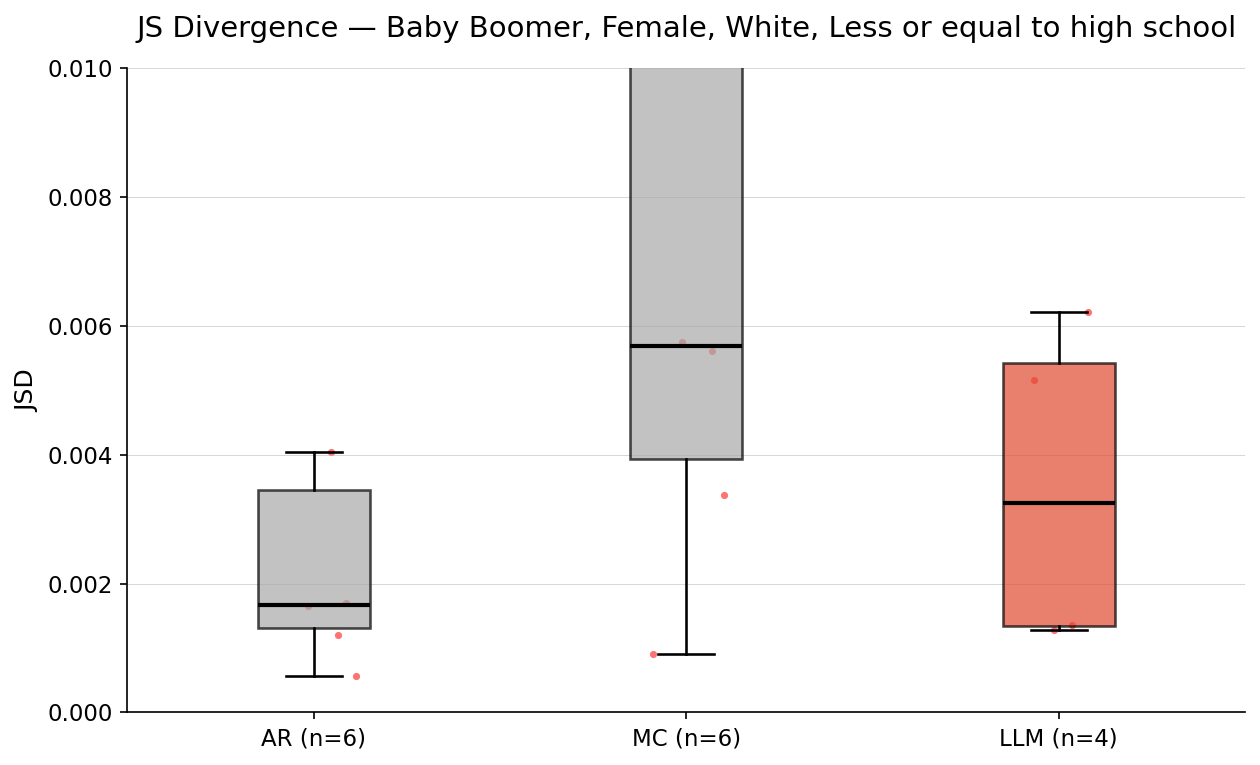

In [336]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g4[(combined_g4['generation'] == 'Baby Boomer') & ((combined_g4['gender'] == 'Female')) & ((combined_g4['race'] == 'White')) & ((combined_g4['edu_level'] == 'Less or equal to high school')) & (combined_g4['year_t'] >= 2012)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence — Baby Boomer, Female, White, Less or equal to high school', pad=15)
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.01)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3289601608.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


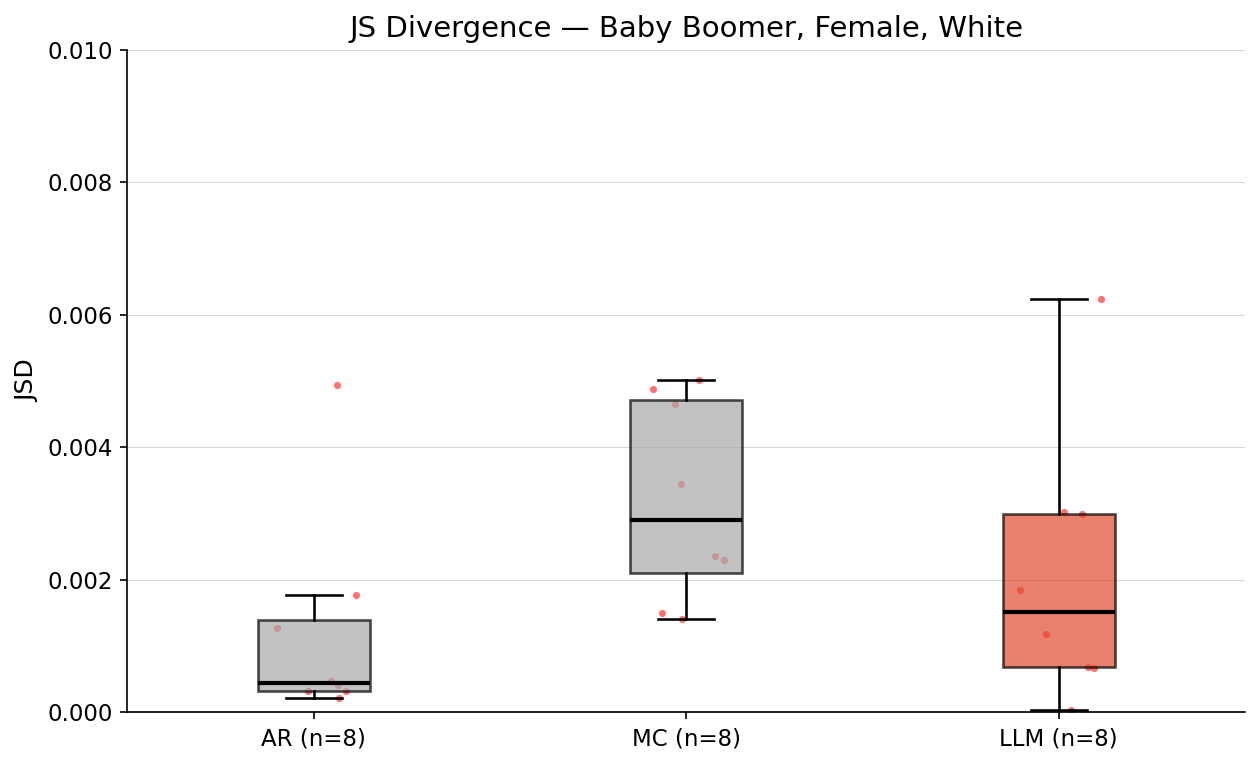

In [ ]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g3[(combined_g3['generation'] == 'Baby Boomer') & ((combined_g3['gender'] == 'Female')) & ((combined_g3['race'] == 'White')) & (combined_g3['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence — Baby Boomer, Female, White')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.01)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

## Abortion, Group 3

In [284]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 12))

In [285]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_3
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g3 = {}
effN_cs_g3 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_3):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs_g3[(g_vals, y)] = p
        effN_cs_g3[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C_g3 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g3 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g3 in df_pl_abo.groupby("yearid"):
    df_id_g3 = df_id_g3.sort_values("year")
    # collapse duplicates per year if any
    df_id_g3 = df_id_g3.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g3["year"].values.tolist()
    atts  = df_id_g3["abortion_att4"].values.tolist()
    wgts  = df_id_g3["w"].values.astype(float).tolist()
    gens  = df_id_g3["generation"].values.tolist()
    gend  = df_id_g3["gender"].values.tolist()
    race  = df_id_g3["race"].values.tolist()
    # edu = df_id_g3["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1 and len(set(race))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0],race[0])
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g3[(g,t,Δ)][ai, aj] += w
        Nfrom_g3[(g,t,Δ)][ai] += w

In [298]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g3 = cs_ar_fit_and_forecast(p_cs_g3, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g3 = panel_markov_forecast(p_cs_g3, C_g3, Nfrom_g3, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g3.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_3, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g3[(g, y)]
        if (g, y) in p_hat_AR_g3:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g3[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g3:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g3[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,gender,race,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,2006,2008,0.004287,0.027564
1,Baby Boomer,Female,Black,2008,2010,0.027487,0.030076
2,Baby Boomer,Female,Black,2010,2012,0.002822,0.020673
3,Baby Boomer,Female,Black,2012,2014,0.009083,0.056918
4,Baby Boomer,Female,Black,2014,2016,0.020816,0.024423


In [287]:
# Load our predicted values (p-hat)
df_pred_g3 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g3.csv")

# Convert year 2021 to 2020
df_pred_g3.loc[df_pred_g3['year'] == 2021, 'year'] = 2020
df_pred_g3.loc[df_pred_g3['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g3['year_t'] = df_pred_g3['year_prev']
df_pred_g3['year_t1'] = df_pred_g3['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g3['generation'] = df_pred_g3['generation'].map(gen_map)

df_pred_g3.head(2)

,generation,gender,race,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,p_trans_strong_anti,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,2006,2008,0.277761,0.263797,0.247547,0.210895,0.186944,...,0.098110,0.232484,0.343094,0.326311,0.003111,0.034021,0.011961,0.000006,2006,2008
1,Baby Boomer,Female,Black,2008,2010,0.098110,0.232484,0.343094,0.326311,0.126484,...,0.246066,0.286126,0.276101,0.191707,0.026532,0.109602,0.025744,0.031815,2008,2010


In [288]:
df_pred_g3['year_prev'].value_counts()

year_prev
2020    46
2022    38
2016    32
2018    32
2014    28
2006    26
2012    26
2008    26
2010    26
Name: count, dtype: int64

In [289]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_3):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [365]:
# Calculate weighted means and standard errors for G3
temp = df_cs_abo.groupby(['generation', 'gender', 'race']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    count=('wtssps', 'size')
).reset_index().sort_values('wtssps_se', ascending=False)

temp[temp['count']>=100].head(15)

,generation,gender,race,wtssps_mean,wtssps_se,count
19,Generation Z,Male,White,1.539946,0.141048,122
16,Generation Z,Female,White,1.464787,0.132161,104
23,Millennial,Female,Other,1.360244,0.084795,231
26,Millennial,Male,Other,1.496934,0.070625,210
25,Millennial,Male,Black,1.088693,0.063502,199
29,Silent Generation,Female,Black,0.775546,0.061989,103
4,Baby Boomer,Male,Other,1.069239,0.054688,142
7,Generation X,Female,Other,1.057967,0.050755,243
10,Generation X,Male,Other,1.149834,0.050114,248
9,Generation X,Male,Black,0.902677,0.046584,229


In [291]:
df_pred_g3['generation'].value_counts()

generation
Millennial           58
Baby Boomer          57
Generation X         56
Silent Generation    52
Generation Z         26
Name: count, dtype: int64

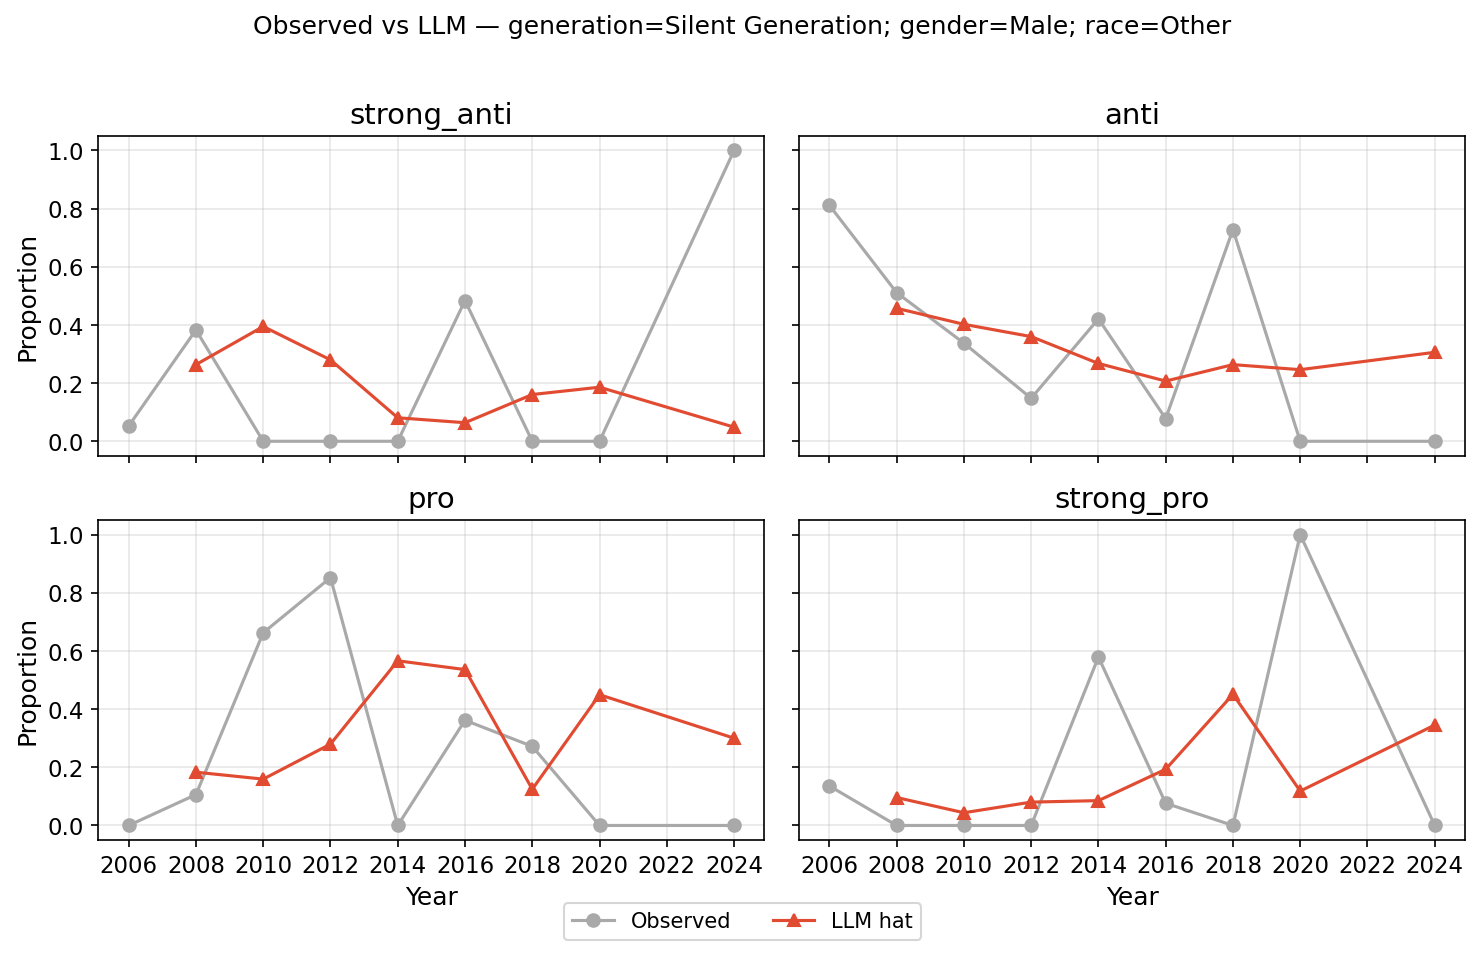

In [293]:
g = ('Silent Generation', "Male", "Other")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g3, p_hat_AR_g3, p_hat_MC_g3, bt=df_pred_g3, llm_series=("hat",))

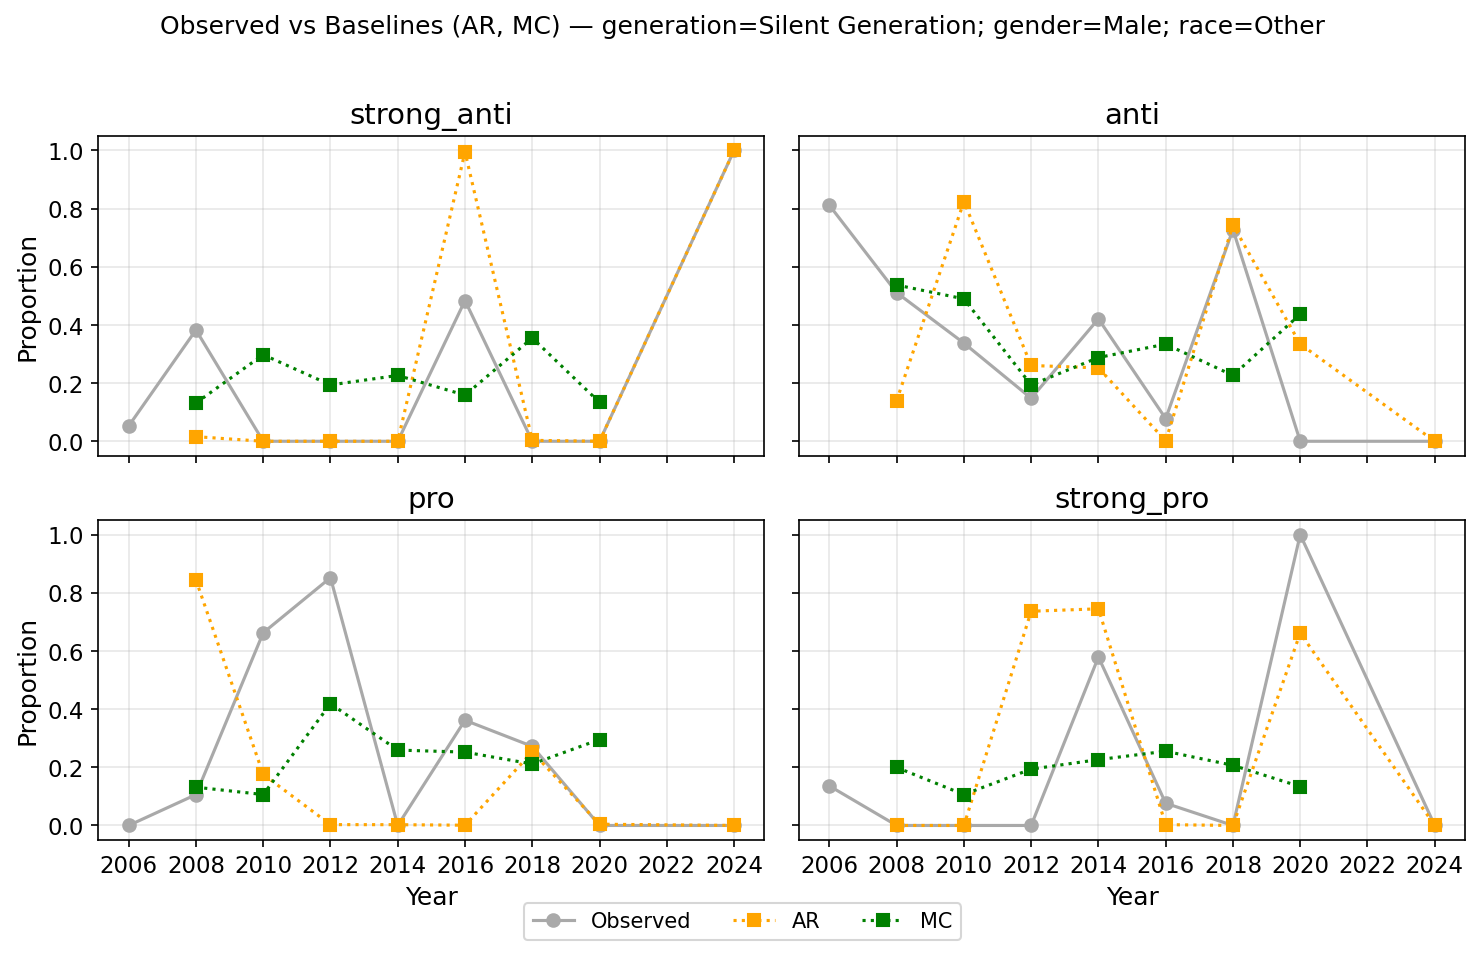

In [294]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g3, p_hat_AR_g3, p_hat_MC_g3, bt=df_pred_g3, llm_series=("hat",))

In [295]:
# Compare JSD
bt_abo_g3 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g3.csv")

#gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
#bt_abo_g2['generation'] = bt_abo_g2['generation'].map(gen_map)

bt_abo_g3.head()

,year_t,year_t1,generation,gender,race,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,Female,Black,0.026532,0.025744,0.031815,0.109602
1,2008,2010,Baby Boomer,Female,Other,0.056026,0.062437,0.052337,0.121474
2,2008,2010,Baby Boomer,Female,White,0.003020,0.004708,0.003628,0.038822
3,2008,2010,Baby Boomer,Male,Black,0.012364,0.018173,0.009895,0.088633
4,2008,2010,Baby Boomer,Male,Other,0.079590,0.106140,0.054603,0.161465


In [297]:
bench.head()

,generation,gender,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,2006,2008,0.004287,0.027564
1,Baby Boomer,Female,2008,2010,0.027487,0.030076
2,Baby Boomer,Female,2010,2012,0.002822,0.020673
3,Baby Boomer,Female,2012,2014,0.009083,0.056918
4,Baby Boomer,Female,2014,2016,0.020816,0.024423


In [299]:
# Convert bench to long format
bench_long = pd.melt(bench, id_vars=GROUP_COLS_3 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'AR', 'JSD_MC': 'MC'}
bench_long['model'] = bench_long['model'].map(model_map)

# Prepare the data for plotting
bt_abo_g3['model'] = 'LLM'
bt_abo_g3 = bt_abo_g3.rename(columns={'JSD_hat':'jsd'})
combined_g3 = pd.concat([bench_long, bt_abo_g3[['generation','gender','race','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_g3.head()

,generation,gender,race,year_t,year_t1,model,jsd
0,Baby Boomer,Female,Black,2006,2008,AR,0.004287
1,Baby Boomer,Female,Black,2008,2010,AR,0.027487
2,Baby Boomer,Female,Black,2010,2012,AR,0.002822
3,Baby Boomer,Female,Black,2012,2014,AR,0.009083
4,Baby Boomer,Female,Black,2014,2016,AR,0.020816


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/668028575.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


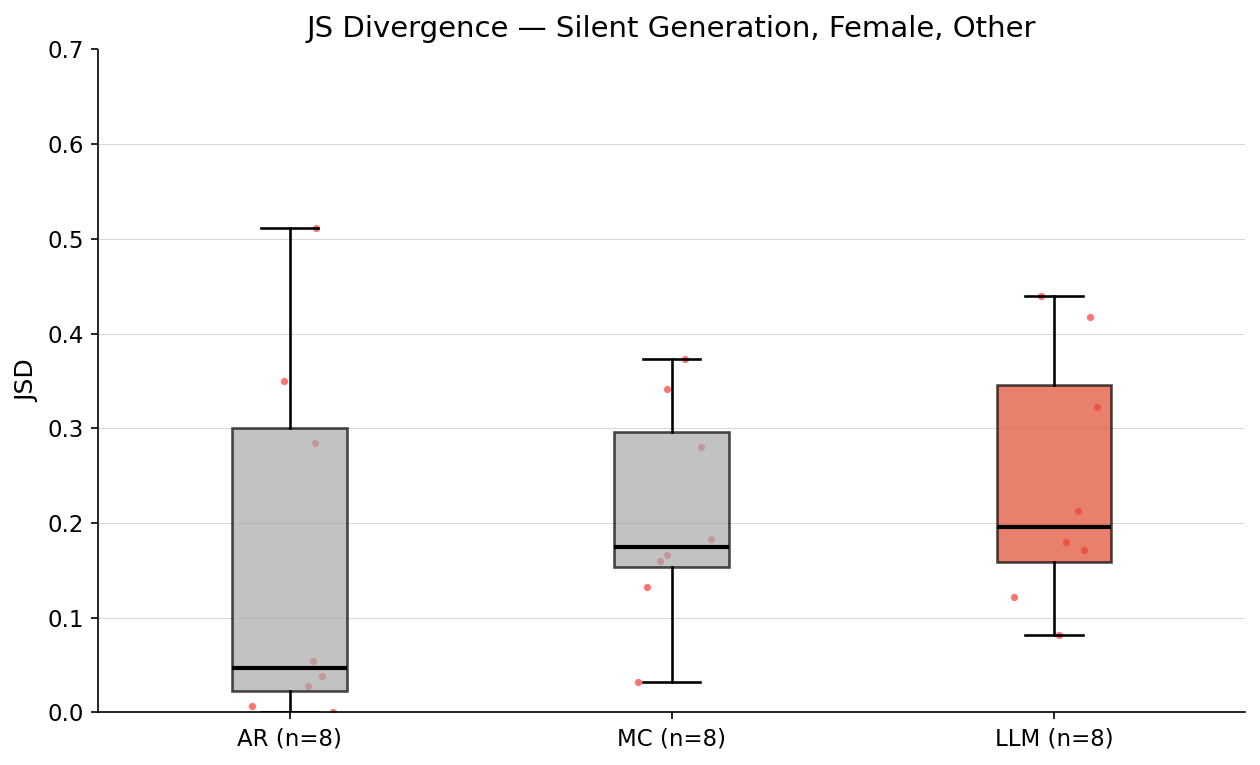

In [303]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g3[(combined_g3['generation'] == 'Silent Generation') & ((combined_g3['gender'] == 'Female')) & ((combined_g3['race'] == 'Other')) & (combined_g3['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence — Silent Generation, Female, Other')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.7)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3289601608.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


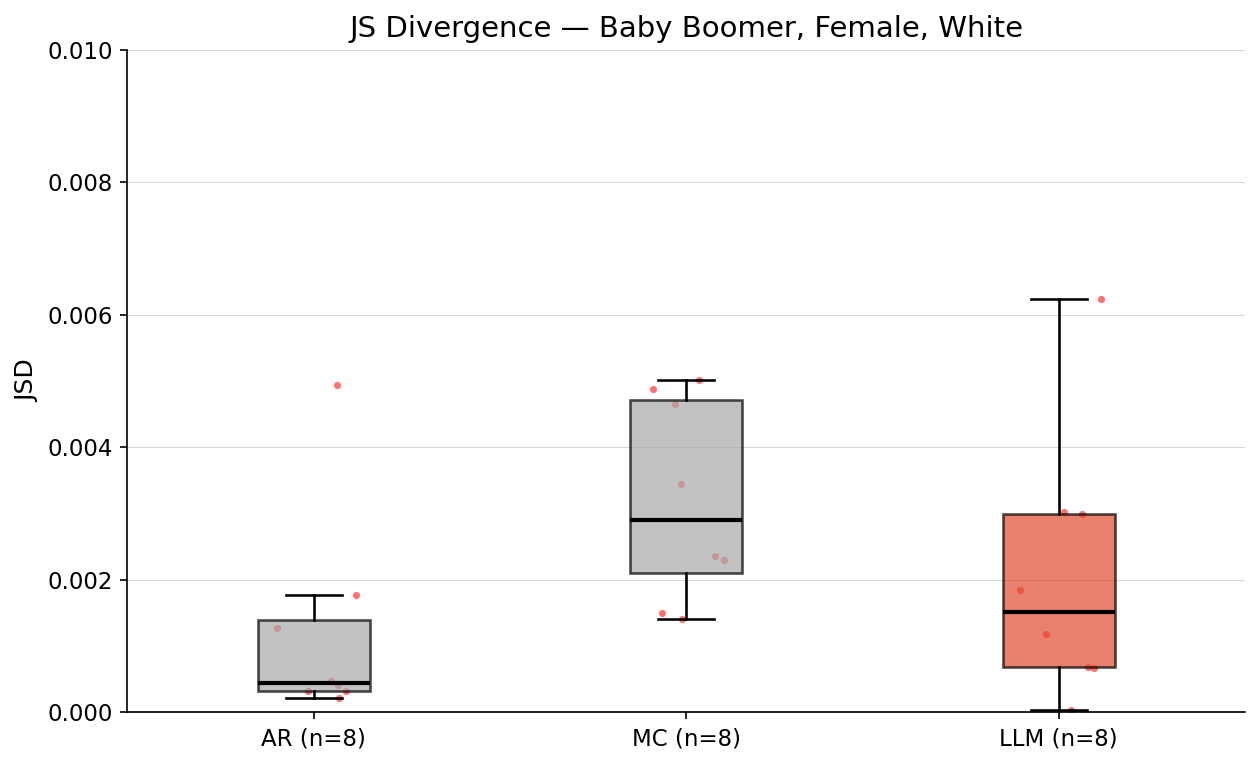

In [306]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g3[(combined_g3['generation'] == 'Baby Boomer') & ((combined_g3['gender'] == 'Female')) & ((combined_g3['race'] == 'White')) & (combined_g3['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence — Baby Boomer, Female, White')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.01)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

## Group 1

In [50]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 11))

In [51]:
df_cs_abo.head()

,yearid,year,generation,edu_level,gender,race,political_views,natenvir,trust,abortion_att4,homosex,wtssps
0,2006_4,2006,Baby Boomer,Less or equal to high school,Female,Black,Liberal,NaN,depends,strong_pro,not_wrong_at_all,0.385372
1,2006_5,2006,Millennial,Less or equal to high school,Male,Black,Liberal,NaN,distrust,strong_pro,always_wrong,1.387133
2,2006_9,2006,Millennial,Associate or Bachelor's Degree,Female,Black,Conservative,NaN,distrust,strong_pro,NaN,0.421749
3,2006_10,2006,Generation X,Graduate Degree,Female,Other,Liberal,too_little,NaN,strong_pro,always_wrong,0.527395
4,2006_12,2006,Baby Boomer,Less or equal to high school,Male,Black,Moderate,NaN,distrust,strong_anti,NaN,2.423198


In [52]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_1
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g1 = {}
effN_cs_g1 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_1):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs_g1[(g_vals, y)] = p
        effN_cs_g1[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C_g1 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g1 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g1 in df_pl_abo.groupby("yearid"):
    df_id_g1 = df_id_g1.sort_values("year")
    # collapse duplicates per year if any
    df_id_g1 = df_id_g1.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g1["year"].values.tolist()
    atts  = df_id_g1["abortion_att4"].values.tolist()
    wgts  = df_id_g1["w"].values.astype(float).tolist()
    gens  = df_id_g1["generation"].values.tolist()
    # gend  = df_id_g1["gender"].values.tolist()
    # race  = df_id_g1["race"].values.tolist()
    # edu = df_id_g1["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],)
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g1[(g,t,Δ)][ai, aj] += w
        Nfrom_g1[(g,t,Δ)][ai] += w

In [53]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g1 = cs_ar_fit_and_forecast(p_cs_g1, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g1 = panel_markov_forecast(p_cs_g1, C_g1, Nfrom_g1, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g1.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_1, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g1[(g, y)]
        if (g, y) in p_hat_AR_g1:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g1[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g1:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g1[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,2006,2008,0.000808,0.000639
1,Baby Boomer,2008,2010,0.000891,0.002087
2,Baby Boomer,2010,2012,0.000063,0.001314
3,Baby Boomer,2012,2014,0.000534,0.000829
4,Baby Boomer,2014,2016,0.000977,0.002596


In [54]:
# Load our predicted values (p-hat)
df_pred_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g1.csv")

# Convert year 2021 to 2020
df_pred_g1.loc[df_pred_g1['year'] == 2021, 'year'] = 2020
df_pred_g1.loc[df_pred_g1['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g1['year_t'] = df_pred_g1['year_prev']
df_pred_g1['year_t1'] = df_pred_g1['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g1['generation'] = df_pred_g1['generation'].map(gen_map)

df_pred_g1.head(2)

,generation,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,p_trans_strong_anti,p_trans_anti,p_trans_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,2006,2008,0.169826,0.308336,0.133590,0.388247,0.163137,0.293364,0.153254,...,0.157098,0.290347,0.153132,0.399422,0.000132,0.008541,0.000059,0.000247,2006,2008
1,Baby Boomer,2008,2010,0.157098,0.290347,0.153132,0.399422,0.154990,0.292424,0.151859,...,0.194740,0.240697,0.174067,0.390495,0.002195,0.030900,0.002800,0.001721,2008,2010


In [55]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_1):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        # if i // 2 == 1:
        #     ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="upper right", ncol=min(1, 2+len(llm_series)), bbox_to_anchor=(0.95, 0.85))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

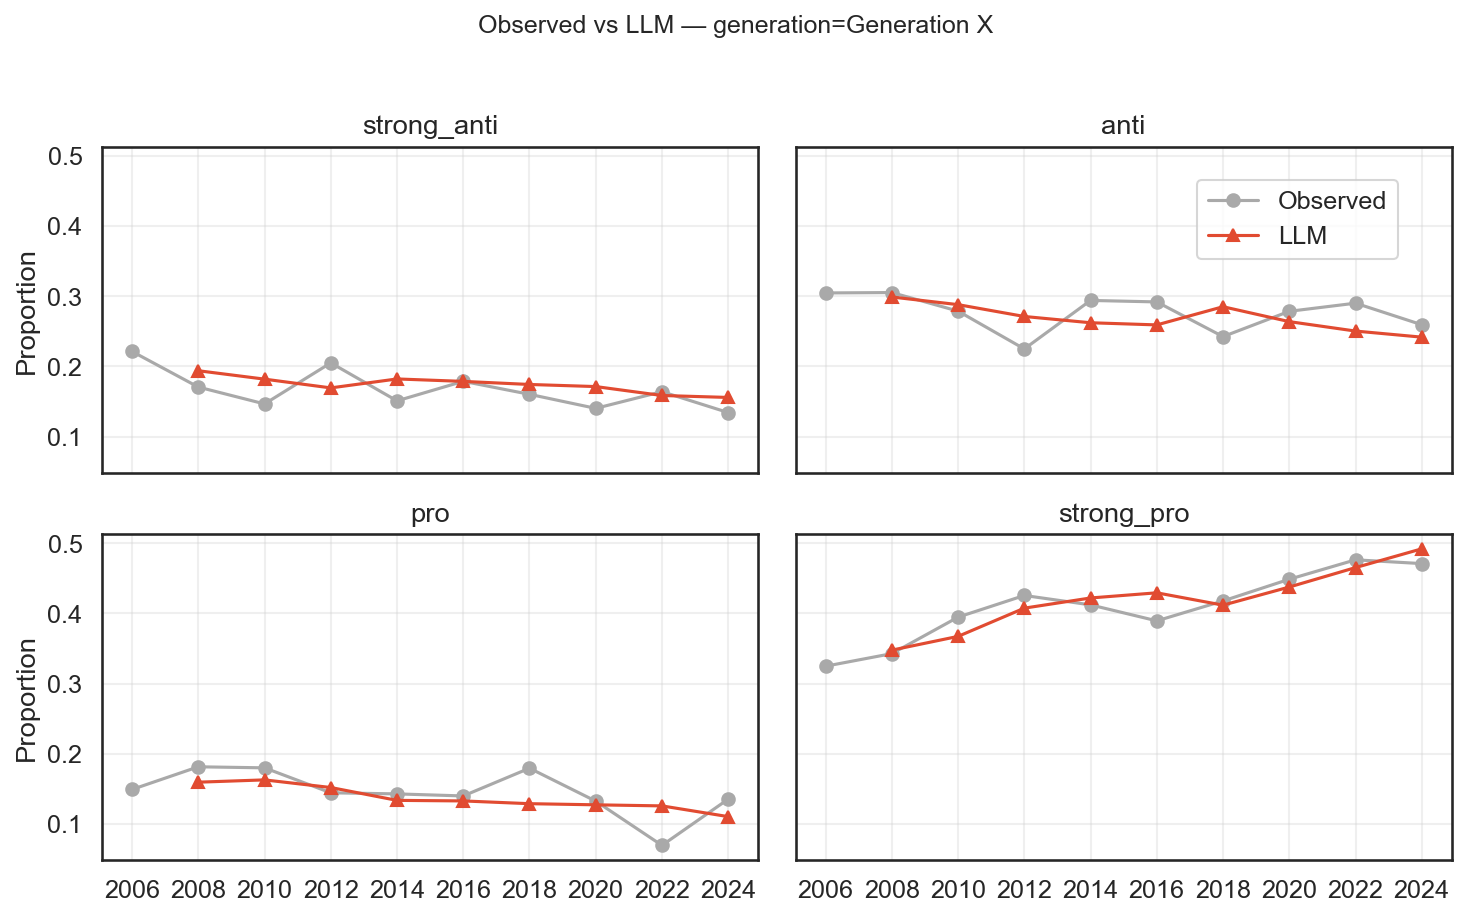

In [56]:
g = ('Generation X',)
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g1, p_hat_AR_g1, p_hat_MC_g1, bt=df_pred_g1, llm_series=("hat",))

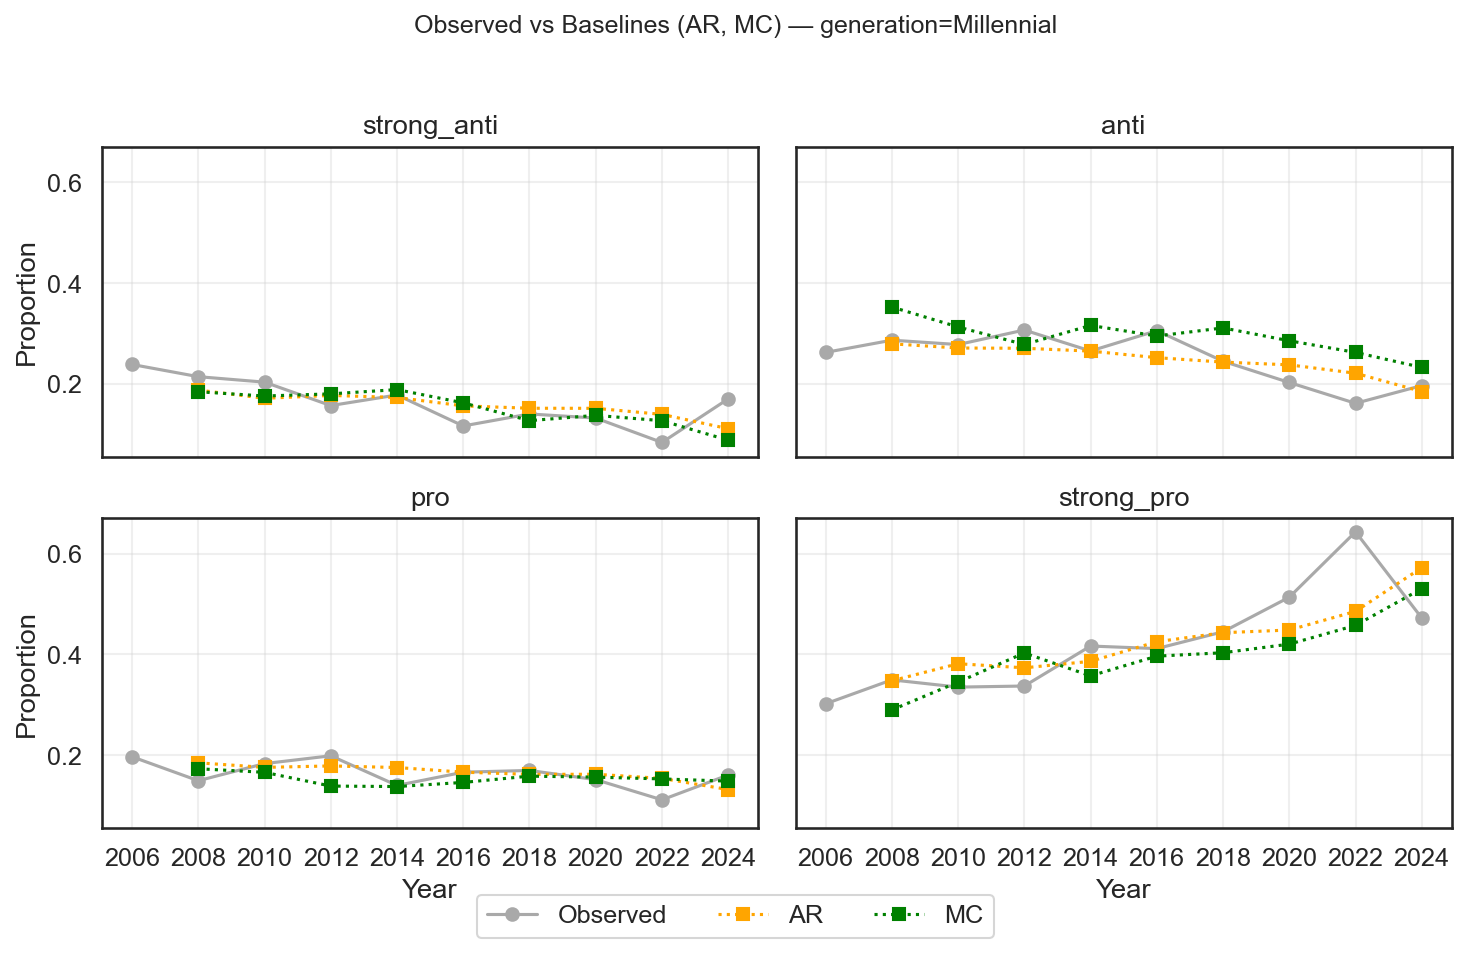

In [685]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g1, p_hat_AR_g1, p_hat_MC_g1, bt=df_pred_g1, llm_series=("hat",))

In [686]:
# Calculate weighted means and standard errors for G1
df_cs_abo.groupby(['generation']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False).head(10)

,generation,wtssps_mean,wtssps_se
2,Generation Z,1.488945,0.072510
3,Millennial,1.138935,0.016572
4,Silent Generation,0.906270,0.014591
1,Generation X,0.978666,0.012092
0,Baby Boomer,0.906313,0.009878


In [687]:
# Compare JSD
bt_abo_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g1.csv")

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# bt_abo_g1['generation'] = bt_abo_g1['generation'].map(gen_map)

bt_abo_g1.head()

,year_t,year_t1,generation,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,0.002195,0.002800,0.001721,0.030900
1,2008,2010,Generation X,0.001451,0.001850,0.001188,0.024388
2,2008,2010,Millennial,0.000728,0.001194,0.000637,0.018293
3,2008,2010,Silent Generation,0.006370,0.012754,0.002412,0.053817
4,2010,2012,Baby Boomer,0.000918,0.000847,0.001008,0.019690


In [688]:
# Convert bench to long format
bench_abo_g1_long = pd.melt(bench, id_vars=GROUP_COLS_1 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'MLAR', 'JSD_MC': 'MTM'}
bench_abo_g1_long['model'] = bench_abo_g1_long['model'].map(model_map)

# Prepare the data for plotting
bt_abo_g1['model'] = 'LLM'
bt_abo_g1 = bt_abo_g1.rename(columns={'JSD_hat':'jsd'})
combined_abo_g1 = pd.concat([bench_abo_g1_long, bt_abo_g1[['generation','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_abo_g1.head()

,generation,year_t,year_t1,model,jsd
0,Baby Boomer,2006,2008,MLAR,0.000808
1,Baby Boomer,2008,2010,MLAR,0.000891
2,Baby Boomer,2010,2012,MLAR,0.000063
3,Baby Boomer,2012,2014,MLAR,0.000534
4,Baby Boomer,2014,2016,MLAR,0.000977


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/937476771.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


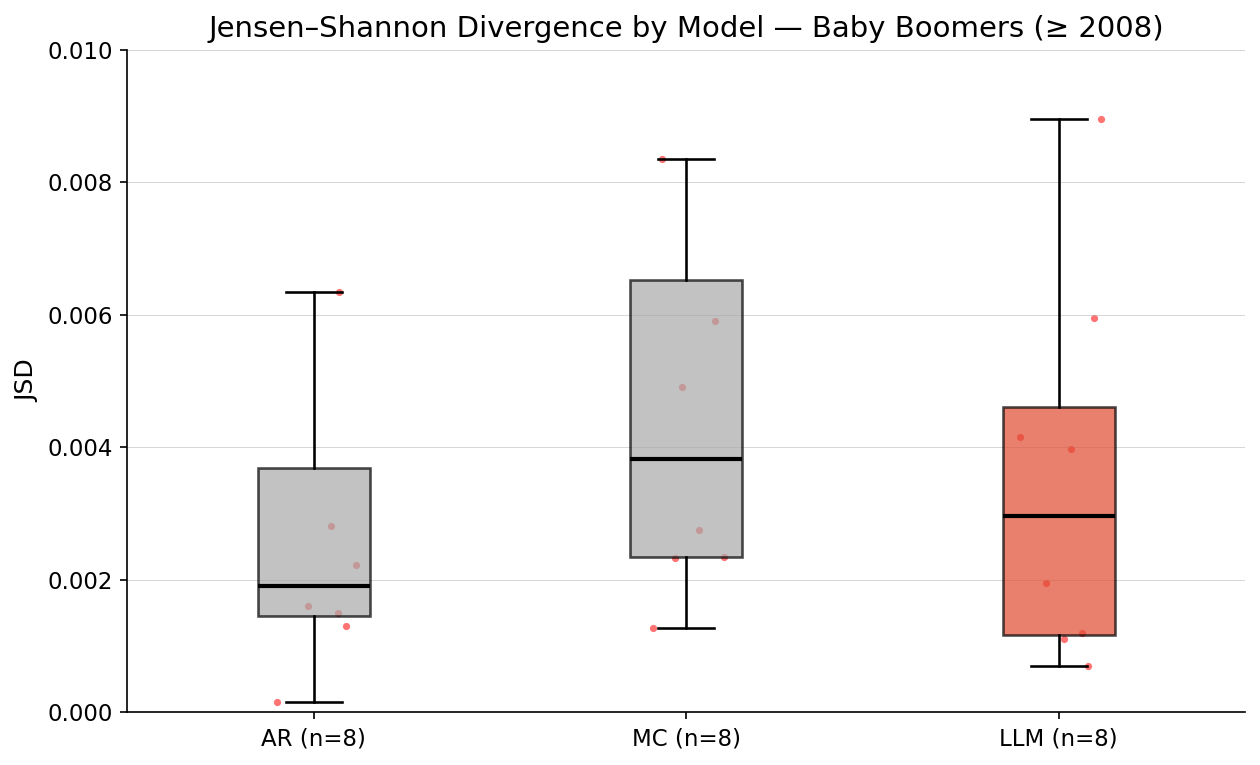

In [200]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g1[(combined_g1['generation'] == 'Millennial') & (combined_g1['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.01)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1178246954.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


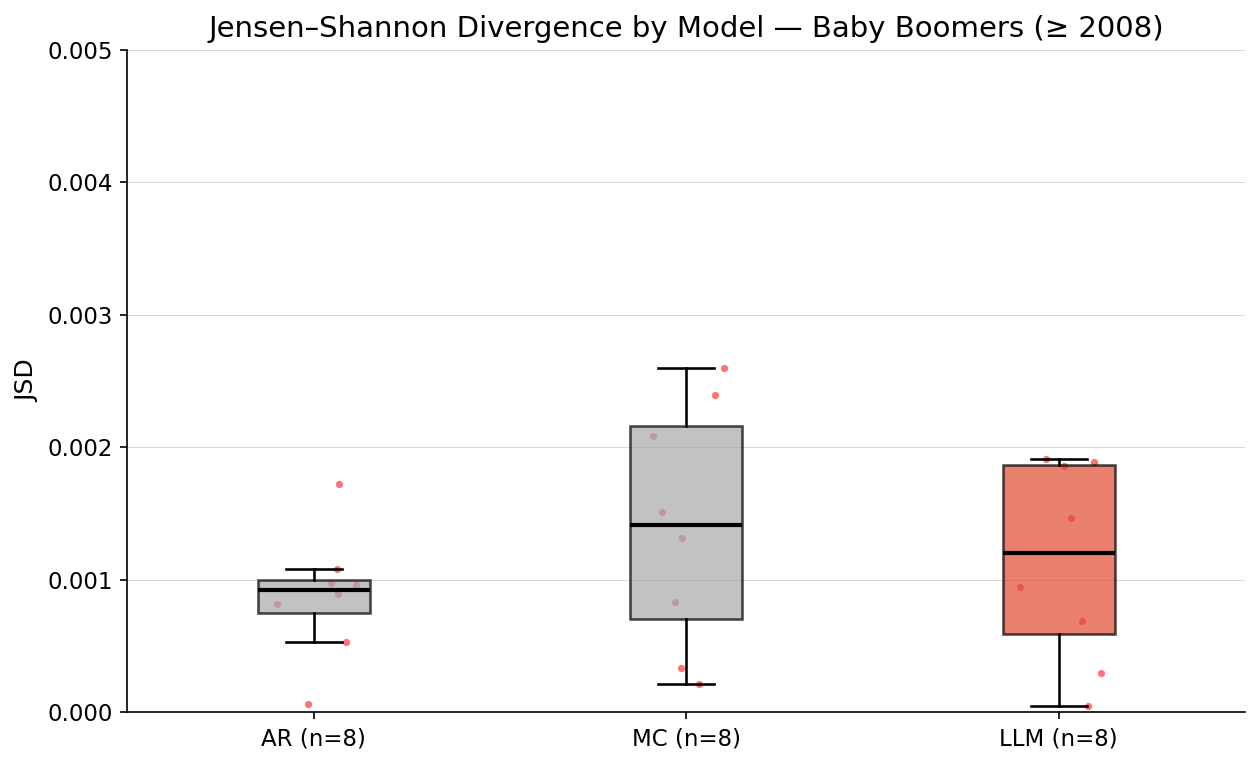

In [201]:
# Polished Matplotlib box plot for JSD (Baby Boomers), no seaborn

# --- 1) Filter & order
df = combined_g1[(combined_g1['generation'] == 'Baby Boomer') & (combined_g1['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.005)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


## Abortion, Group 2

In [57]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 11))

In [203]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_2
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g2 = {}
effN_cs_g2 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_2):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs_g2[(g_vals, y)] = p
        effN_cs_g2[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C_g2 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g2 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g2 in df_pl_abo.groupby("yearid"):
    df_id_g2 = df_id_g2.sort_values("year")
    # collapse duplicates per year if any
    df_id_g2 = df_id_g2.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g2["year"].values.tolist()
    atts  = df_id_g2["abortion_att4"].values.tolist()
    wgts  = df_id_g2["w"].values.astype(float).tolist()
    gens  = df_id_g2["generation"].values.tolist()
    gend  = df_id_g2["gender"].values.tolist()
    # race  = df_id_g2["race"].values.tolist()
    # edu = df_id_g2["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0])
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g2[(g,t,Δ)][ai, aj] += w
        Nfrom_g2[(g,t,Δ)][ai] += w

In [204]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g2 = cs_ar_fit_and_forecast(p_cs_g2, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g2 = panel_markov_forecast(p_cs_g2, C_g2, Nfrom_g2, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g2.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_2, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g2[(g, y)]
        if (g, y) in p_hat_AR_g2:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g2[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g2:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g2[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,gender,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,2006,2008,0.000934,0.000270
1,Baby Boomer,Female,2008,2010,0.000721,0.002306
2,Baby Boomer,Female,2010,2012,0.000311,0.001621
3,Baby Boomer,Female,2012,2014,0.000064,0.007359
4,Baby Boomer,Female,2014,2016,0.000500,0.001613


In [212]:
# Load our predicted values (p-hat)
df_pred_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g2.csv")

# Convert year 2021 to 2020
df_pred_g2.loc[df_pred_g2['year'] == 2021, 'year'] = 2020
df_pred_g2.loc[df_pred_g2['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g2['year_t'] = df_pred_g2['year_prev']
df_pred_g2['year_t1'] = df_pred_g2['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g2['generation'] = df_pred_g2['generation'].map(gen_map)

df_pred_g2.head(2)

,generation,gender,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,p_trans_strong_anti,p_trans_anti,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,2006,2008,0.214584,0.279195,0.113099,0.393122,0.205844,0.268427,...,0.213560,0.262077,0.146479,0.377884,0.001401,0.024997,0.000679,0.005414,2006,2008
1,Baby Boomer,Female,2008,2010,0.213560,0.262077,0.146479,0.377884,0.212648,0.274997,...,0.245294,0.225467,0.148570,0.380669,0.003524,0.041233,0.002237,0.006411,2008,2010


In [213]:
df_pred_g2['year_prev'].value_counts()

year_prev
2020    15
2022    14
2016    12
2018    12
2006    10
2014    10
2010    10
2012     9
2008     9
Name: count, dtype: int64

In [214]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_2):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [224]:
# Calculate weighted means and standard errors for G2
df_cs_abo.groupby(['generation', 'gender']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False)

,generation,gender,wtssps_mean,wtssps_se
7,Generation Z,Other,1.247082,0.471096
6,Generation Z,Male,1.592685,0.111065
5,Generation Z,Female,1.393661,0.095487
4,Generation X,Other,0.752495,0.043245
9,Millennial,Male,1.261334,0.025228
12,Silent Generation,Male,1.015371,0.025051
8,Millennial,Female,1.039779,0.021664
3,Generation X,Male,1.041233,0.018505
11,Silent Generation,Female,0.825508,0.016949
2,Generation X,Female,0.927241,0.015863


In [216]:
df_pred_g2['generation'].value_counts()

generation
Generation X         19
Baby Boomer          18
Millennial           18
Silent Generation    18
Generation Z         10
Name: count, dtype: int64

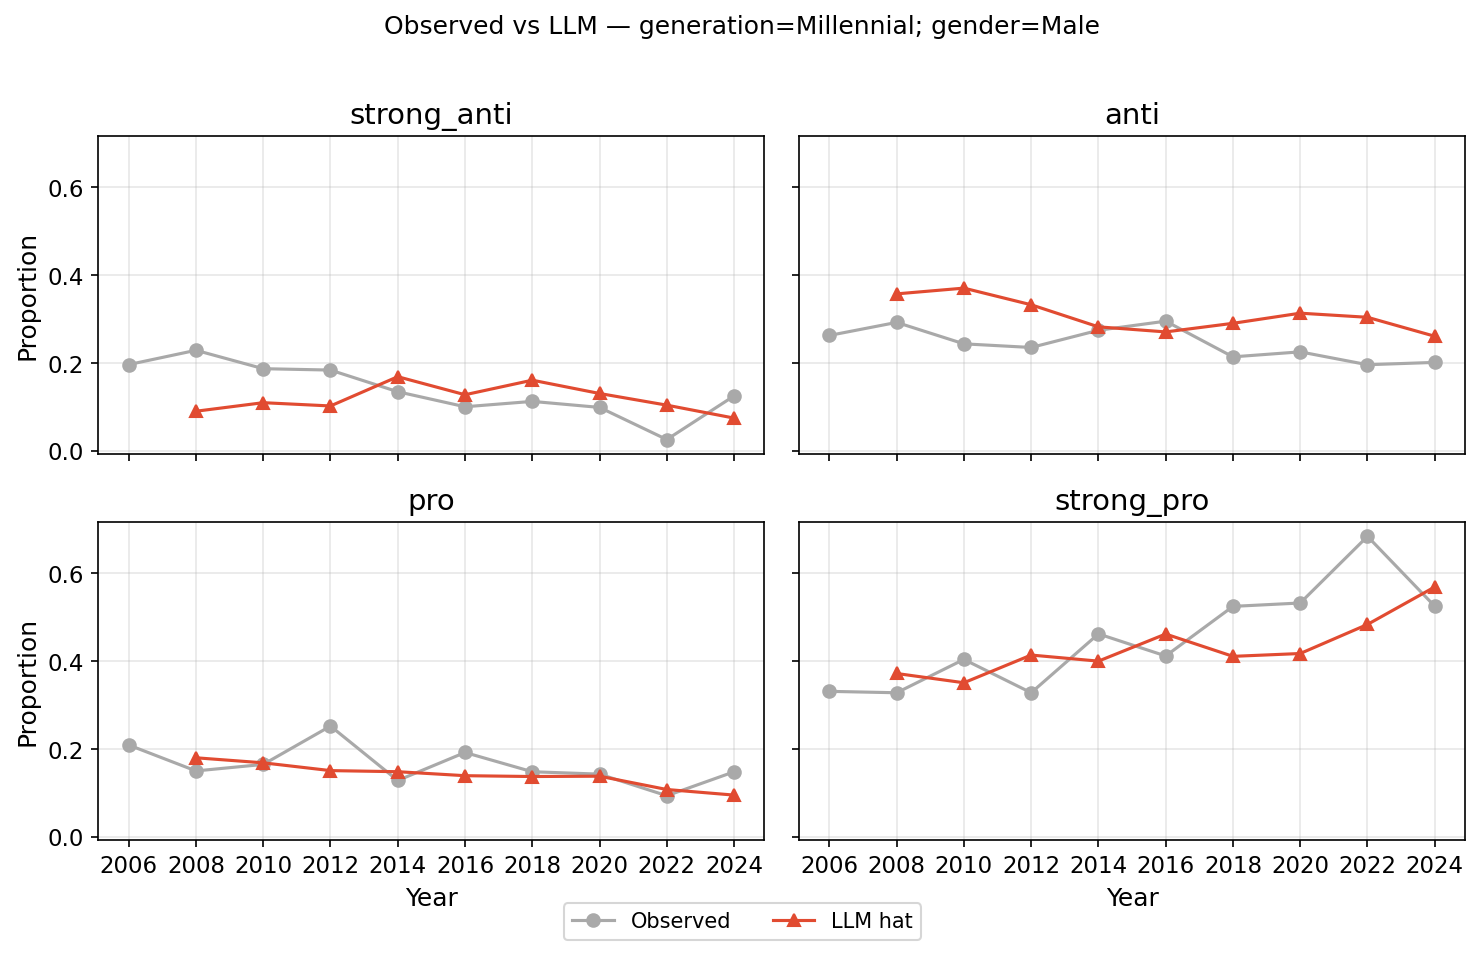

In [227]:
g = ('Millennial', "Male")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g2, p_hat_AR_g2, p_hat_MC_g2, bt=df_pred_g2, llm_series=("hat",))

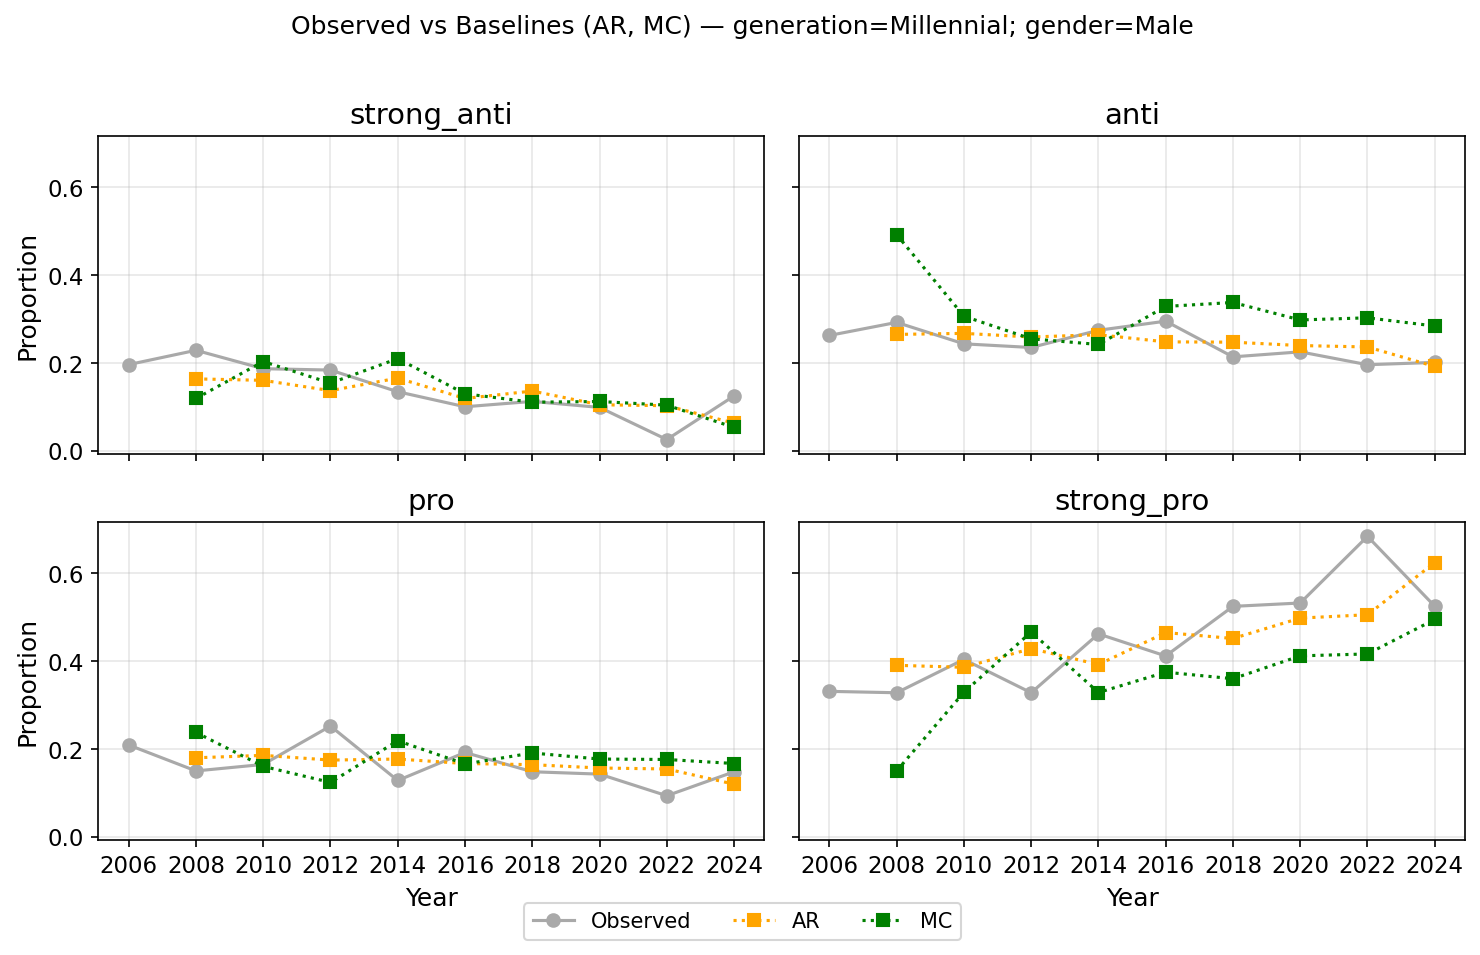

In [228]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g2, p_hat_AR_g2, p_hat_MC_g2, bt=df_pred_g2, llm_series=("hat",))

In [229]:
# Compare JSD
bt_abo_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g2.csv")

#gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
#bt_abo_g2['generation'] = bt_abo_g2['generation'].map(gen_map)

bt_abo_g2.head()

,year_t,year_t1,generation,gender,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,Female,0.003524,0.002237,0.006411,0.041233
1,2008,2010,Baby Boomer,Male,0.001155,0.003486,0.001499,0.022369
2,2008,2010,Generation X,Female,0.000633,0.001773,0.003723,0.015935
3,2008,2010,Generation X,Male,0.004022,0.002575,0.007033,0.039884
4,2008,2010,Millennial,Female,0.001290,0.005091,0.000442,0.025539


In [230]:
bench.head()

,generation,gender,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,2006,2008,0.000934,0.000270
1,Baby Boomer,Female,2008,2010,0.000721,0.002306
2,Baby Boomer,Female,2010,2012,0.000311,0.001621
3,Baby Boomer,Female,2012,2014,0.000064,0.007359
4,Baby Boomer,Female,2014,2016,0.000500,0.001613


In [231]:
# Convert bench to long format
bench_long = pd.melt(bench, id_vars=GROUP_COLS_2 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'AR', 'JSD_MC': 'MC'}
bench_long['model'] = bench_long['model'].map(model_map)

# Prepare the data for plotting
bt_abo_g2['model'] = 'LLM'
bt_abo_g2 = bt_abo_g2.rename(columns={'JSD_hat':'jsd'})
combined_g2 = pd.concat([bench_long, bt_abo_g2[['generation','gender','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_g2.head()

,generation,gender,year_t,year_t1,model,jsd
0,Baby Boomer,Female,2006,2008,AR,0.000934
1,Baby Boomer,Female,2008,2010,AR,0.000721
2,Baby Boomer,Female,2010,2012,AR,0.000311
3,Baby Boomer,Female,2012,2014,AR,0.000064
4,Baby Boomer,Female,2014,2016,AR,0.000500


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3316923523.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


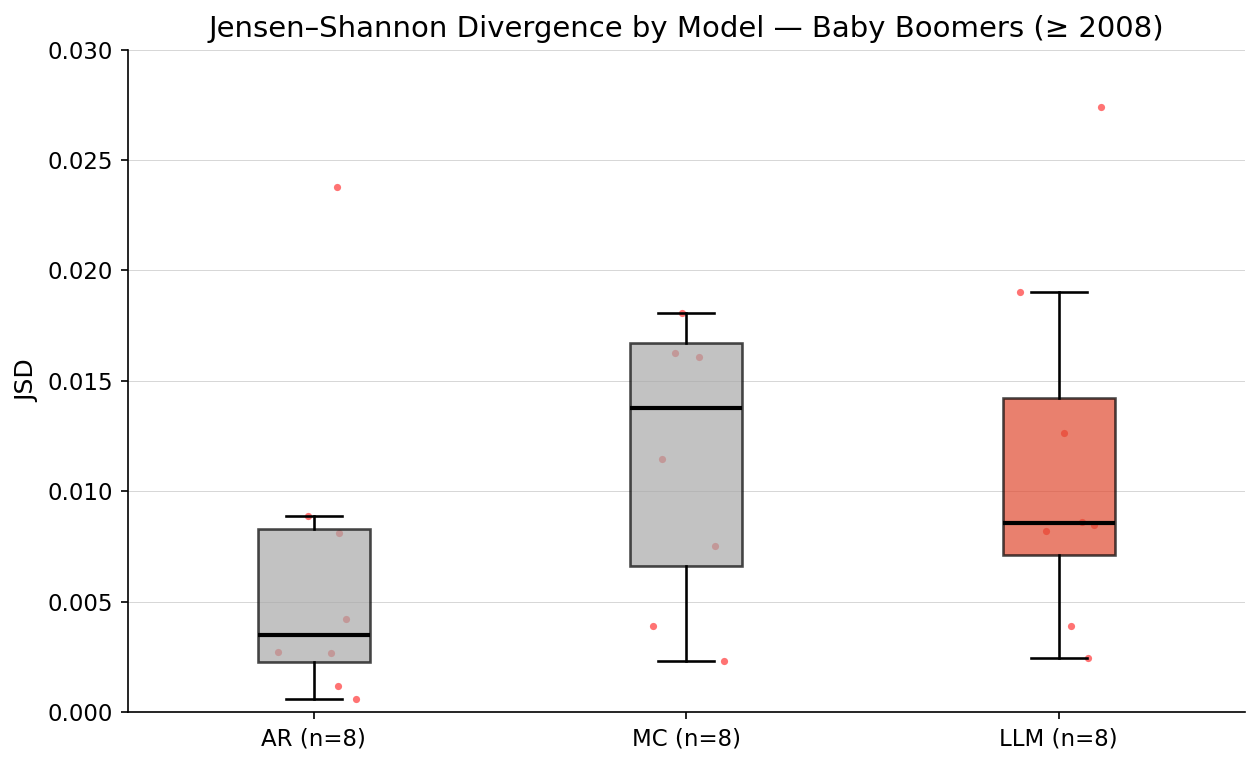

In [235]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g2[(combined_g2['generation'] == 'Millennial') & ((combined_g2['gender'] == 'Male')) & (combined_g2['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Millennial, Male (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.03)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2608336816.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


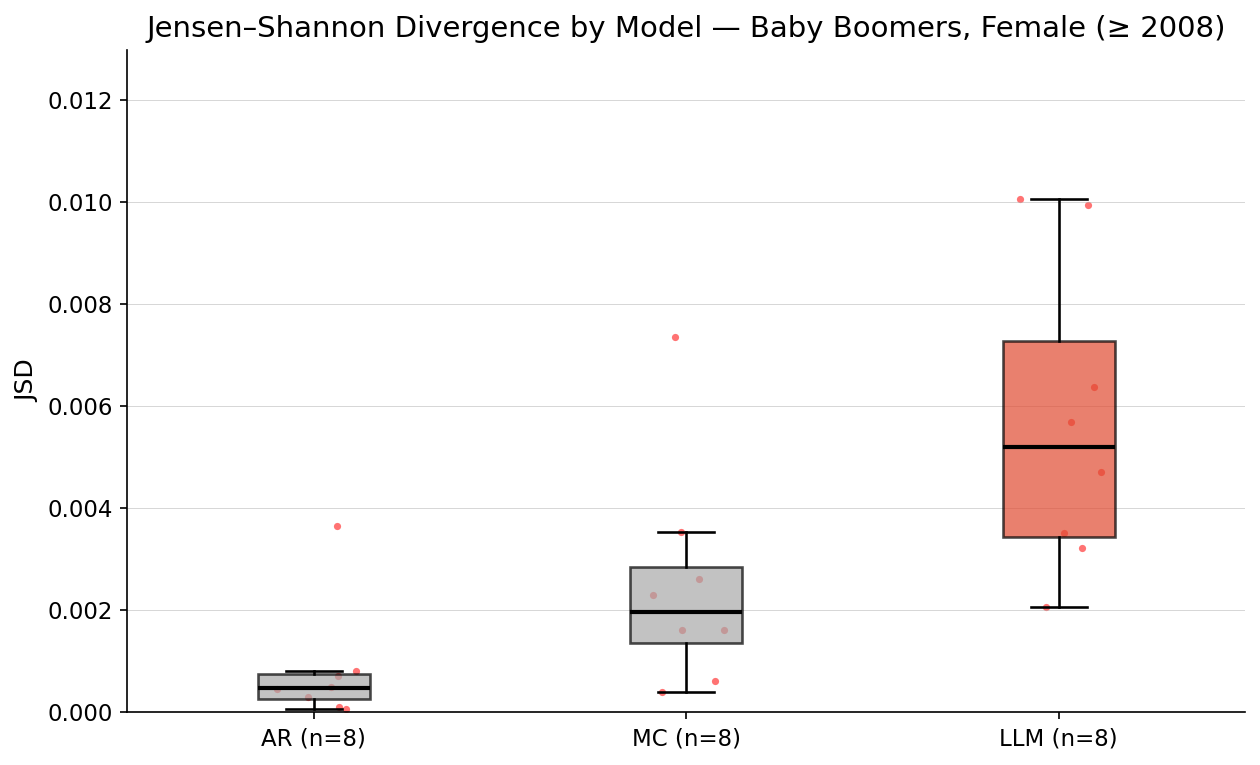

In [237]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g2[(combined_g2['generation'] == 'Baby Boomer') & ((combined_g2['gender'] == 'Female')) & (combined_g2['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers, Female (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.013)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

## Homosexuality, Group 4

In [58]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 11))

In [59]:
# Find p_cs and Nfrom
cs = df_cs_homosex.copy()
# Map to 4 bins if numeric:
cs = cs[cs["homosex"].isin(HOMOSEX4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_4
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=HOMOSEX4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in HOMOSEX4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g4 = {}
effN_cs_g4 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_4):
        p = weighted_probs(df_g["homosex"].tolist(), df_g["wt"].tolist(), HOMOSEX4)
        if p is None:
            continue
        p_cs_g4[(g_vals, y)] = p
        effN_cs_g4[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return HOMOSEX2ID.get(cat, None)

C_g3 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g4 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_homosex["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g4 in df_pl_homosex.groupby("yearid"):
    df_id_g4 = df_id_g4.sort_values("year")
    # collapse duplicates per year if any
    df_id_g4 = df_id_g4.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g4["year"].values.tolist()
    atts  = df_id_g4["homosex"].values.tolist()
    wgts  = df_id_g4["w"].values.astype(float).tolist()
    gens  = df_id_g4["generation"].values.tolist()
    gend  = df_id_g4["gender"].values.tolist()
    race  = df_id_g4["race"].values.tolist()
    edu = df_id_g4["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1 and len(set(race))==1 and len(set(edu))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0],race[0],edu[0])
    
    # Homosex (K=4)
    K = len(HOMOSEX4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g4[(g,t,Δ)][ai, aj] += w
        Nfrom_g4[(g,t,Δ)][ai] += w

In [60]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g4 = cs_ar_fit_and_forecast(p_cs_g4, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g4 = panel_markov_forecast(p_cs_g4, C_g4, Nfrom_g4, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g4.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_4, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g4[(g, y)]
        if (g, y) in p_hat_AR_g4:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g4[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g4:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g4[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()

,generation,gender,race,edu_level,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.164710,0.172420
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.040092,0.064033
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.000392,0.092826
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.035780,0.021709
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.313557,0.043923


In [61]:
# Load our predicted values (p-hat)
df_pred_g4 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_homosex_g4.csv")

# Convert year 2021 to 2020
df_pred_g4.loc[df_pred_g4['year'] == 2021, 'year'] = 2020
df_pred_g4.loc[df_pred_g4['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g4['year_t'] = df_pred_g4['year_prev']
df_pred_g4['year_t1'] = df_pred_g4['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g4['generation'] = df_pred_g4['generation'].map(gen_map)

df_pred_g4.head(2)

,generation,gender,race,edu_level,year_prev,year,p_prev_always_wrong,p_prev_almost_always_wrong,p_prev_sometimes_wrong,p_prev_not_wrong_at_all,...,p_obs_always_wrong,p_obs_almost_always_wrong,p_obs_sometimes_wrong,p_obs_not_wrong_at_all,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.759120,0.146465,0.028796,0.065620,...,0.516102,0.000000,0.0,0.483898,0.044475,0.105133,0.124352,0.000723,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.516102,0.000000,0.000000,0.483898,...,0.667900,0.123614,0.0,0.208486,0.040004,0.122396,0.029045,0.077797,2008,2010


In [62]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = HOMOSEX4

def get_group_cols(group=GROUP_COLS_4):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        # if i // 2 == 1:
        #     ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="upper right", ncol=1, bbox_to_anchor=(0.95, 0.85))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        # if i // 2 == 1:
        #     ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [63]:
# Calculate weighted means and standard errors for G2
temp = df_cs_homosex.groupby(['generation', 'gender','race','edu_level']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    count=('wtssps', 'size')
).reset_index().sort_values('wtssps_se', ascending=False)

temp[temp['count'] >= 100].tail(100)

,generation,gender,race,edu_level,wtssps_mean,wtssps_se,count
57,Generation Z,Male,White,Less or equal to high school,1.916129,0.165658,153
49,Generation Z,Female,White,Less or equal to high school,1.583535,0.114982,140
82,Silent Generation,Female,Black,Less or equal to high school,0.875872,0.106017,101
66,Millennial,Female,Other,Less or equal to high school,1.323690,0.090118,199
75,Millennial,Male,Other,Less or equal to high school,1.530233,0.077155,174
5,Baby Boomer,Female,Other,Less or equal to high school,0.853245,0.065770,109
72,Millennial,Male,Black,Less or equal to high school,1.111590,0.065652,186
25,Generation X,Female,Other,Less or equal to high school,1.066058,0.063006,183
34,Generation X,Male,Other,Less or equal to high school,1.154869,0.062349,197
96,Silent Generation,Male,White,Graduate Degree,0.875055,0.061136,133


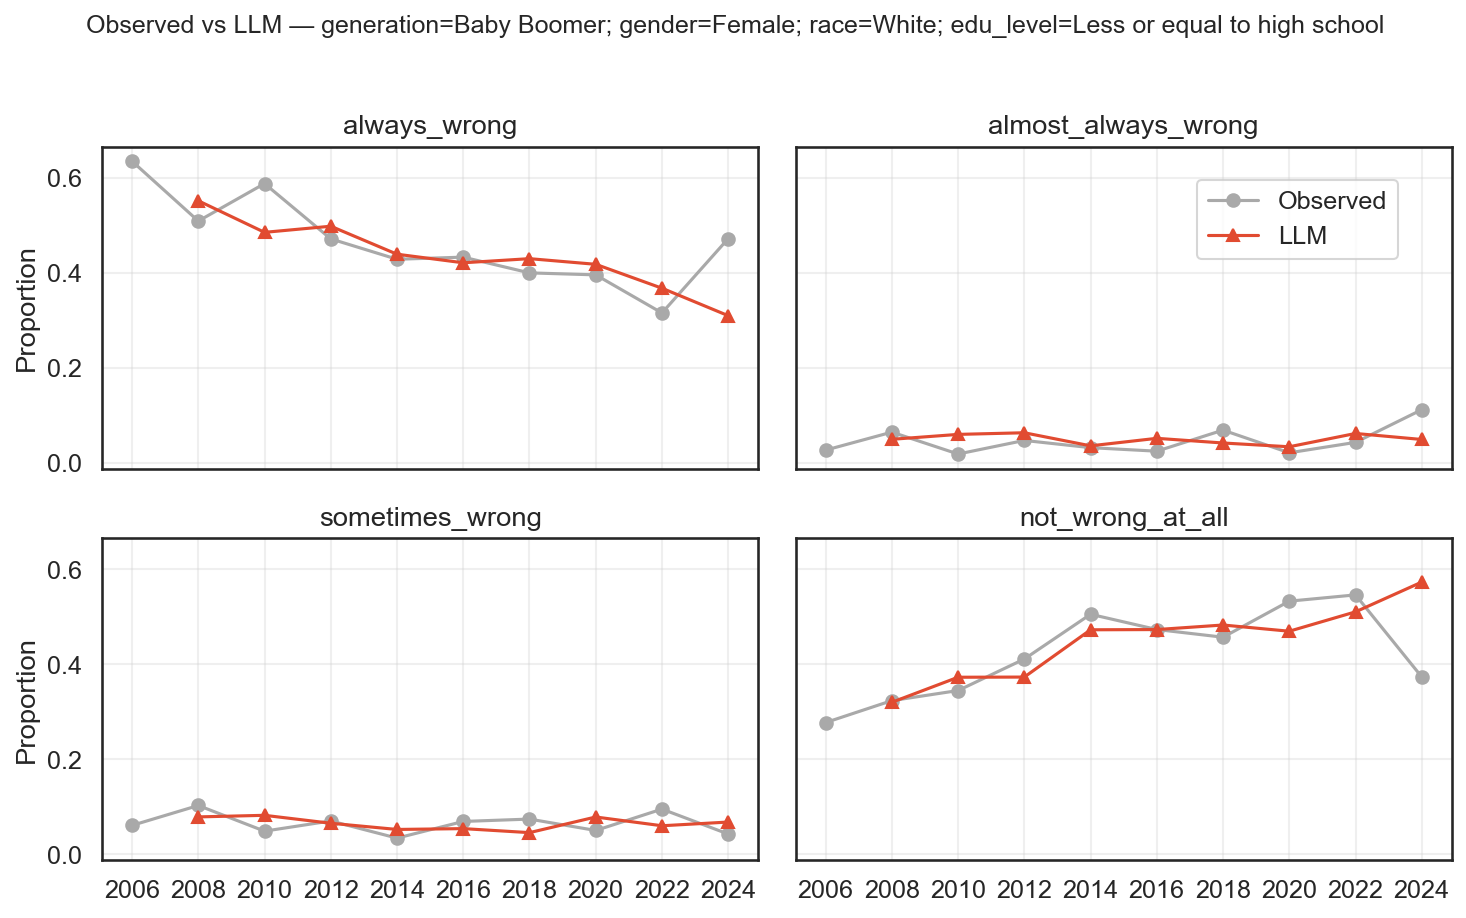

In [65]:
g = ('Baby Boomer', "Female", "White",'Less or equal to high school')
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

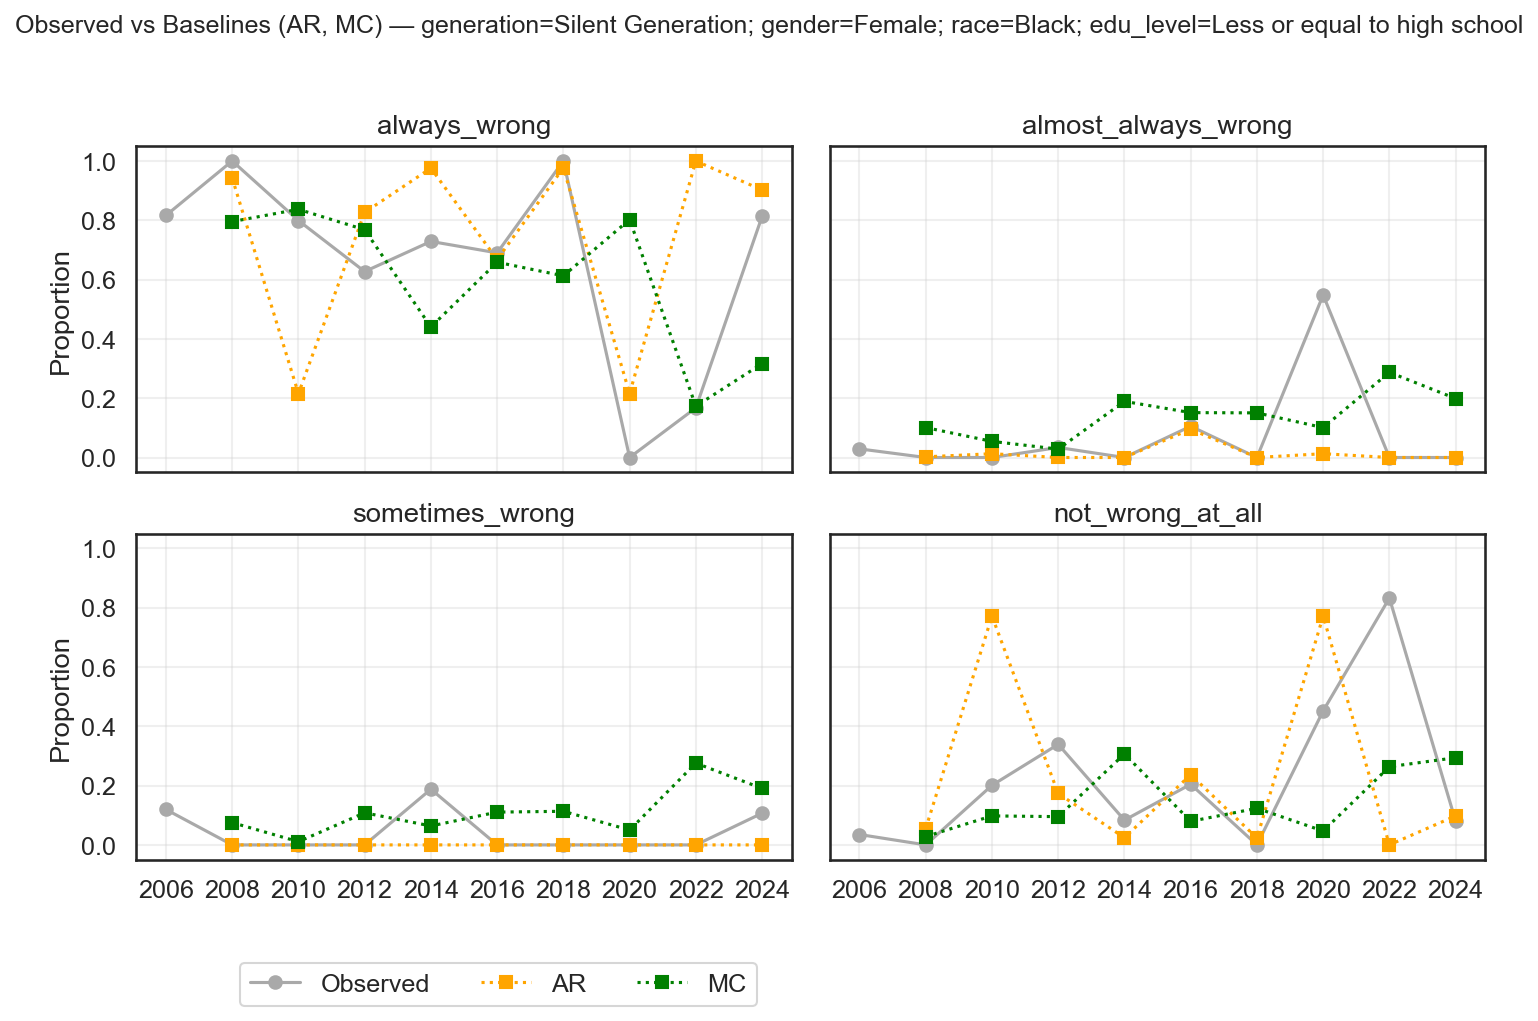

In [696]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g4, p_hat_AR_g4, p_hat_MC_g4, bt=df_pred_g4, llm_series=("hat",))

In [697]:
# Compare JSD
bt_homosex_g4 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g4.csv")

#gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
#bt_homosex_g2['generation'] = bt_homosex_g2['generation'].map(gen_map)

bt_homosex_g4.head()

,year_t,year_t1,generation,gender,race,edu_level,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,Female,Black,Associate or Bachelor's Degree,0.040004,0.029045,0.077797,0.122396
1,2008,2010,Baby Boomer,Female,Black,Graduate Degree,0.151914,0.235113,0.081418,0.225619
2,2008,2010,Baby Boomer,Female,Black,Less or equal to high school,0.016658,0.015541,0.025855,0.052071
3,2008,2010,Baby Boomer,Female,Other,Associate or Bachelor's Degree,0.105225,0.119702,0.099069,0.203521
4,2008,2010,Baby Boomer,Female,Other,Graduate Degree,0.543222,0.555801,0.531150,0.596460


In [698]:
# Convert bench to long format
bench_homosex_long = pd.melt(bench, id_vars=GROUP_COLS_4 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'MLAR', 'JSD_MC': 'MTM'}
bench_homosex_long['model'] = bench_homosex_long['model'].map(model_map)

# Prepare the data for plotting
bt_homosex_g4['model'] = 'LLM'
bt_homosex_g4 = bt_homosex_g4.rename(columns={'JSD_hat':'jsd'})
combined_homosex_g4 = pd.concat([bench_homosex_long, bt_homosex_g4[['generation','gender','edu_level','race','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_homosex_g4.head()

,generation,gender,race,edu_level,year_t,year_t1,model,jsd
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,MLAR,0.164710
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,MLAR,0.040092
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,MLAR,0.000392
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,MLAR,0.035780
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,MLAR,0.313557


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2823598697.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


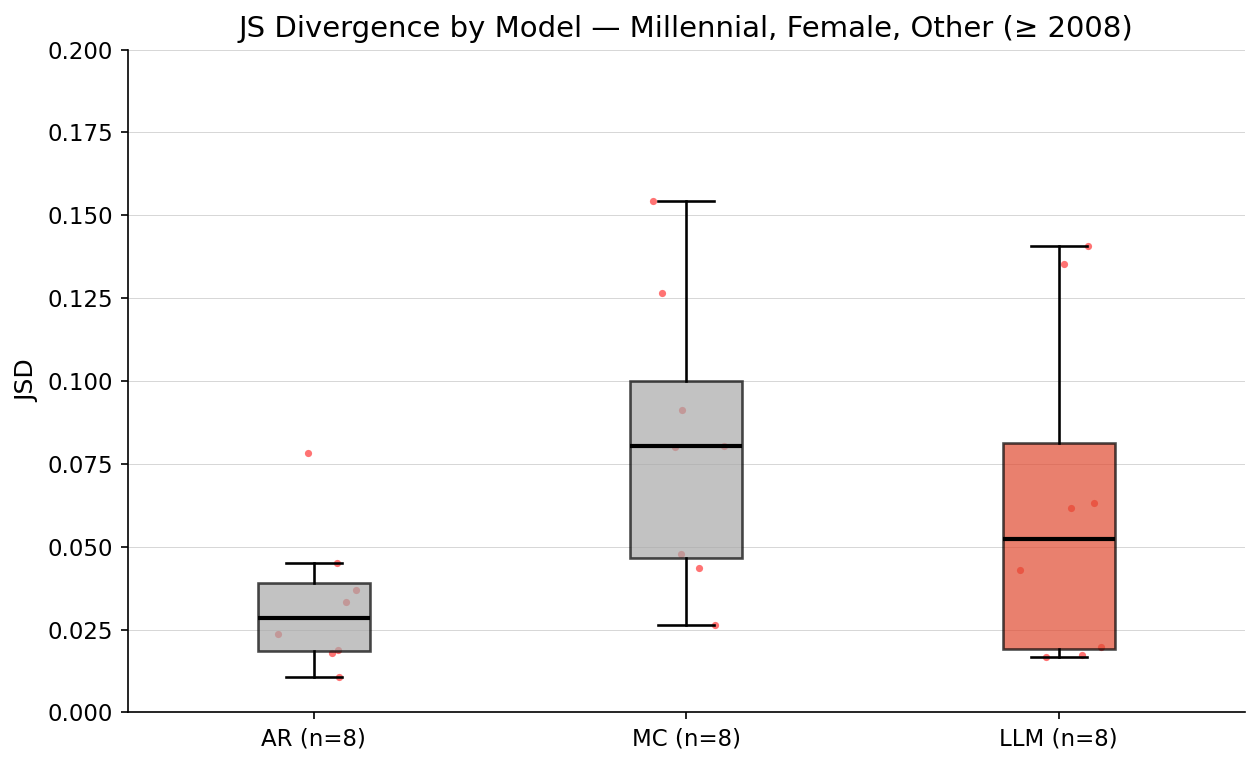

In [404]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g4[(combined_g4['generation'] == 'Millennial') & (combined_g4['gender'] == 'Female') & (combined_g4['race'] == 'Other') & (combined_g4['edu_level'] == 'Less or equal to high school') & (combined_g4['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence by Model — Millennial, Female, Other, Bachelor (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.2)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1760962354.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


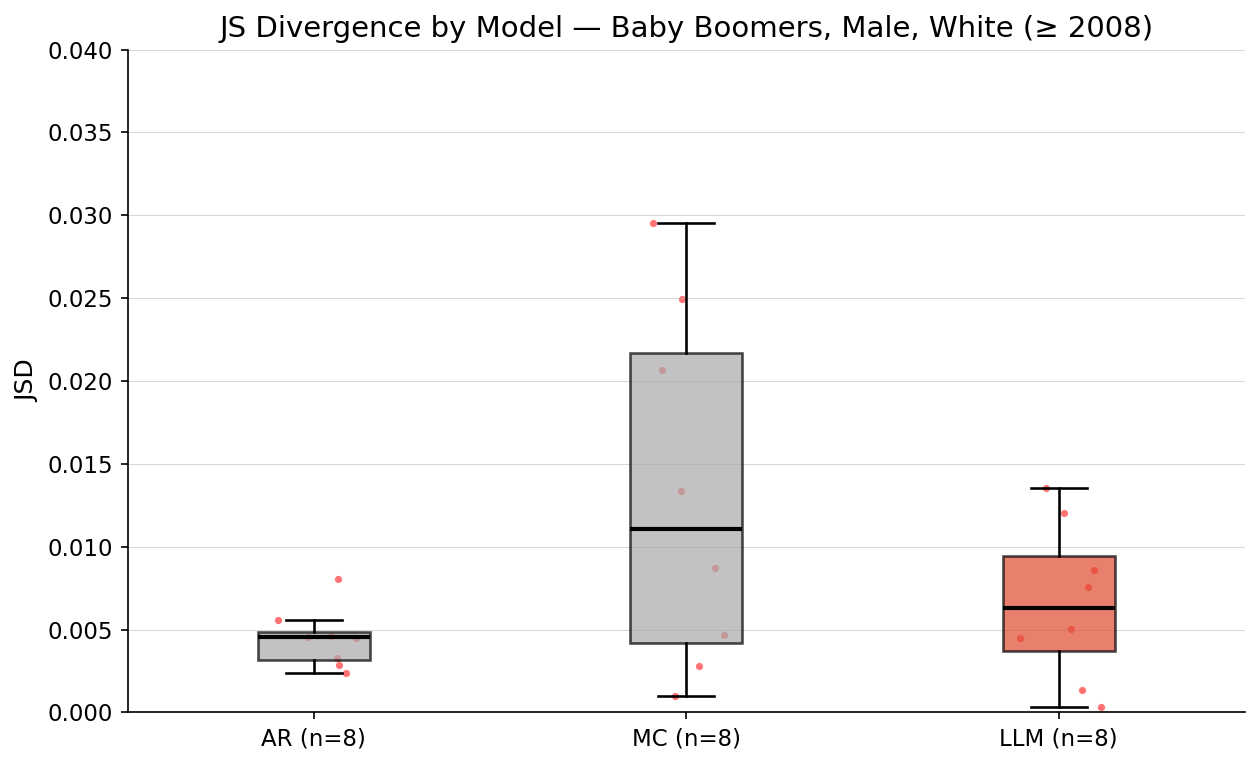

In [407]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g4[(combined_g4['generation'] == 'Baby Boomer') & (combined_g4['gender'] == 'Male') & (combined_g4['race'] == 'White') & (combined_g4['edu_level'] == "Less or equal to high school") & (combined_g4['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence by Model — Baby Boomers, Male, White (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.04)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

## Homosexuality, Group 3

In [367]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 12))

In [368]:
# Find p_cs and Nfrom
cs = df_cs_homosex.copy()
# Map to 4 bins if numeric:
cs = cs[cs["homosex"].isin(HOMOSEX4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_3
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=HOMOSEX4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in HOMOSEX4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g3 = {}
effN_cs_g3 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_3):
        p = weighted_probs(df_g["homosex"].tolist(), df_g["wt"].tolist(), HOMOSEX4)
        if p is None:
            continue
        p_cs_g3[(g_vals, y)] = p
        effN_cs_g3[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return HOMOSEX2ID.get(cat, None)

C_g3 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g3 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_homosex["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g3 in df_pl_homosex.groupby("yearid"):
    df_id_g3 = df_id_g3.sort_values("year")
    # collapse duplicates per year if any
    df_id_g3 = df_id_g3.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g3["year"].values.tolist()
    atts  = df_id_g3["homosex"].values.tolist()
    wgts  = df_id_g3["w"].values.astype(float).tolist()
    gens  = df_id_g3["generation"].values.tolist()
    gend  = df_id_g3["gender"].values.tolist()
    race  = df_id_g3["race"].values.tolist()
    # edu = df_id_g3["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1 and len(set(race))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0],race[0])
    
    # Homosex (K=4)
    K = len(HOMOSEX4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g3[(g,t,Δ)][ai, aj] += w
        Nfrom_g3[(g,t,Δ)][ai] += w

In [370]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g3 = cs_ar_fit_and_forecast(p_cs_g3, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g3 = panel_markov_forecast(p_cs_g3, C_g3, Nfrom_g3, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g3.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_3, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g3[(g, y)]
        if (g, y) in p_hat_AR_g3:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g3[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g3:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g3[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()

,generation,gender,race,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,2006,2008,0.004654,0.080163
1,Baby Boomer,Female,Black,2008,2010,0.000465,0.016913
2,Baby Boomer,Female,Black,2010,2012,0.009038,0.020587
3,Baby Boomer,Female,Black,2012,2014,0.017066,0.005007
4,Baby Boomer,Female,Black,2014,2016,0.033001,0.001199


In [371]:
# Load our predicted values (p-hat)
df_pred_g3 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_homosex_g3.csv")

# Convert year 2021 to 2020
df_pred_g3.loc[df_pred_g3['year'] == 2021, 'year'] = 2020
df_pred_g3.loc[df_pred_g3['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g3['year_t'] = df_pred_g3['year_prev']
df_pred_g3['year_t1'] = df_pred_g3['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g3['generation'] = df_pred_g3['generation'].map(gen_map)

df_pred_g3.head(2)

,generation,gender,race,year_prev,year,p_prev_always_wrong,p_prev_almost_always_wrong,p_prev_sometimes_wrong,p_prev_not_wrong_at_all,p_trans_always_wrong,...,p_obs_always_wrong,p_obs_almost_always_wrong,p_obs_sometimes_wrong,p_obs_not_wrong_at_all,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,2006,2008,0.763865,0.059239,0.026367,0.150529,0.741700,...,0.810416,0.000000,0.0,0.189584,0.019820,0.028809,0.036073,0.004147,2006,2008
1,Baby Boomer,Female,Black,2008,2010,0.810416,0.000000,0.000000,0.189584,0.737125,...,0.744474,0.076411,0.0,0.179115,0.013378,0.028568,0.017302,0.011610,2008,2010


In [373]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = HOMOSEX4

def get_group_cols(group=GROUP_COLS_3):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [389]:
# Calculate weighted means and standard errors for G2
temp = df_cs_homosex.groupby(['generation', 'gender','race']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    count=('wtssps', 'size')
).reset_index().sort_values('wtssps_se', ascending=False)

temp[temp['count'] >= 100].tail(15)

,generation,gender,race,wtssps_mean,wtssps_se,count
1,Baby Boomer,Female,Other,0.845538,0.046674,185
9,Generation X,Female,Other,1.069288,0.046539,305
11,Generation X,Male,Black,0.887283,0.042864,281
3,Baby Boomer,Male,Black,0.792790,0.030968,312
25,Millennial,Female,Black,0.757954,0.029047,446
39,Silent Generation,Male,White,0.998390,0.025827,811
30,Millennial,Male,White,1.207325,0.025626,1273
8,Generation X,Female,Black,0.685304,0.023265,436
0,Baby Boomer,Female,Black,0.689943,0.023113,481
27,Millennial,Female,White,1.032258,0.021977,1416


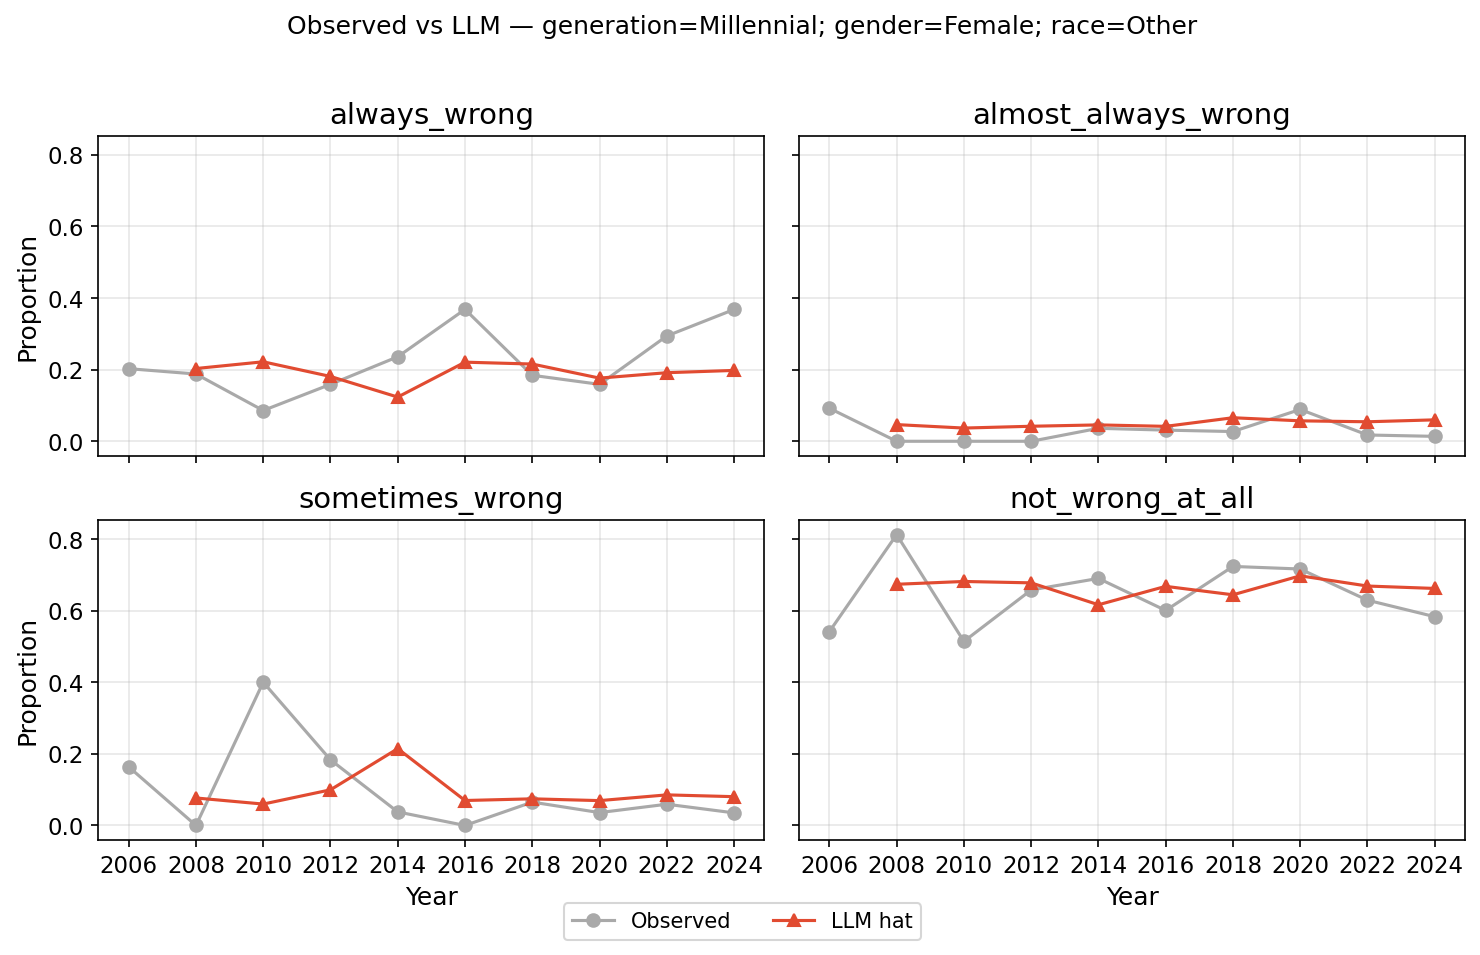

In [380]:
g = ('Millennial', "Female", "Other")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g3, p_hat_AR_g3, p_hat_MC_g3, bt=df_pred_g3, llm_series=("hat",))

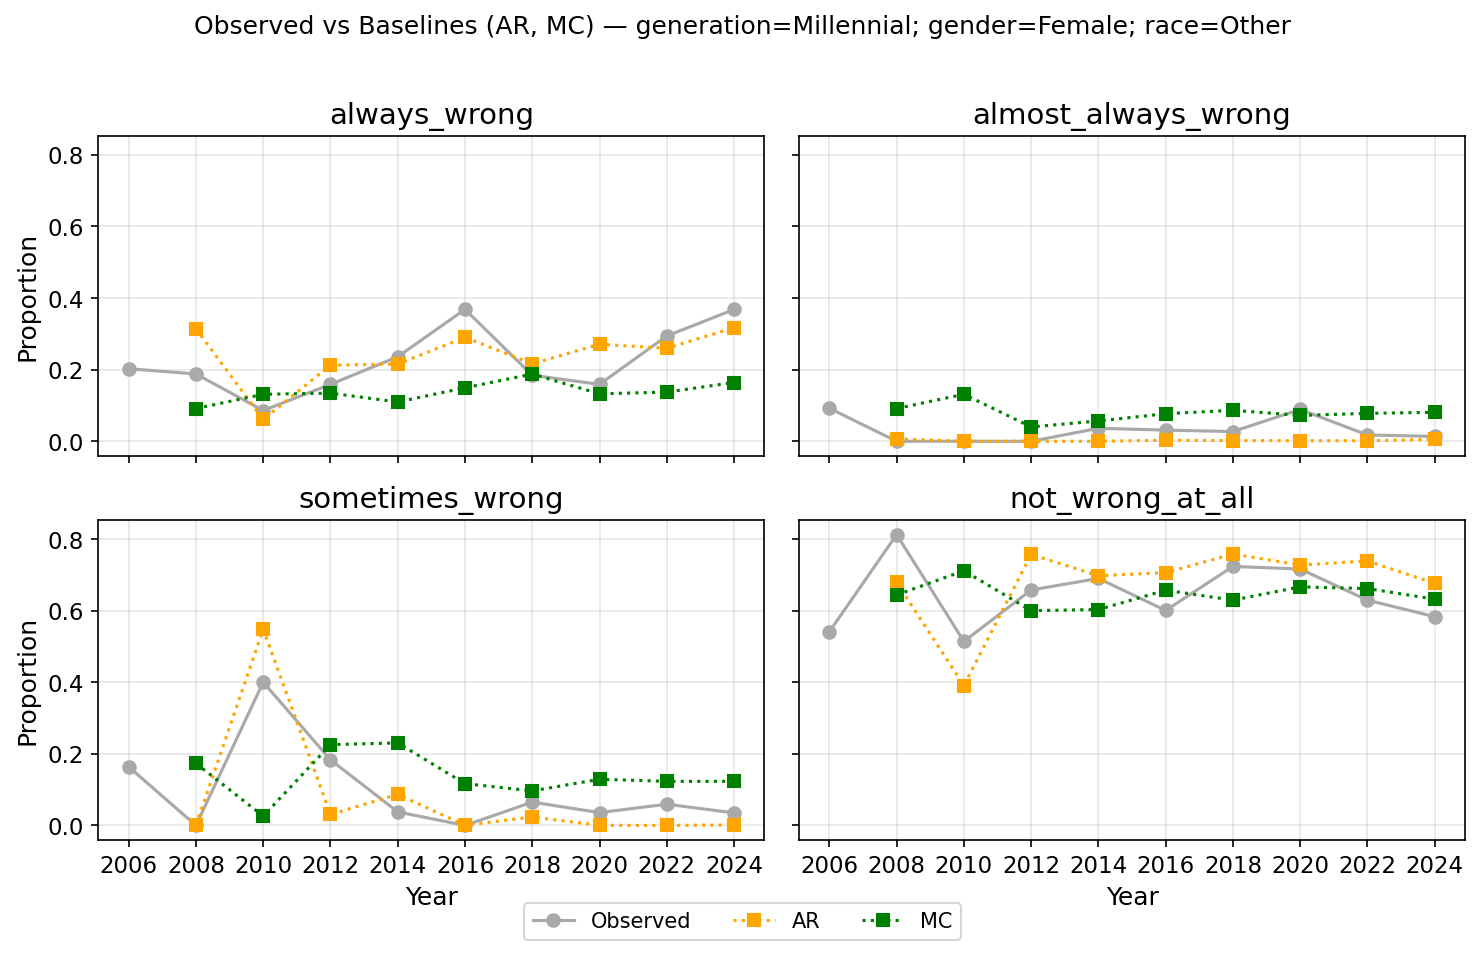

In [381]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g3, p_hat_AR_g3, p_hat_MC_g3, bt=df_pred_g3, llm_series=("hat",))

In [382]:
# Compare JSD
bt_homosex_g3 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g3.csv")

#gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
#bt_homosex_g2['generation'] = bt_homosex_g2['generation'].map(gen_map)

bt_homosex_g3.head()

,year_t,year_t1,generation,gender,race,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,Female,Black,0.013378,0.017302,0.011610,0.028568
1,2008,2010,Baby Boomer,Female,Other,0.106686,0.120340,0.093696,0.182220
2,2008,2010,Baby Boomer,Female,White,0.005671,0.003455,0.009313,0.029440
3,2008,2010,Baby Boomer,Male,Black,0.049038,0.045953,0.053558,0.148777
4,2008,2010,Baby Boomer,Male,Other,0.016678,0.029434,0.005546,0.032243


In [386]:
# Convert bench to long format
bench_long = pd.melt(bench, id_vars=GROUP_COLS_3 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'AR', 'JSD_MC': 'MC'}
bench_long['model'] = bench_long['model'].map(model_map)

# Prepare the data for plotting
bt_homosex_g3['model'] = 'LLM'
bt_homosex_g3 = bt_homosex_g3.rename(columns={'JSD_hat':'jsd'})
combined_g3 = pd.concat([bench_long, bt_homosex_g3[['generation','gender','race','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_g3.head()

,generation,gender,race,year_t,year_t1,model,jsd
0,Baby Boomer,Female,Black,2006,2008,AR,0.004654
1,Baby Boomer,Female,Black,2008,2010,AR,0.000465
2,Baby Boomer,Female,Black,2010,2012,AR,0.009038
3,Baby Boomer,Female,Black,2012,2014,AR,0.017066
4,Baby Boomer,Female,Black,2014,2016,AR,0.033001


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/841022701.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


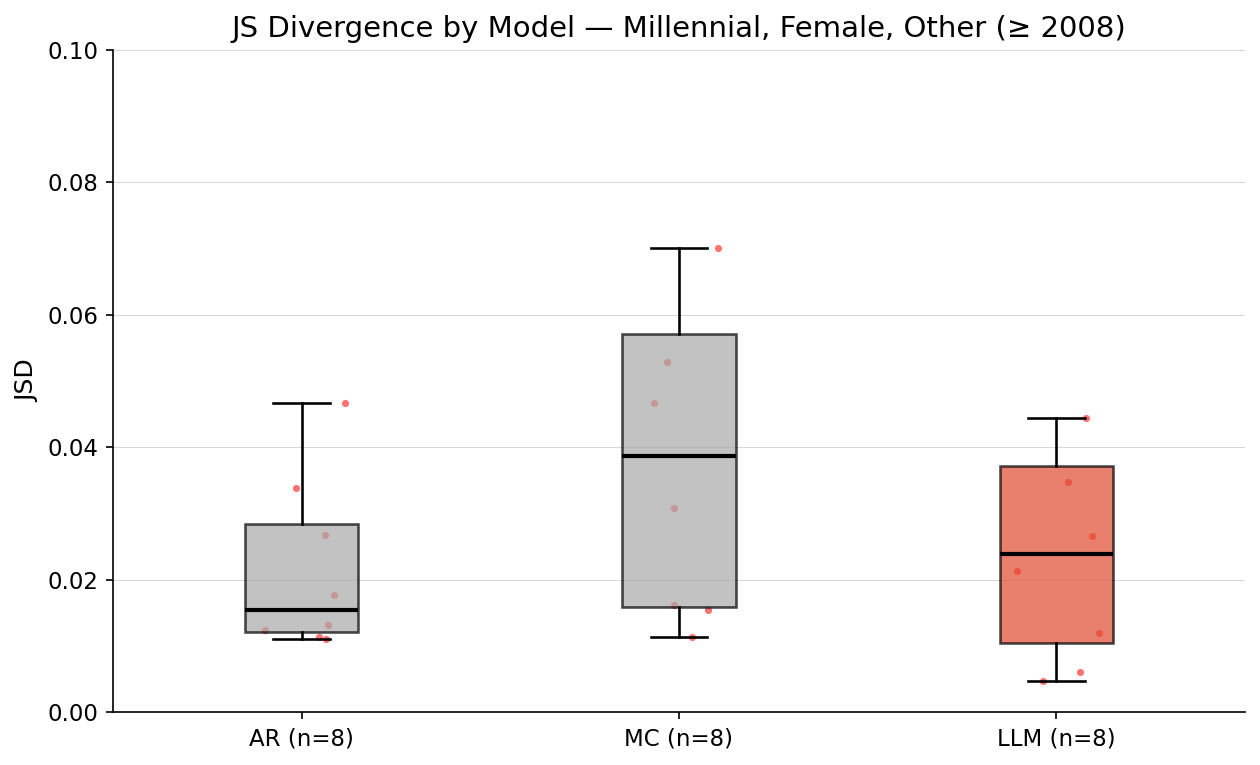

In [388]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g3[(combined_g3['generation'] == 'Millennial') & (combined_g3['gender'] == 'Female') & (combined_g3['race'] == 'Other') & (combined_g3['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence by Model — Millennial, Female, Other (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.1)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2471014222.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


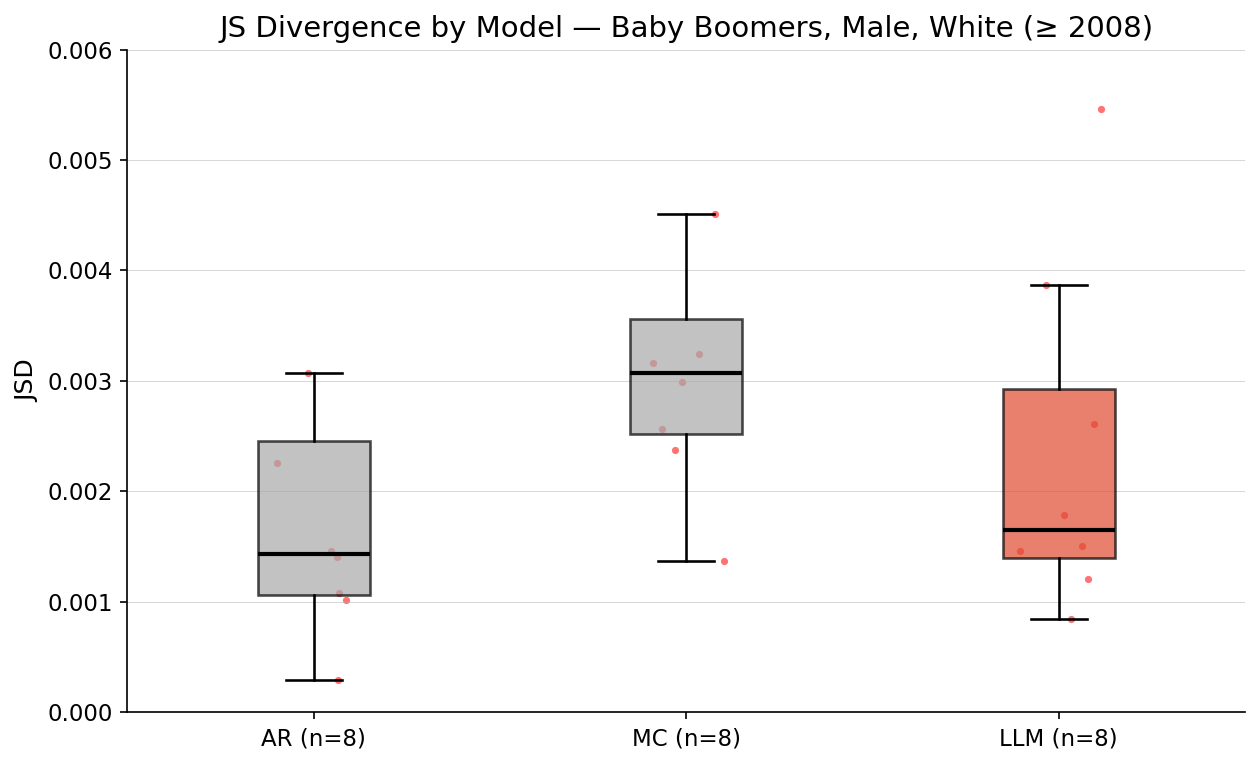

In [390]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g3[(combined_g3['generation'] == 'Baby Boomer') & (combined_g3['gender'] == 'Male') & (combined_g3['race'] == 'White') & (combined_g3['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('JS Divergence by Model — Baby Boomers, Male, White (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.006)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

## Homosexuality, Group 1

In [66]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 12))

In [67]:
# Find p_cs and Nfrom
cs = df_cs_homosex.copy()
# Map to 4 bins if numeric:
cs = cs[cs["homosex"].isin(HOMOSEX4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_1
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=HOMOSEX4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in HOMOSEX4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g1 = {}
effN_cs_g1 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_1):
        p = weighted_probs(df_g["homosex"].tolist(), df_g["wt"].tolist(), HOMOSEX4)
        if p is None:
            continue
        p_cs_g1[(g_vals, y)] = p
        effN_cs_g1[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return HOMOSEX2ID.get(cat, None)

C_g1 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g1 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_homosex["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g1 in df_pl_homosex.groupby("yearid"):
    df_id_g1 = df_id_g1.sort_values("year")
    # collapse duplicates per year if any
    df_id_g1 = df_id_g1.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g1["year"].values.tolist()
    atts  = df_id_g1["homosex"].values.tolist()
    wgts  = df_id_g1["w"].values.astype(float).tolist()
    gens  = df_id_g1["generation"].values.tolist()
    # gend  = df_id_g1["gender"].values.tolist()
    # race  = df_id_g1["race"].values.tolist()
    # edu = df_id_g1["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],)
    
    # Abortion (K=4)
    K = len(HOMOSEX4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g1[(g,t,Δ)][ai, aj] += w
        Nfrom_g1[(g,t,Δ)][ai] += w

In [68]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g1 = cs_ar_fit_and_forecast(p_cs_g1, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g1 = panel_markov_forecast(p_cs_g1, C_g1, Nfrom_g1, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g1.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_1, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g1[(g, y)]
        if (g, y) in p_hat_AR_g1:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g1[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g1:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g1[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,2006,2008,0.003173,0.000976
1,Baby Boomer,2008,2010,0.001211,0.000920
2,Baby Boomer,2010,2012,0.000930,0.001242
3,Baby Boomer,2012,2014,0.000210,0.001333
4,Baby Boomer,2014,2016,0.000269,0.000177


In [69]:
# Load our predicted values (p-hat)
df_pred_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_homosex_g1.csv")

# Convert year 2021 to 2020
df_pred_g1.loc[df_pred_g1['year'] == 2021, 'year'] = 2020
df_pred_g1.loc[df_pred_g1['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g1['year_t'] = df_pred_g1['year_prev']
df_pred_g1['year_t1'] = df_pred_g1['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g1['generation'] = df_pred_g1['generation'].map(gen_map)

df_pred_g1.head(2)

,generation,year_prev,year,p_prev_always_wrong,p_prev_almost_always_wrong,p_prev_sometimes_wrong,p_prev_not_wrong_at_all,p_trans_always_wrong,p_trans_almost_always_wrong,p_trans_sometimes_wrong,...,p_obs_always_wrong,p_obs_almost_always_wrong,p_obs_sometimes_wrong,p_obs_not_wrong_at_all,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,2006,2008,0.564512,0.042995,0.063002,0.329491,0.535949,0.047282,0.065684,...,0.534442,0.032791,0.095342,0.337424,0.001014,0.012541,0.002101,0.000386,2006,2008
1,Baby Boomer,2008,2010,0.534442,0.032791,0.095342,0.337424,0.506798,0.047038,0.075771,...,0.506816,0.028641,0.074538,0.390005,0.001323,0.014819,0.001258,0.001628,2008,2010


In [70]:
df_pred_g1[df_pred_g1['generation'] == 'Generation Z']

,generation,year_prev,year,p_prev_always_wrong,p_prev_almost_always_wrong,p_prev_sometimes_wrong,p_prev_not_wrong_at_all,p_trans_always_wrong,p_trans_almost_always_wrong,p_trans_sometimes_wrong,...,p_obs_always_wrong,p_obs_almost_always_wrong,p_obs_sometimes_wrong,p_obs_not_wrong_at_all,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
18,Generation Z,2016,2018,0.519252,0.000000,0.106047,0.374701,0.420106,0.054362,0.080862,...,0.094498,0.031932,0.083729,0.789841,0.029259,0.129053,0.081591,0.001700,2016,2018
19,Generation Z,2018,2020,0.094498,0.031932,0.083729,0.789841,0.150149,0.038403,0.079835,...,0.166745,0.002062,0.101904,0.729288,0.009957,0.022961,0.010841,0.009141,2018,2020
20,Generation Z,2020,2022,0.166745,0.002062,0.101904,0.729288,0.193085,0.038323,0.082569,...,0.090381,0.022648,0.067577,0.819394,0.010975,0.074360,0.013870,0.008391,2020,2022
21,Generation Z,2022,2024,0.090381,0.022648,0.067577,0.819394,0.145192,0.035573,0.078261,...,0.213299,0.057015,0.061725,0.667961,0.005017,0.045427,0.005943,0.004318,2022,2024


In [71]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = HOMOSEX4

def get_group_cols(group=GROUP_COLS_1):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        # if i // 2 == 1:
        #     ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(1, 2+len(llm_series)), bbox_to_anchor=(0.9, 0.75))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

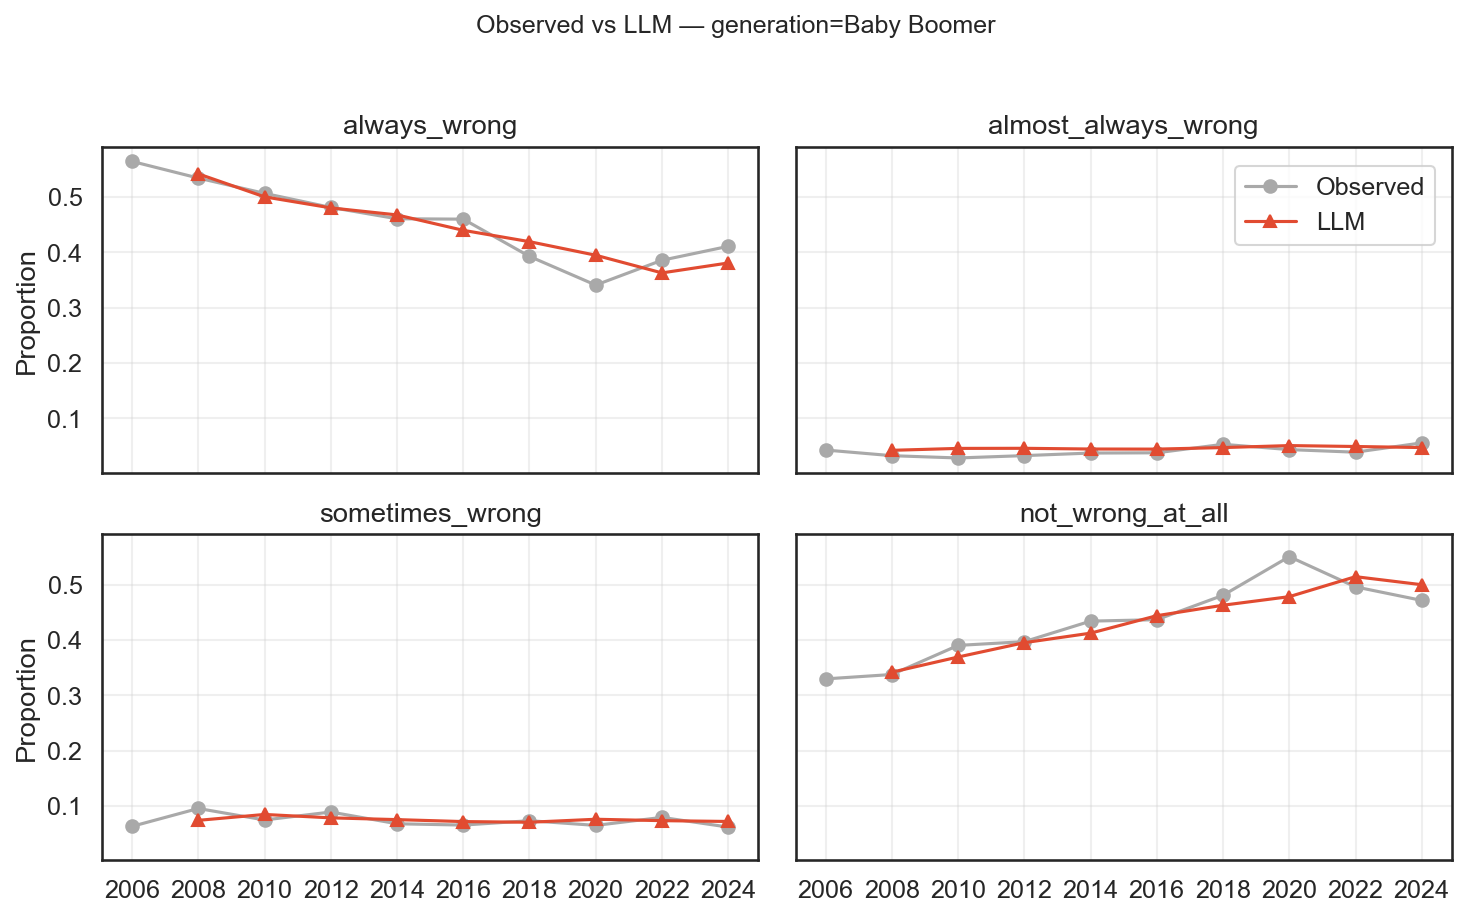

In [72]:
g = ('Baby Boomer',)
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g1, p_hat_AR_g1, p_hat_MC_g1, bt=df_pred_g1, llm_series=("hat",))

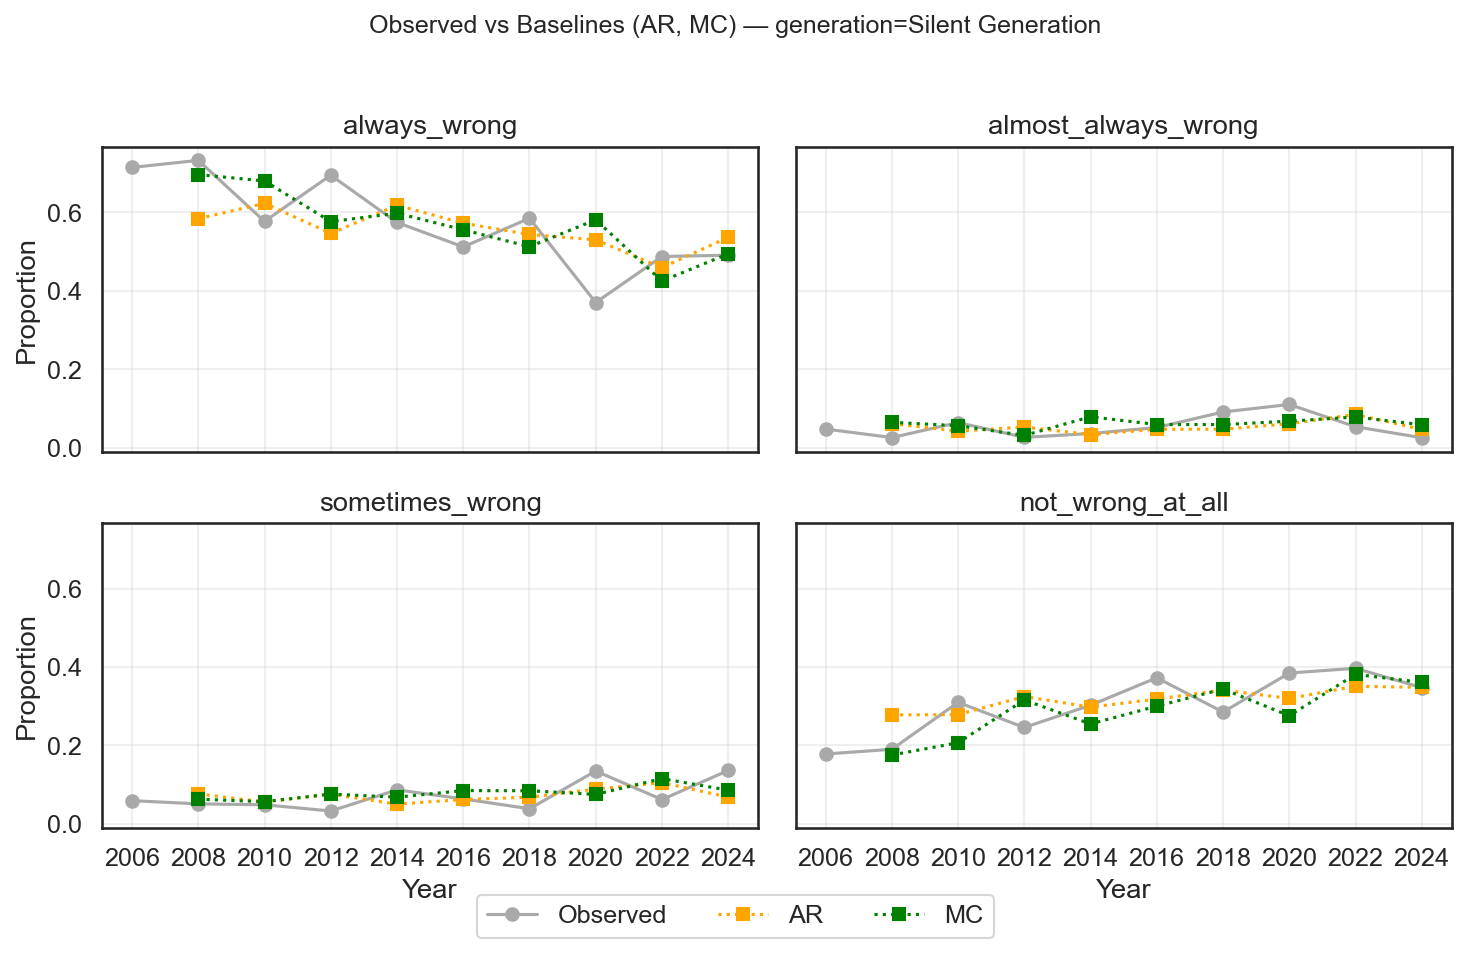

In [714]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g1, p_hat_AR_g1, p_hat_MC_g1, bt=df_pred_g1, llm_series=("hat",))

In [715]:
# Calculate weighted means and standard errors for G1
df_cs_homosex.groupby(['generation']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False)

,generation,wtssps_mean,wtssps_se
2,Generation Z,1.633026,0.063951
4,Silent Generation,0.902079,0.014580
3,Millennial,1.110948,0.014418
1,Generation X,0.985803,0.011423
0,Baby Boomer,0.899215,0.009289


In [716]:
# Compare JSD
bt_homosex_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g1.csv")

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# bt_homosex_g1['generation'] = bt_homosex_g1['generation'].map(gen_map)

bt_homosex_g1.head()

,year_t,year_t1,generation,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,0.001323,0.001258,0.001628,0.014819
1,2008,2010,Generation X,0.000812,0.000464,0.002041,0.019005
2,2008,2010,Millennial,0.009122,0.011235,0.007629,0.057873
3,2008,2010,Silent Generation,0.004327,0.005119,0.003946,0.053040
4,2010,2012,Baby Boomer,0.000722,0.001181,0.001136,0.008511


In [717]:
# Convert bench to long format
bench_homosex_g1_long = pd.melt(bench, id_vars=GROUP_COLS_1 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'MLAR', 'JSD_MC': 'MTM'}
bench_homosex_g1_long['model'] = bench_homosex_g1_long['model'].map(model_map)

# Prepare the data for plotting
bt_homosex_g1['model'] = 'LLM'
bt_homosex_g1 = bt_homosex_g1.rename(columns={'JSD_hat':'jsd'})
combined_homosex_g1 = pd.concat([bench_homosex_g1_long, bt_homosex_g1[['generation','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_homosex_g1.head()

,generation,year_t,year_t1,model,jsd
0,Baby Boomer,2006,2008,MLAR,0.003173
1,Baby Boomer,2008,2010,MLAR,0.001211
2,Baby Boomer,2010,2012,MLAR,0.000930
3,Baby Boomer,2012,2014,MLAR,0.000210
4,Baby Boomer,2014,2016,MLAR,0.000269


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3741030449.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


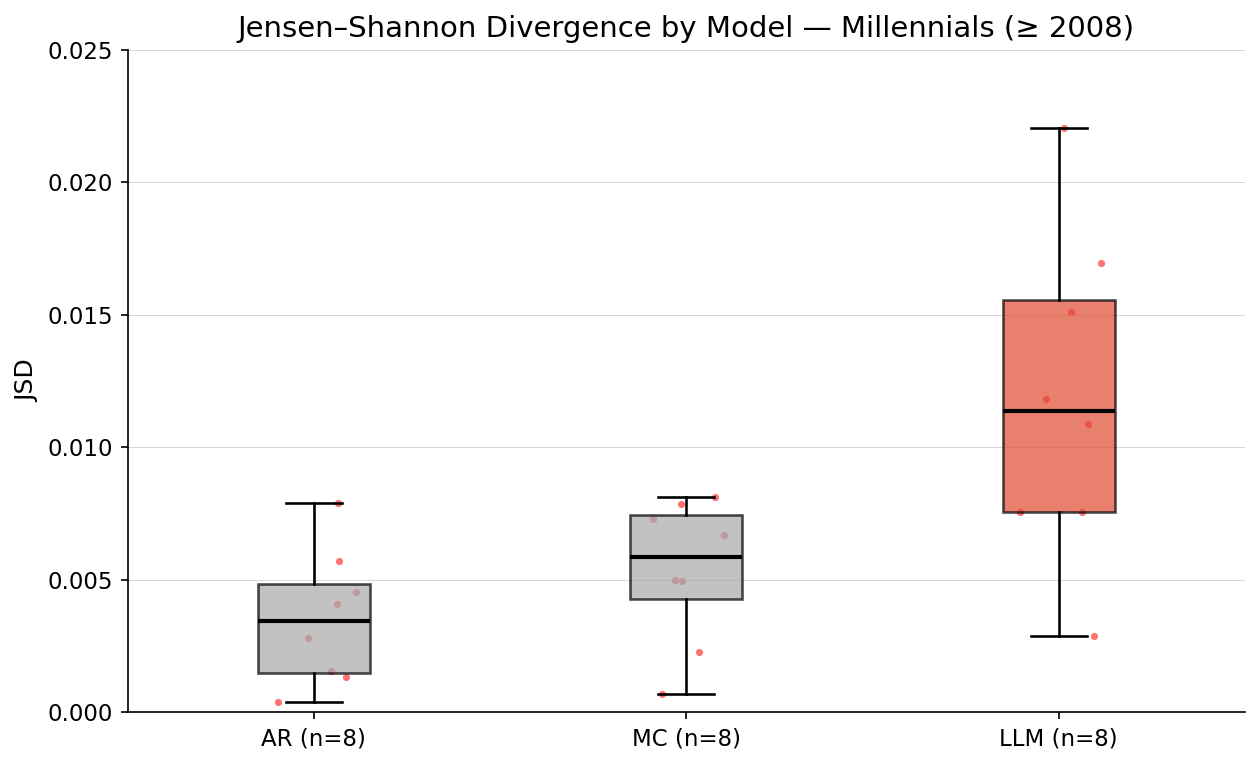

In [262]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g1[(combined_g1['generation'] == 'Millennial') & (combined_g1['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Millennials (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.025)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3189071835.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


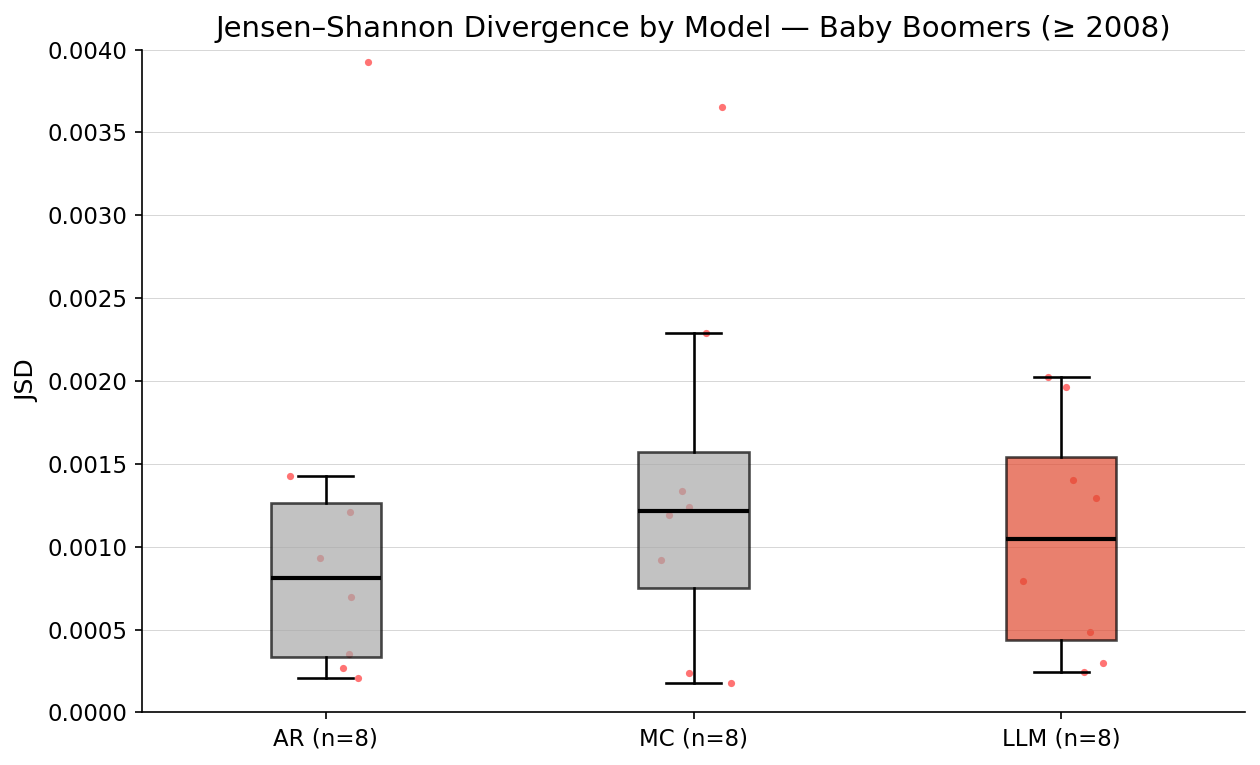

In [264]:
# Polished Matplotlib box plot for JSD (Baby Boomers), no seaborn

# --- 1) Filter & order
df = combined_g1[(combined_g1['generation'] == 'Baby Boomer') & (combined_g1['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.004)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


## Homosexuality, Group 2

In [266]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 12), (17576, 12), (13647, 12))

In [267]:
# Find p_cs and Nfrom
cs = df_cs_homosex.copy()
# Map to 4 bins if numeric:
cs = cs[cs["homosex"].isin(HOMOSEX4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_2
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=HOMOSEX4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in HOMOSEX4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g2 = {}
effN_cs_g2 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_2):
        p = weighted_probs(df_g["homosex"].tolist(), df_g["wt"].tolist(), HOMOSEX4)
        if p is None:
            continue
        p_cs_g2[(g_vals, y)] = p
        effN_cs_g2[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return HOMOSEX2ID.get(cat, None)

C_g2 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g2 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_homosex["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g2 in df_pl_homosex.groupby("yearid"):
    df_id_g2 = df_id_g2.sort_values("year")
    # collapse duplicates per year if any
    df_id_g2 = df_id_g2.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g2["year"].values.tolist()
    atts  = df_id_g2["homosex"].values.tolist()
    wgts  = df_id_g2["w"].values.astype(float).tolist()
    gens  = df_id_g2["generation"].values.tolist()
    gend  = df_id_g2["gender"].values.tolist()
    # race  = df_id_g2["race"].values.tolist()
    # edu = df_id_g2["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0])
    
    # Homosex (K=4)
    K = len(HOMOSEX4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g2[(g,t,Δ)][ai, aj] += w
        Nfrom_g2[(g,t,Δ)][ai] += w

In [268]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g2 = cs_ar_fit_and_forecast(p_cs_g2, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g2 = panel_markov_forecast(p_cs_g2, C_g2, Nfrom_g2, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g2.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_2, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g2[(g, y)]
        if (g, y) in p_hat_AR_g2:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g2[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g2:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g2[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,gender,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,2006,2008,0.004972,0.001024
1,Baby Boomer,Female,2008,2010,0.003276,0.002064
2,Baby Boomer,Female,2010,2012,0.000439,0.002310
3,Baby Boomer,Female,2012,2014,0.000386,0.001244
4,Baby Boomer,Female,2014,2016,0.000082,0.000651


In [269]:
# Load our predicted values (p-hat)
df_pred_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_homosex_g2.csv")

# Convert year 2021 to 2020
df_pred_g2.loc[df_pred_g2['year'] == 2021, 'year'] = 2020
df_pred_g2.loc[df_pred_g2['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g2['year_t'] = df_pred_g2['year_prev']
df_pred_g2['year_t1'] = df_pred_g2['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g2['generation'] = df_pred_g2['generation'].map(gen_map)

df_pred_g2.head(2)

,generation,gender,year_prev,year,p_prev_always_wrong,p_prev_almost_always_wrong,p_prev_sometimes_wrong,p_prev_not_wrong_at_all,p_trans_always_wrong,p_trans_almost_always_wrong,...,p_obs_always_wrong,p_obs_almost_always_wrong,p_obs_sometimes_wrong,p_obs_not_wrong_at_all,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,2006,2008,0.554244,0.035965,0.051555,0.358236,0.545762,0.034687,...,0.510433,0.034790,0.103366,0.351412,0.000566,0.014143,0.002554,0.000182,2006,2008
1,Baby Boomer,Female,2008,2010,0.510433,0.034790,0.103366,0.351412,0.501210,0.039967,...,0.477969,0.019573,0.070339,0.432119,0.002484,0.025332,0.003141,0.002430,2008,2010


In [270]:
df_pred_g2['year_prev'].value_counts()

year_prev
2020    17
2022    16
2016    12
2018    11
2006    10
2014    10
2010    10
2012     9
2008     9
Name: count, dtype: int64

In [271]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = HOMOSEX4

def get_group_cols(group=GROUP_COLS_2):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [272]:
# Calculate weighted means and standard errors for G2
df_cs_homosex.groupby(['generation', 'gender']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False)

,generation,gender,wtssps_mean,wtssps_se
8,Generation Z,Other,1.794381,0.567450
11,Millennial,Other,1.193623,0.286202
2,Baby Boomer,Other,0.697167,0.280150
5,Generation X,Other,0.730309,0.113607
7,Generation Z,Male,1.793754,0.103240
6,Generation Z,Female,1.484581,0.078271
13,Silent Generation,Male,0.997155,0.024369
10,Millennial,Male,1.222957,0.021981
9,Millennial,Female,1.017628,0.018876
4,Generation X,Male,1.060525,0.017952


In [273]:
df_pred_g2['generation'].value_counts()

generation
Generation X         20
Millennial           20
Baby Boomer          19
Silent Generation    18
Generation Z         10
Name: count, dtype: int64

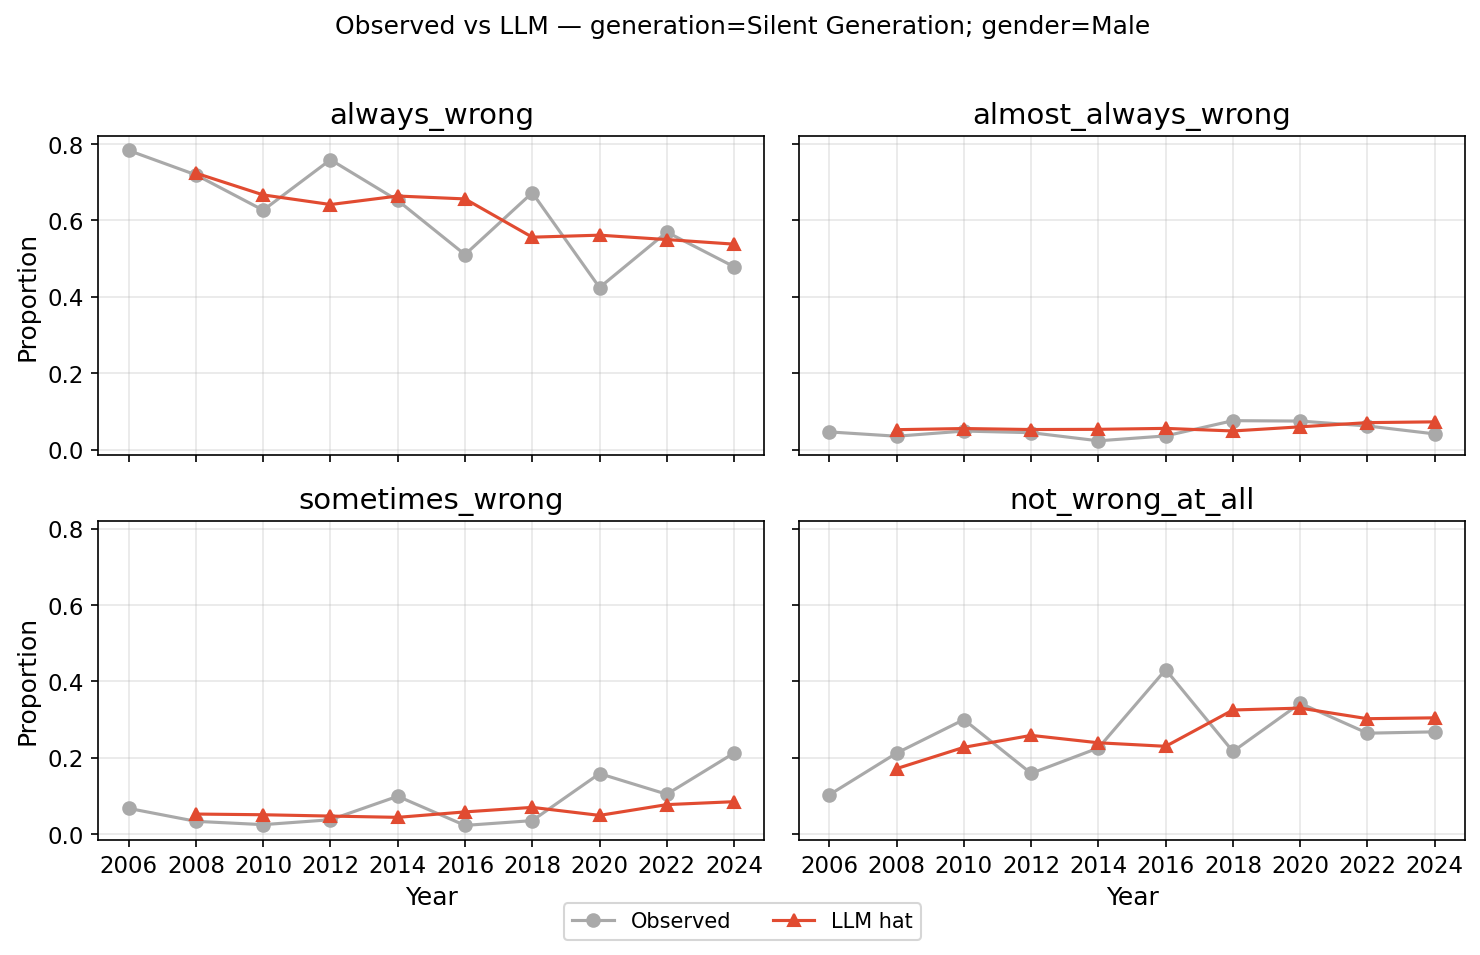

In [274]:
g = ('Silent Generation', "Male")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g2, p_hat_AR_g2, p_hat_MC_g2, bt=df_pred_g2, llm_series=("hat",))

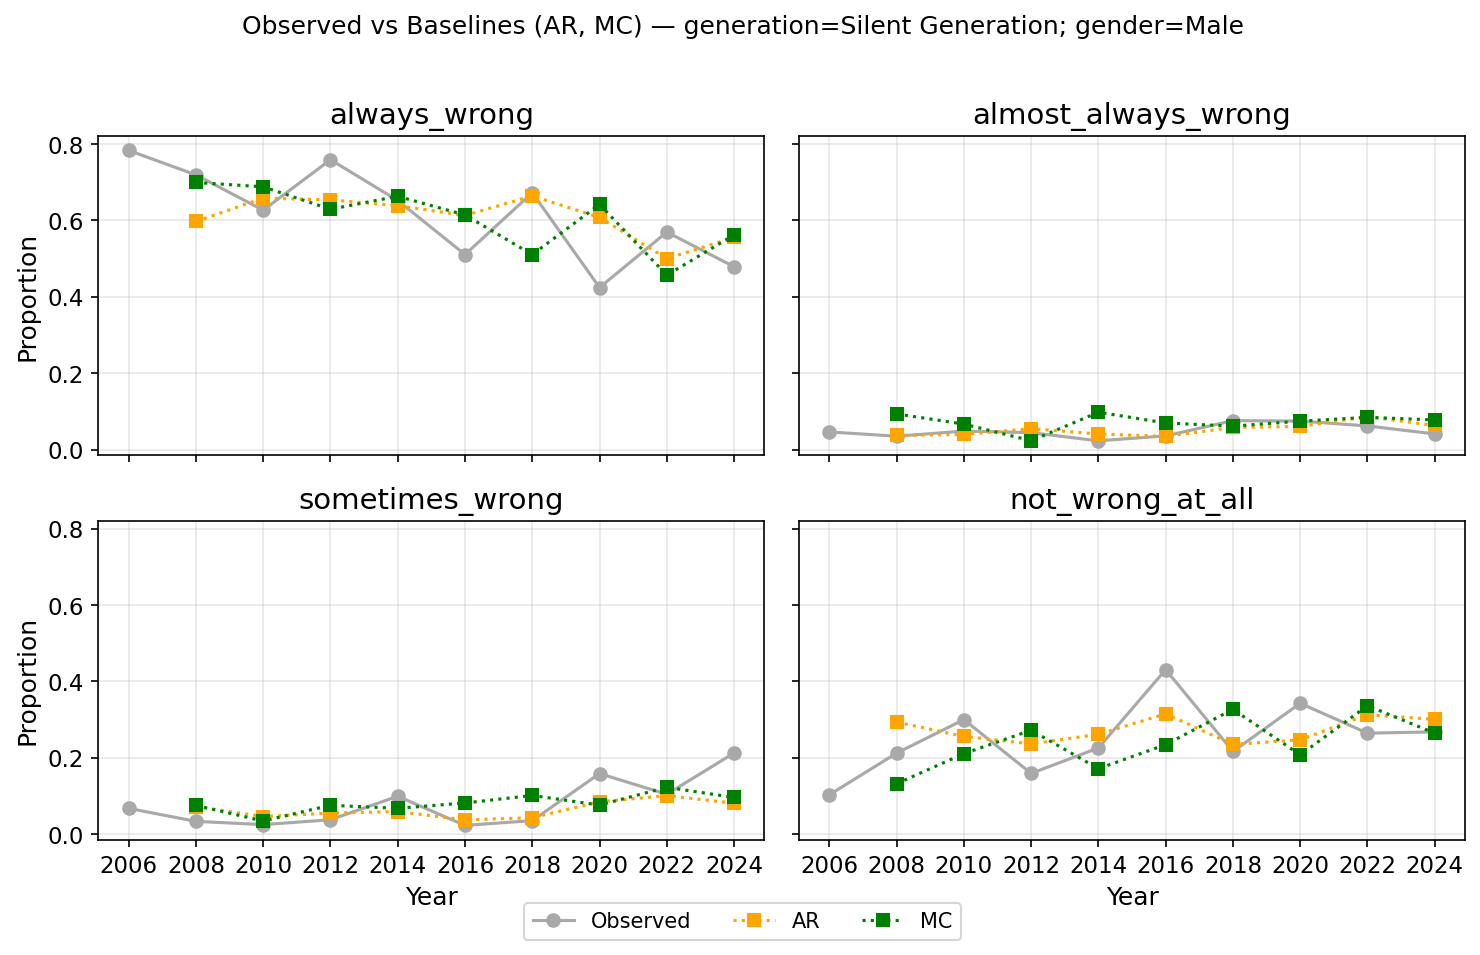

In [275]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g2, p_hat_AR_g2, p_hat_MC_g2, bt=df_pred_g2, llm_series=("hat",))

In [276]:
# Compare JSD
bt_homosex_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g2.csv")

#gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
#bt_homosex_g2['generation'] = bt_homosex_g2['generation'].map(gen_map)

bt_homosex_g2.head()

,year_t,year_t1,generation,gender,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,Female,0.002484,0.003141,0.002430,0.025332
1,2008,2010,Baby Boomer,Male,0.000178,0.000348,0.000361,0.006693
2,2008,2010,Generation X,Female,0.003052,0.004927,0.001650,0.019956
3,2008,2010,Generation X,Male,0.003277,0.001461,0.006288,0.026995
4,2008,2010,Millennial,Female,0.022822,0.019176,0.027643,0.085187


In [278]:
# Convert bench to long format
bench_long = pd.melt(bench, id_vars=GROUP_COLS_2 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'AR', 'JSD_MC': 'MC'}
bench_long['model'] = bench_long['model'].map(model_map)

# Prepare the data for plotting
bt_homosex_g2['model'] = 'LLM'
bt_homosex_g2 = bt_homosex_g2.rename(columns={'JSD_hat':'jsd'})
combined_g2 = pd.concat([bench_long, bt_homosex_g2[['generation','gender','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_g2.head()

,generation,gender,year_t,year_t1,model,jsd
0,Baby Boomer,Female,2006,2008,AR,0.004972
1,Baby Boomer,Female,2008,2010,AR,0.003276
2,Baby Boomer,Female,2010,2012,AR,0.000439
3,Baby Boomer,Female,2012,2014,AR,0.000386
4,Baby Boomer,Female,2014,2016,AR,0.000082


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3777230694.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


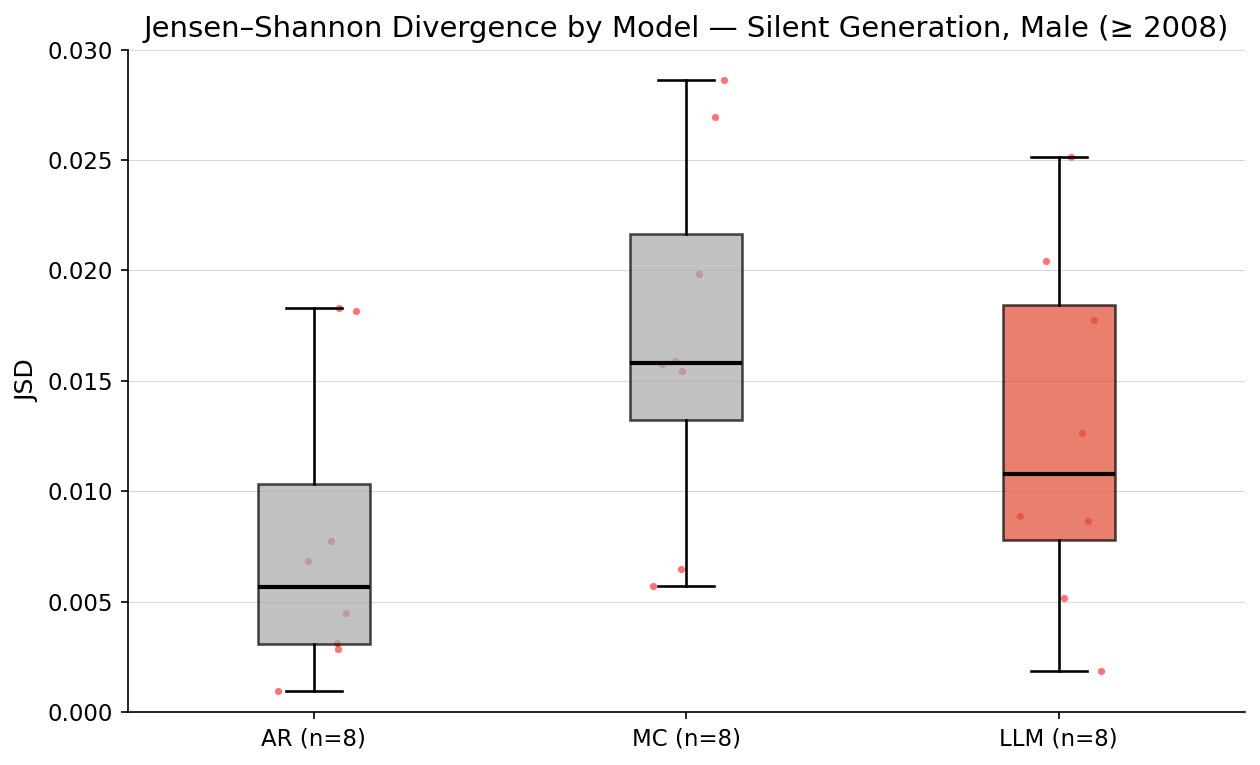

In [279]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g2[(combined_g2['generation'] == 'Silent Generation') & ((combined_g2['gender'] == 'Male')) & (combined_g2['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Silent Generation, Male (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.03)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2837227172.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


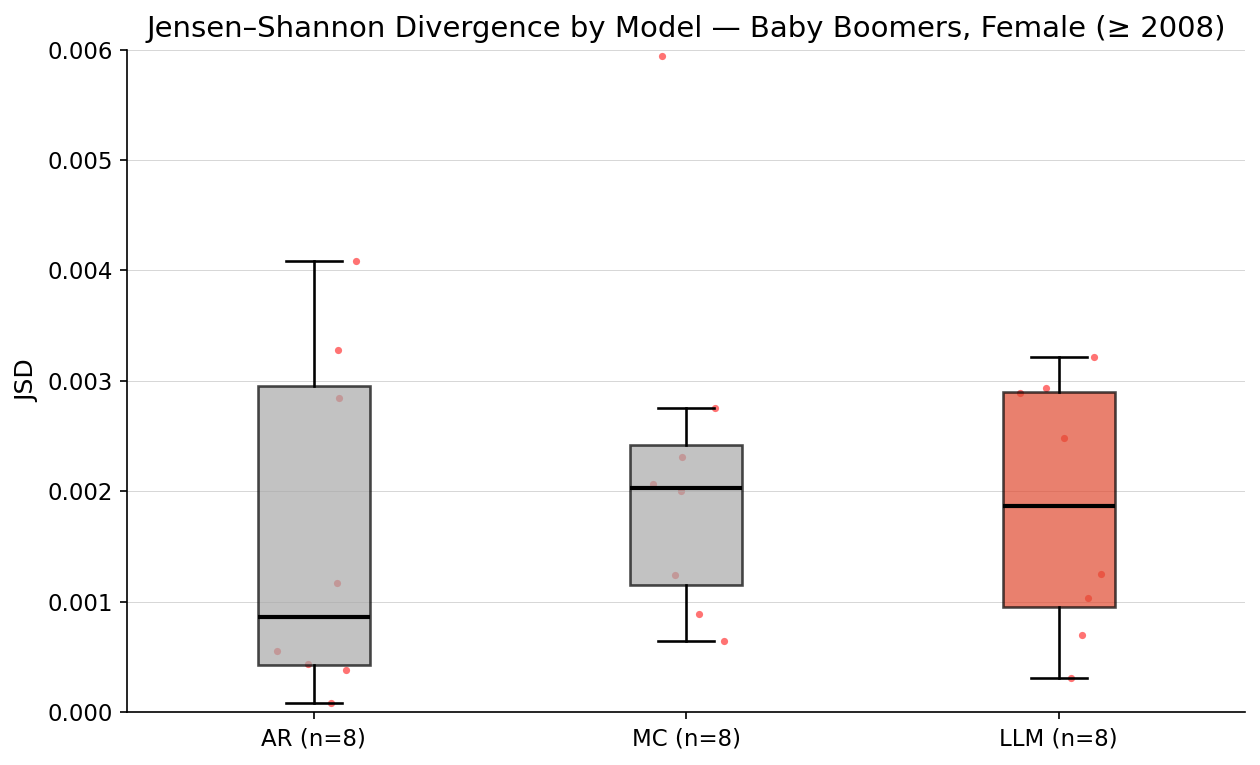

In [281]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g2[(combined_g2['generation'] == 'Baby Boomer') & ((combined_g2['gender'] == 'Female')) & (combined_g2['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers, Female (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.006)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

## Model Evaluation

In [3]:
# Compare JSD across G1 to G4
bt_abo_g4 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g4.csv")
bt_abo_g3 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g3.csv")
bt_abo_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g2.csv")
bt_abo_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g1.csv")

# Create a new column 'level' to indicate the group level
bt_abo_g4['level'] = 'Level 4'
bt_abo_g3['level'] = 'Level 3'
bt_abo_g2['level'] = 'Level 2'
bt_abo_g1['level'] = 'Level 1'

# Combine all DataFrames into one
combined_abo = pd.concat([bt_abo_g1, bt_abo_g2, bt_abo_g3, bt_abo_g4], ignore_index=True)
combined_abo.head()

,year_t,year_t1,generation,JSD_hat,JSD_trans,JSD_margin,RMSE_hat,level,gender,race,edu_level
0,2008,2010,Baby Boomer,0.002195,0.002800,0.001721,0.030900,Level 1,NaN,NaN,NaN
1,2008,2010,Generation X,0.001451,0.001850,0.001188,0.024388,Level 1,NaN,NaN,NaN
2,2008,2010,Millennial,0.000728,0.001194,0.000637,0.018293,Level 1,NaN,NaN,NaN
3,2008,2010,Silent Generation,0.006370,0.012754,0.002412,0.053817,Level 1,NaN,NaN,NaN
4,2010,2012,Baby Boomer,0.000918,0.000847,0.001008,0.019690,Level 1,NaN,NaN,NaN


In [ ]:
# # For specific subgroup analysis
# abo_lev1 = bt_abo_g1[bt_abo_g1['generation'] == 'Millennial']
# abo_lev1['level'] = 'Level 1'

# abo_lev2 = bt_abo_g2[(bt_abo_g2['generation'] == 'Millennial')&(bt_abo_g2['gender'] == 'Female')]
# abo_lev2['level'] = 'Level 2'

# abo_lev3 = bt_abo_g3[(bt_abo_g3['generation'] == 'Millennial')&(bt_abo_g3['gender'] == 'Female')&(bt_abo_g3['race'] == 'Other')]
# abo_lev3['level'] = 'Level 3'

# abo_lev4 = bt_abo_g4[(bt_abo_g4['generation'] == 'Millennial')&(bt_abo_g4['gender'] == 'Female')&(bt_abo_g4['race'] == 'Other')&(bt_abo_g4['edu_level'] == 'Less or equal to high school')]
# abo_lev4['level'] = 'Level 4'

# # Combine all levels into a single DataFrame
# combined_abo = pd.concat([abo_lev1, abo_lev2, abo_lev3, abo_lev4], ignore_index=True)


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/174463872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abo_lev1['level'] = 'Level 1'
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/174463872.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abo_lev2['level'] = 'Level 2'
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/174463872.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_8195/3220305980.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('level')['JSD_hat'].mean().reindex(level_order)


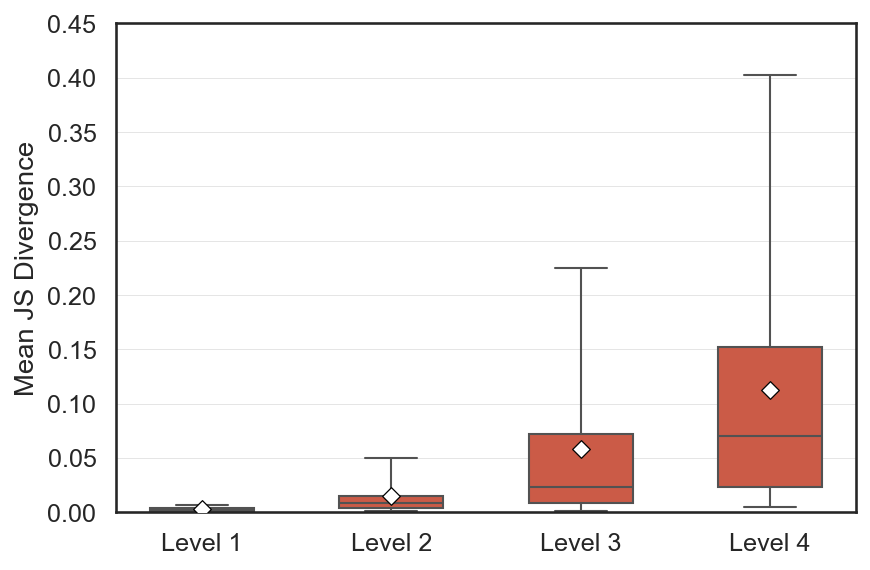

In [4]:
# Polished box plot for JSD across Levels — Millennials
# 1) Filter & order
df = combined_abo.copy()
df.dropna(subset=['generation'], inplace=True)
# if 'generation' in df.columns:
#     df = df[df['generation'].str.contains('Millennial', case=False, na=False)].copy()

# Optional: enforce a logical level order if you have one
# e.g., level_order = ['low', 'medium', 'high']
level_order = sorted(df['level'].dropna().unique().tolist())
df['level'] = pd.Categorical(df['level'], categories=level_order, ordered=True)

# # Counts per level for labels
# counts = df.groupby('level')['JSD_hat'].size().reindex(level_order, fill_value=0)
# xticklabels = [f"{lvl}\n(n={int(counts.loc[lvl])})" for lvl in level_order]

# 2) Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    x='level', y='JSD_hat', data=df,
    order=level_order, width=0.55,
    showfliers=False, whis=(5, 95), ax=ax, color='#e14b31'
)

# sns.stripplot(
#     x='level', y='JSD_hat', data=df,
#     order=level_order, color='k', alpha=0.45, size=3,
#     jitter=0.2, dodge=False, ax=ax
# )

# means as diamonds
means = df.groupby('level')['JSD_hat'].mean().reindex(level_order)
ax.scatter(
    np.arange(len(level_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label='Mean'
)

#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('Mean JS Divergence')
ax.set_ylim(0, 0.45)  # adjust as needed
#ax.set_xticklabels(xticklabels)

ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

#ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()


In [5]:
# Compare JSD across G1 to G4
bt_homosex_g4 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g4.csv")
bt_homosex_g3 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g3.csv")
bt_homosex_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g2.csv")
bt_homosex_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_homosex_g1.csv")

# Create a new column 'level' to indicate the group level
bt_homosex_g4['level'] = 'Level 4'
bt_homosex_g3['level'] = 'Level 3'
bt_homosex_g2['level'] = 'Level 2'
bt_homosex_g1['level'] = 'Level 1'

# Combine all DataFrames into one
combined_homosex = pd.concat([bt_homosex_g1, bt_homosex_g2, bt_homosex_g3, bt_homosex_g4], ignore_index=True)
combined_homosex.head()

# For specific subgroup analysis
# Combine all DataFrames into one
# homosex_lev1 = bt_homosex_g1[bt_homosex_g1['generation'] == 'Silent Generation']
# homosex_lev1['level'] = 'Level 1'

# homosex_lev2 = bt_homosex_g2[(bt_homosex_g2['generation'] == 'Silent Generation')&(bt_homosex_g2['gender'] == 'Female')]
# homosex_lev2['level'] = 'Level 2'

# homosex_lev3 = bt_homosex_g3[(bt_homosex_g3['generation'] == 'Silent Generation')&(bt_homosex_g3['gender'] == 'Female')&(bt_homosex_g3['race'] == 'Black')]
# homosex_lev3['level'] = 'Level 3'

# homosex_lev4 = bt_homosex_g4[(bt_homosex_g4['generation'] == 'Silent Generation')&(bt_homosex_g4['gender'] == 'Female')&(bt_homosex_g4['race'] == 'Black')&(bt_homosex_g4['edu_level'] == 'Less or equal to high school')]
# homosex_lev4['level'] = 'Level 4'

# # Combine all levels into a single DataFrame
# combined_homosex = pd.concat([homosex_lev1, homosex_lev2, homosex_lev3, homosex_lev4], ignore_index=True)


,year_t,year_t1,generation,JSD_hat,JSD_trans,JSD_margin,RMSE_hat,level,gender,race,edu_level
0,2008,2010,Baby Boomer,0.001323,0.001258,0.001628,0.014819,Level 1,NaN,NaN,NaN
1,2008,2010,Generation X,0.000812,0.000464,0.002041,0.019005,Level 1,NaN,NaN,NaN
2,2008,2010,Millennial,0.009122,0.011235,0.007629,0.057873,Level 1,NaN,NaN,NaN
3,2008,2010,Silent Generation,0.004327,0.005119,0.003946,0.053040,Level 1,NaN,NaN,NaN
4,2010,2012,Baby Boomer,0.000722,0.001181,0.001136,0.008511,Level 1,NaN,NaN,NaN


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_8195/699054063.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('level')['JSD_hat'].mean().reindex(level_order)


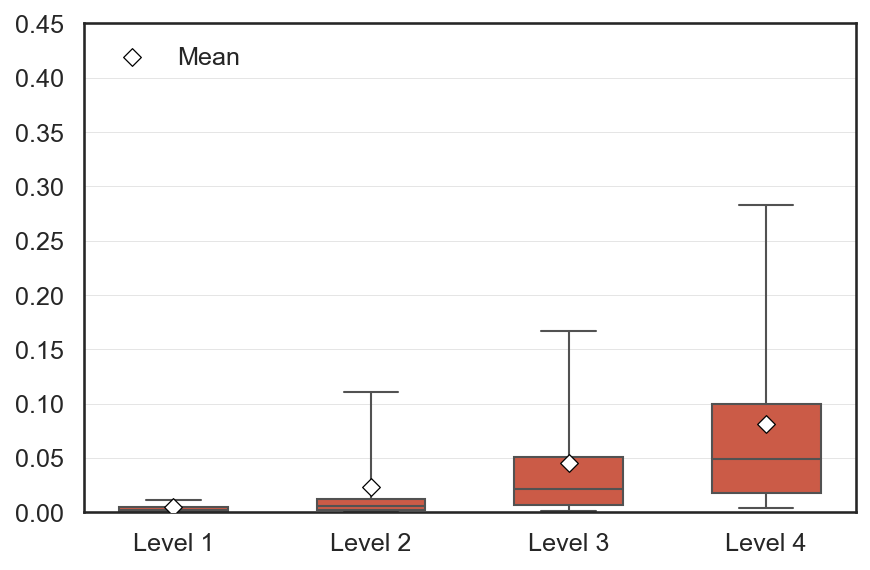

In [6]:
# Polished box plot for JSD across Levels — Millennials
# 1) Filter & order
df = combined_homosex.copy()
df.dropna(subset=['generation'], inplace=True)
# if 'generation' in df.columns:
#     df = df[df['generation'].str.contains('Silent Generation', case=False, na=False)].copy()

# Optional: enforce a logical level order if you have one
# e.g., level_order = ['low', 'medium', 'high']
level_order = sorted(df['level'].dropna().unique().tolist())
df['level'] = pd.Categorical(df['level'], categories=level_order, ordered=True)

# # Counts per level for labels
# counts = df.groupby('level')['JSD_hat'].size().reindex(level_order, fill_value=0)
# xticklabels = [f"{lvl}\n(n={int(counts.loc[lvl])})" for lvl in level_order]

# 2) Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(6, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='level', y='JSD_hat', data=df,
    order=level_order, width=0.55,
    showfliers=False, whis=(5, 95), ax=ax, color='#e14b31'
)

# # 4) Overlay jittered points to show distribution
# sns.stripplot(
#     x='level', y='JSD_hat', data=df,
#     order=level_order, color='k', alpha=0.45, size=3,
#     jitter=0.2, dodge=False, ax=ax
# )

# 5) Optional: show means as diamonds
means = df.groupby('level')['JSD_hat'].mean().reindex(level_order)
ax.scatter(
    np.arange(len(level_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label='Mean'
)

# 6) Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(0, 0.45)  # adjust as needed
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper left')

fig.tight_layout()
plt.show()

In [719]:
combined_abo_g1.shape,combined_abo_g4.shape, combined_homosex_g1.shape, combined_homosex_g4.shape

((134, 5), (1925, 8), (134, 5), (2042, 8))

In [718]:
combined_abo_g1.head()

,generation,year_t,year_t1,model,jsd
0,Baby Boomer,2006,2008,MLAR,0.000808
1,Baby Boomer,2008,2010,MLAR,0.000891
2,Baby Boomer,2010,2012,MLAR,0.000063
3,Baby Boomer,2012,2014,MLAR,0.000534
4,Baby Boomer,2014,2016,MLAR,0.000977


In [720]:
combined_abo_g4.head()

,generation,gender,race,edu_level,year_t,year_t1,model,jsd
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,MLAR,0.028272
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,MLAR,0.357902
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,MLAR,0.398768
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,MLAR,0.102151
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,MLAR,0.117836


In [732]:
# Combine all DataFrames into one
combined_abo_g1['level'] = 'Level 1'
combined_abo_g4['level'] = 'Level 4'
combined_abo_g1['topic'] = 'Abortion'
combined_abo_g4['topic'] = 'Abortion'
combined_homosex_g1['topic'] = 'Homosexuality'
combined_homosex_g4['topic'] = 'Homosexuality'
combined_homosex_g1['level'] = 'Level 1'
combined_homosex_g4['level'] = 'Level 4'
combined_abo_all = pd.concat([combined_abo_g1, combined_abo_g4], ignore_index=True)
combined_homosex_all = pd.concat([combined_homosex_g1, combined_homosex_g4], ignore_index=True)

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2710720334.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


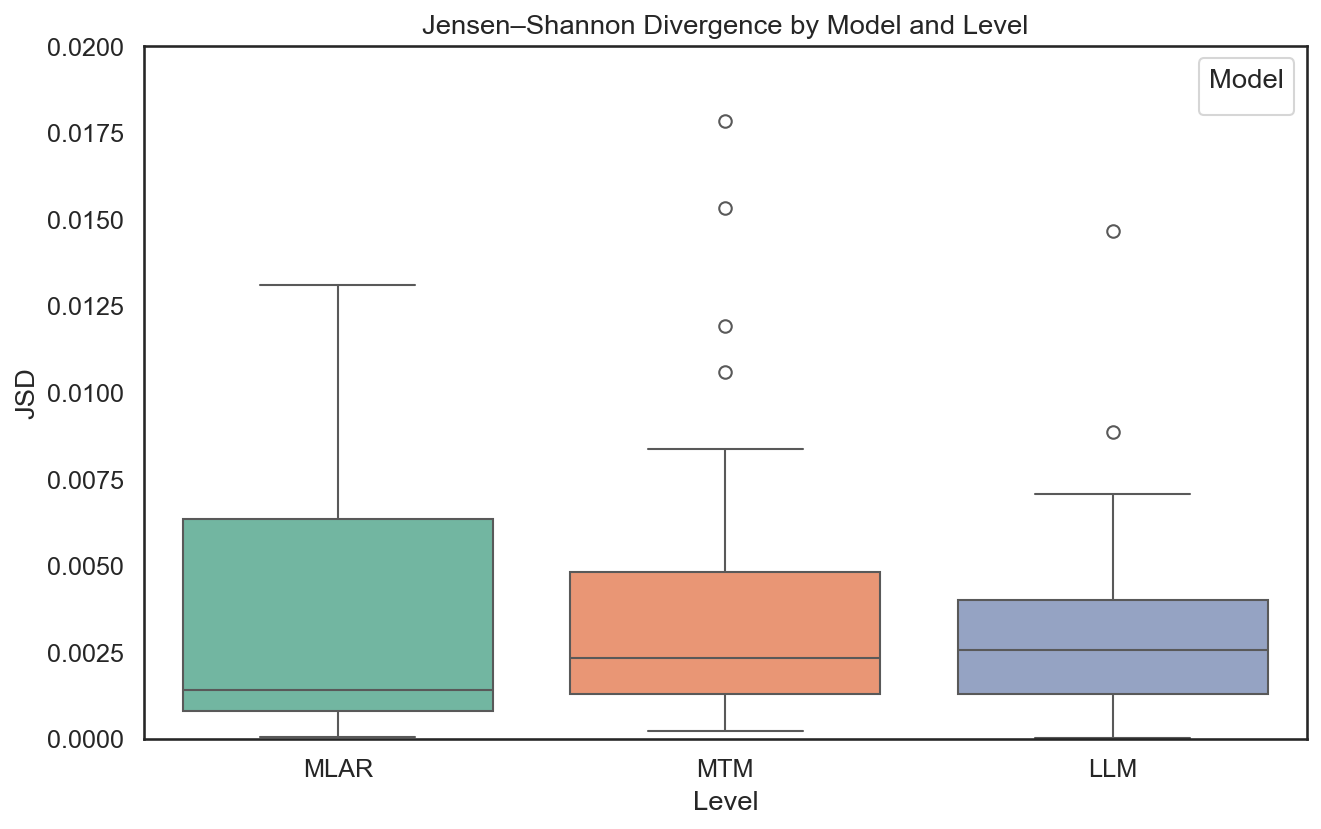

In [733]:
# Create a box plot by model for level 1
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='jsd', hue='model', data=combined_abo_all[combined_abo_all['level'] == 'Level 1'], palette='Set2')
plt.title('Jensen–Shannon Divergence by Model and Level')
plt.xlabel('Level')
plt.ylabel('JSD')
plt.ylim(0,0.02)
plt.legend(title='Model')
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1597840744.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


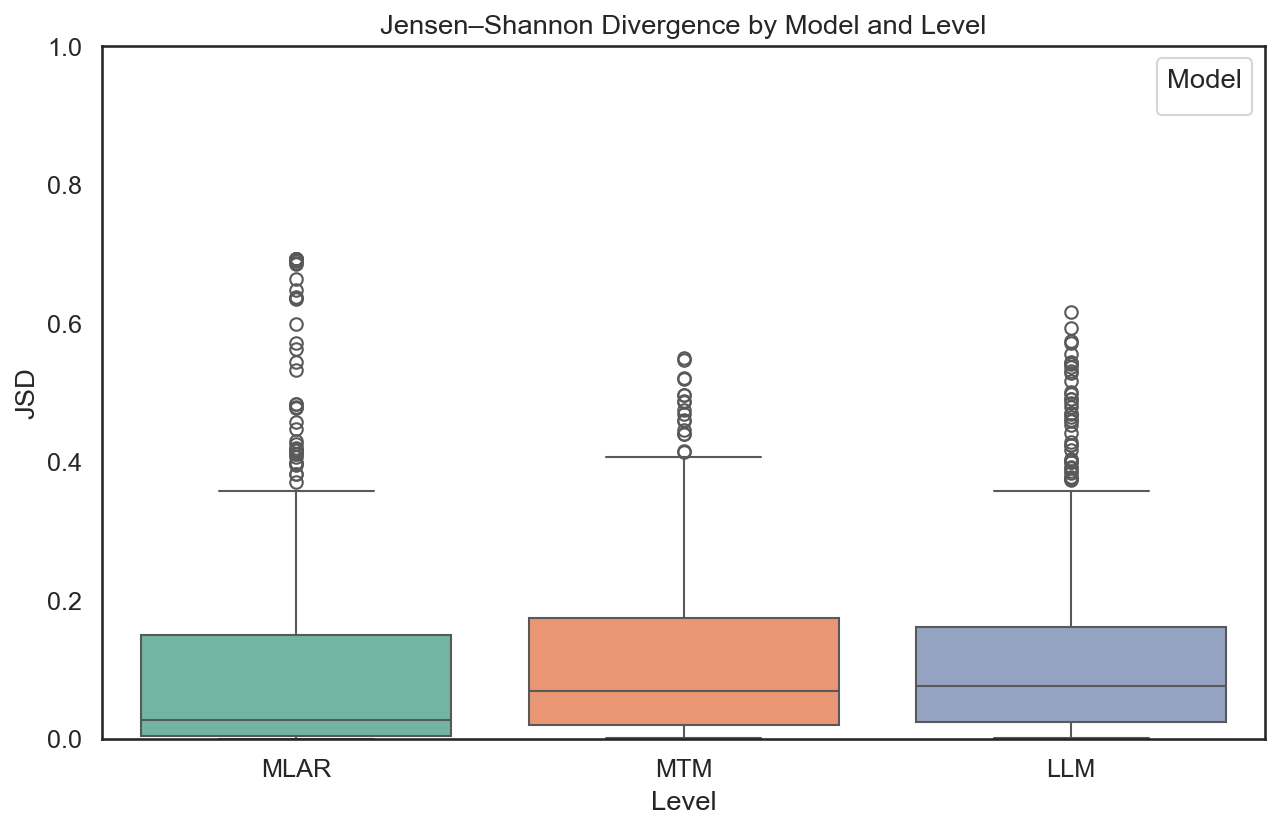

In [736]:
# Create a box plot by model for level 1
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='jsd', hue='model', data=combined_abo_all[combined_abo_all['level'] == 'Level 4'], palette='Set2')
plt.title('Jensen–Shannon Divergence by Model and Level')
plt.xlabel('Level')
plt.ylabel('JSD')
plt.ylim(0,1)
plt.legend(title='Model')
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1861468846.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


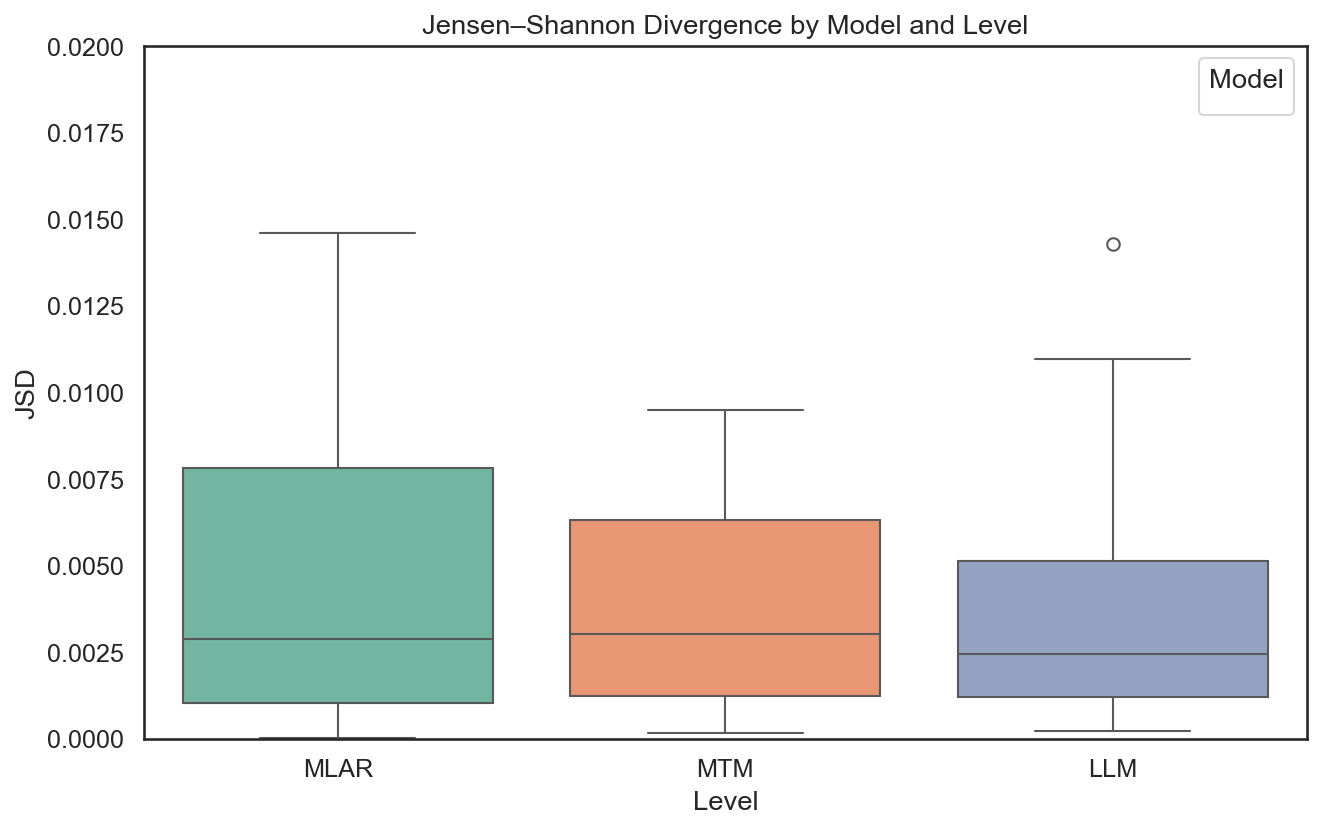

In [737]:
# Create a box plot by model for level 1
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='jsd', hue='model', data=combined_homosex_all[combined_homosex_all['level'] == 'Level 1'], palette='Set2')
plt.title('Jensen–Shannon Divergence by Model and Level')
plt.xlabel('Level')
plt.ylabel('JSD')
plt.ylim(0,0.02)
plt.legend(title='Model')
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3111358792.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


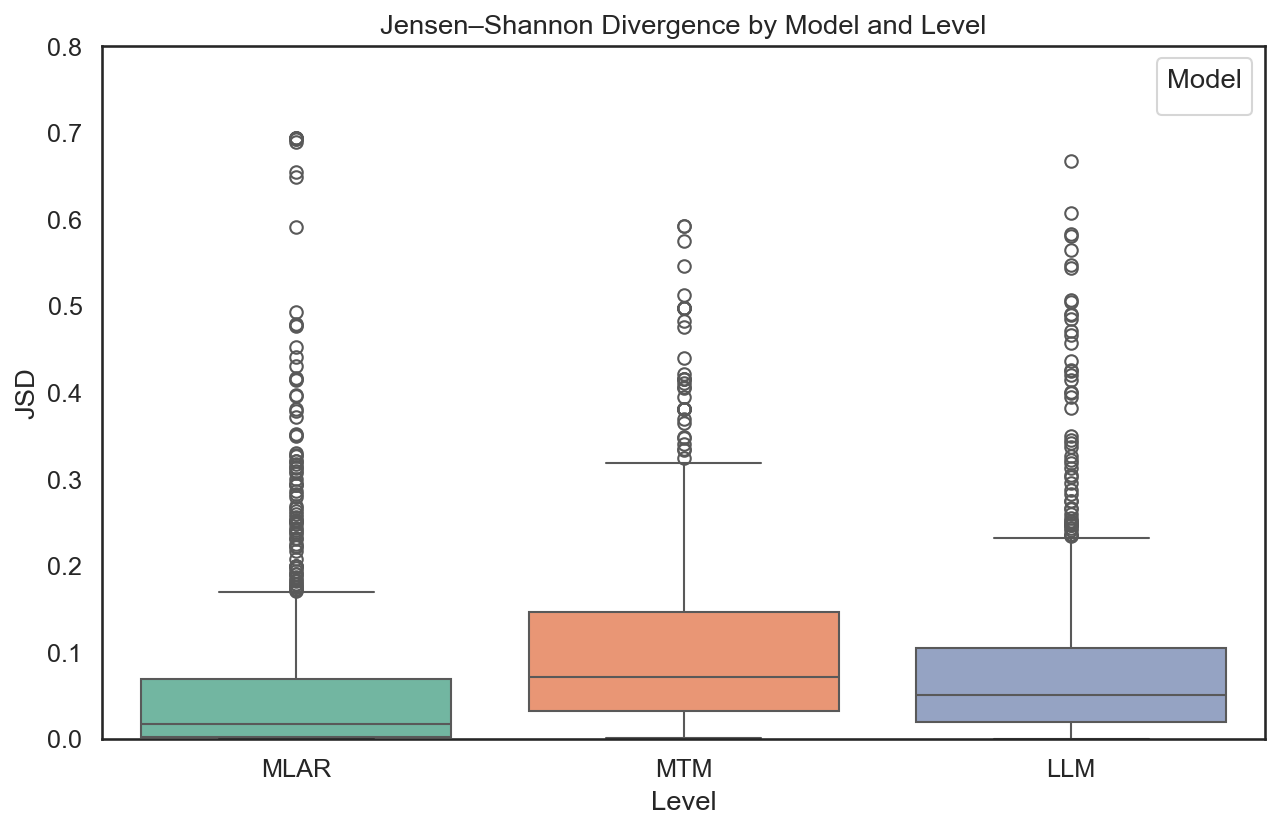

In [740]:
# Create a box plot by model for level 1
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='jsd', hue='model', data=combined_homosex_all[combined_homosex_all['level'] == 'Level 4'], palette='Set2')
plt.title('Jensen–Shannon Divergence by Model and Level')
plt.xlabel('Level')
plt.ylabel('JSD')
plt.ylim(0,0.8)
plt.legend(title='Model')
plt.show()

In [742]:
combined_abo_all[combined_abo_all['generation']=='Millennial']

,generation,year_t,year_t1,model,jsd,level,topic,gender,race,edu_level
18,Millennial,2006,2008,MLAR,0.001407,Level 1,Abortion,NaN,NaN,NaN
19,Millennial,2008,2010,MLAR,0.001502,Level 1,Abortion,NaN,NaN,NaN
20,Millennial,2010,2012,MLAR,0.001601,Level 1,Abortion,NaN,NaN,NaN
21,Millennial,2012,2014,MLAR,0.001311,Level 1,Abortion,NaN,NaN,NaN
22,Millennial,2014,2016,MLAR,0.002805,Level 1,Abortion,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2033,Millennial,2022,2024,LLM,0.208704,Level 4,Abortion,Male,Other,Associate or Bachelor's Degree
2034,Millennial,2022,2024,LLM,0.112099,Level 4,Abortion,Male,Other,Less or equal to high school
2035,Millennial,2022,2024,LLM,0.013930,Level 4,Abortion,Male,White,Associate or Bachelor's Degree
2036,Millennial,2022,2024,LLM,0.004030,Level 4,Abortion,Male,White,Graduate Degree


In [743]:
sorted(combined_abo_all['model'].dropna().unique().tolist())

['LLM', 'MLAR', 'MTM']

### Abortion, Level 1

In [777]:
df = combined_abo_all[combined_abo_all['level'] == 'Level 1'].copy()
df.dropna(subset=['generation'], inplace=True)
df.head()

,generation,year_t,year_t1,model,jsd,level,topic,gender,race,edu_level
0,Baby Boomer,2006,2008,MLAR,0.000808,Level 1,Abortion,NaN,NaN,NaN
1,Baby Boomer,2008,2010,MLAR,0.000891,Level 1,Abortion,NaN,NaN,NaN
2,Baby Boomer,2010,2012,MLAR,0.000063,Level 1,Abortion,NaN,NaN,NaN
3,Baby Boomer,2012,2014,MLAR,0.000534,Level 1,Abortion,NaN,NaN,NaN
4,Baby Boomer,2014,2016,MLAR,0.000977,Level 1,Abortion,NaN,NaN,NaN


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3488309801.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3488309801.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('model')['jsd'].mean().reindex(model_order)
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/3488309801.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='upper right')


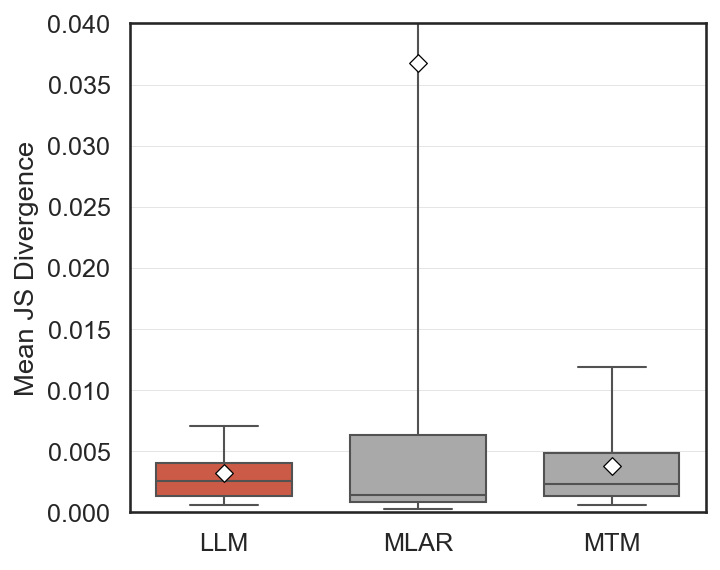

In [793]:
# Polished box plot for JSD across Models
# Filter & order
df = combined_abo_all[combined_abo_all['level'] == 'Level 1'].copy()
df.dropna(subset=['generation'], inplace=True)
# if 'generation' in df.columns:
#     df = df[df['generation'].str.contains('Millennial', case=False, na=False)].copy()

# model_order = ['LLM', 'MLAR', 'MTM']
model_order = sorted(df['model'].dropna().unique().tolist())
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)


# Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(5, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='model', y='jsd', data=df,
    order=model_order, width=0.7,
    showfliers=False, whis=(5, 95), ax=ax, palette=['#e14b31','darkgrey','darkgrey']
)

# Overlay jittered points to show distribution
# sns.stripplot(
#     x='model', y='jsd', data=df,
#     order=model_order, color='k', alpha=0.45, size=3,
#     jitter=0.2, dodge=False, ax=ax
# )

# Show means as diamonds
means = df.groupby('model')['jsd'].mean().reindex(model_order)
ax.scatter(
    np.arange(len(model_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label=''
)

# Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('Mean JS Divergence')
ax.set_ylim(0, 0.04)  # adjust as needed
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()

### Abortion, Level 4

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2885221006.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/2885221006.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('model')['jsd'].mean().reindex(model_order)


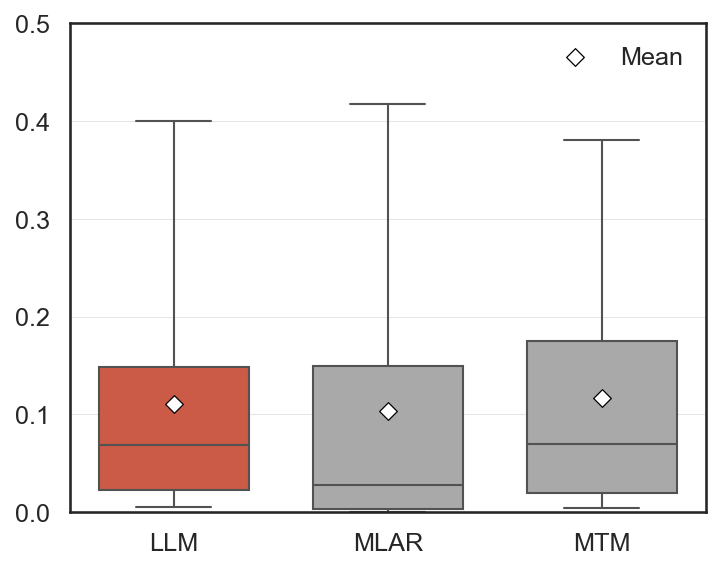

In [795]:
# Polished box plot for JSD across Models
# Filter & order
df = combined_abo_all[combined_abo_all['level'] == 'Level 4'].copy()
df.dropna(inplace=True)
# if 'generation' in df.columns:
#     df = df[df['generation'].str.contains('Millennial', case=False, na=False)].copy()

# model_order = ['LLM', 'MLAR', 'MTM']
model_order = sorted(df['model'].dropna().unique().tolist())
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)


# Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(5, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='model', y='jsd', data=df,
    order=model_order, width=0.7,
    showfliers=False, whis=(5, 95), ax=ax, palette=['#e14b31','darkgrey','darkgrey']
)

# Overlay jittered points to show distribution
# sns.stripplot(
#     x='model', y='jsd', data=df,
#     order=model_order, color='k', alpha=0.45, size=3,
#     jitter=0.2, dodge=False, ax=ax
# )

# Show means as diamonds
means = df.groupby('model')['jsd'].mean().reindex(model_order)
ax.scatter(
    np.arange(len(model_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label='Mean'
)

# Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(0, 0.5)  # adjust as needed
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()

### Abortion, Level 1, Millennial

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1451748595.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1451748595.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('model')['jsd'].mean().reindex(model_order)


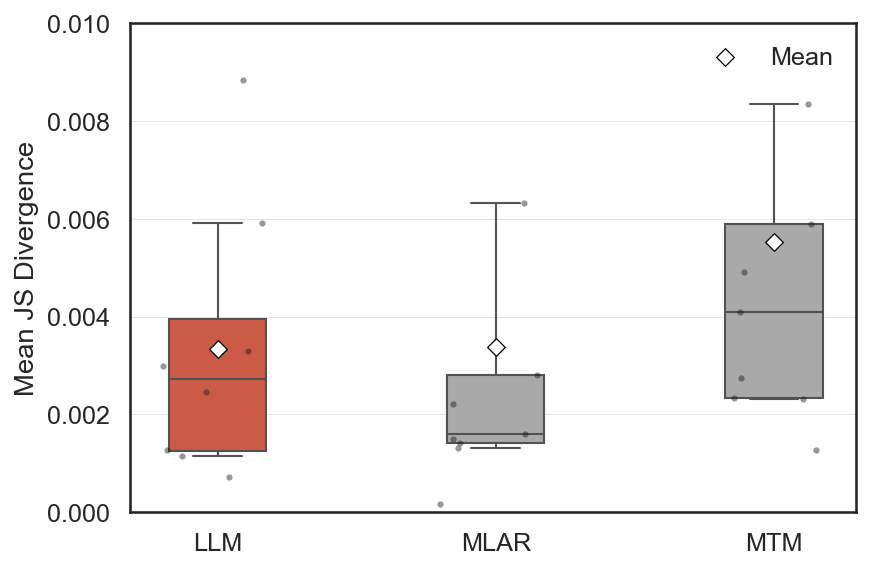

In [760]:
# Polished box plot for JSD across Models
# Filter & order
df = combined_abo_all[combined_abo_all['level'] == 'Level 1'].copy()
if 'generation' in df.columns:
    df = df[df['generation'].str.contains('Millennial', case=False, na=False)].copy()

# model_order = ['LLM', 'MLAR', 'MTM']
model_order = sorted(df['model'].dropna().unique().tolist())
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)


# Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(6, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='model', y='jsd', data=df,
    order=model_order, width=0.35,
    showfliers=False, whis=(5, 95), ax=ax, palette=['#e14b31','darkgrey','darkgrey']
)

# 4) Overlay jittered points to show distribution
sns.stripplot(
    x='model', y='jsd', data=df,
    order=model_order, color='k', alpha=0.45, size=3,
    jitter=0.2, dodge=False, ax=ax
)

# 5) Optional: show means as diamonds
means = df.groupby('model')['jsd'].mean().reindex(model_order)
ax.scatter(
    np.arange(len(model_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label='Mean'
)

# Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('Mean JS Divergence')
ax.set_ylim(0, 0.01)  # adjust as needed
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()

### Abortion, Level 1, Silent Generation

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/975122163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/975122163.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('model')['jsd'].mean().reindex(model_order)


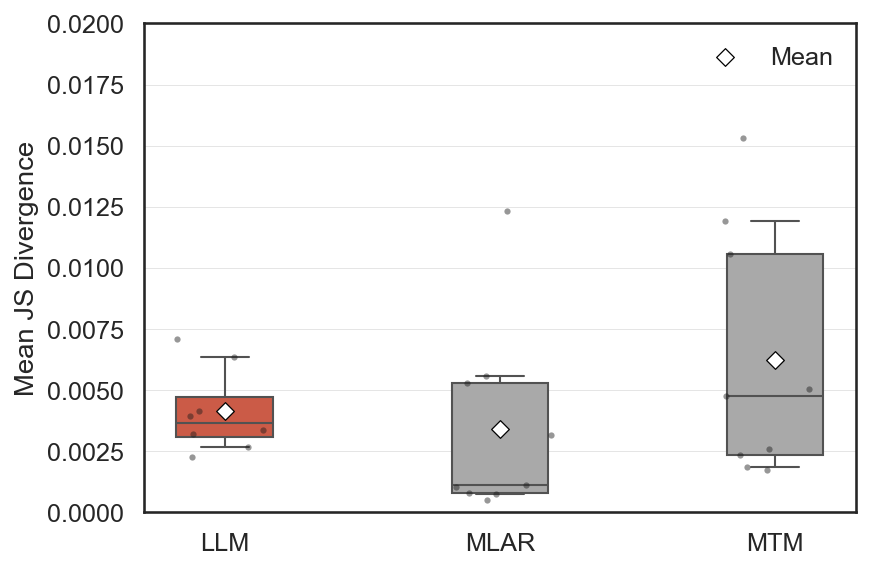

In [763]:
# Polished box plot for JSD across Models
# Filter & order
df = combined_abo_all[combined_abo_all['level'] == 'Level 1'].copy()
if 'generation' in df.columns:
    df = df[df['generation'].str.contains('Silent Generation', case=False, na=False)].copy()

# model_order = ['LLM', 'MLAR', 'MTM']
model_order = sorted(df['model'].dropna().unique().tolist())
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)


# Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(6, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='model', y='jsd', data=df,
    order=model_order, width=0.35,
    showfliers=False, whis=(5, 95), ax=ax, palette=['#e14b31','darkgrey','darkgrey']
)

# 4) Overlay jittered points to show distribution
sns.stripplot(
    x='model', y='jsd', data=df,
    order=model_order, color='k', alpha=0.45, size=3,
    jitter=0.2, dodge=False, ax=ax
)

# 5) Optional: show means as diamonds
means = df.groupby('model')['jsd'].mean().reindex(model_order)
ax.scatter(
    np.arange(len(model_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label='Mean'
)

# Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('Mean JS Divergence')
ax.set_ylim(0, 0.02)  # adjust as needed
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()

### Abortion, Level 4, Millennial, Female, Other, Highschool or less

In [769]:
combined_abo_all

,generation,year_t,year_t1,model,jsd,level,topic,gender,race,edu_level
0,Baby Boomer,2006,2008,MLAR,0.000808,Level 1,Abortion,NaN,NaN,NaN
1,Baby Boomer,2008,2010,MLAR,0.000891,Level 1,Abortion,NaN,NaN,NaN
2,Baby Boomer,2010,2012,MLAR,0.000063,Level 1,Abortion,NaN,NaN,NaN
3,Baby Boomer,2012,2014,MLAR,0.000534,Level 1,Abortion,NaN,NaN,NaN
4,Baby Boomer,2014,2016,MLAR,0.000977,Level 1,Abortion,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2054,NaN,2022,2024,LLM,0.271962,Level 4,Abortion,Male,Other,Less or equal to high school
2055,NaN,2022,2024,LLM,0.400103,Level 4,Abortion,Male,White,Associate or Bachelor's Degree
2056,NaN,2022,2024,LLM,0.094679,Level 4,Abortion,Male,White,Graduate Degree
2057,NaN,2022,2024,LLM,0.090693,Level 4,Abortion,Male,White,Less or equal to high school


In [768]:
df = combined_abo_all[(combined_abo_all['generation'] == 'Millennial') & (combined_abo_all['gender'] == 'Female') & (combined_abo_all['race'] == 'Other') & (combined_abo_all['edu_level'] == 'Less than equal to high school')].copy()
df.head()

,generation,year_t,year_t1,model,jsd,level,topic,gender,race,edu_level


### Homosexuality, Level 1

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/433515432.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/433515432.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('model')['jsd'].mean().reindex(model_order)
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/433515432.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='upper right')


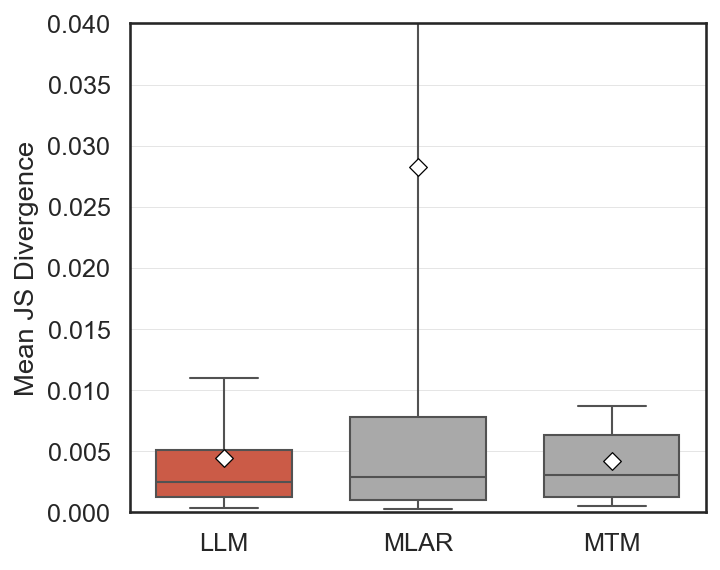

In [796]:
# Polished box plot for JSD across Models
# Filter & order
df = combined_homosex_all[combined_homosex_all['level'] == 'Level 1'].copy()
df.dropna(subset=['generation'], inplace=True)
# if 'generation' in df.columns:
#     df = df[df['generation'].str.contains('Millennial', case=False, na=False)].copy()

# model_order = ['LLM', 'MLAR', 'MTM']
model_order = sorted(df['model'].dropna().unique().tolist())
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)


# Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(5, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='model', y='jsd', data=df,
    order=model_order, width=0.7,
    showfliers=False, whis=(5, 95), ax=ax, palette=['#e14b31','darkgrey','darkgrey']
)

# Overlay jittered points to show distribution
# sns.stripplot(
#     x='model', y='jsd', data=df,
#     order=model_order, color='k', alpha=0.45, size=3,
#     jitter=0.2, dodge=False, ax=ax
# )

# Show means as diamonds
means = df.groupby('model')['jsd'].mean().reindex(model_order)
ax.scatter(
    np.arange(len(model_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label=''
)

# Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('Mean JS Divergence')
ax.set_ylim(0, 0.04)  # adjust as needed
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()

### Homosexuality, Level 4

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/166601077.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/166601077.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('model')['jsd'].mean().reindex(model_order)
/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/166601077.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='upper right')


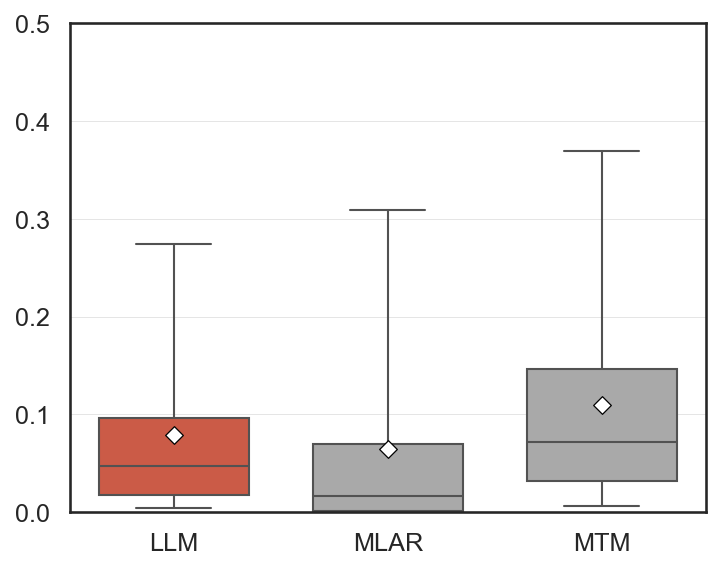

In [801]:
# Polished box plot for JSD across Models
# Filter & order
df = combined_homosex_all[combined_homosex_all['level'] == 'Level 4'].copy()
df.dropna(inplace=True)
# if 'generation' in df.columns:
#     df = df[df['generation'].str.contains('Millennial', case=False, na=False)].copy()

# model_order = ['LLM', 'MLAR', 'MTM']
model_order = sorted(df['model'].dropna().unique().tolist())
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)


# Style
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150})

fig, ax = plt.subplots(figsize=(5, 4))

# 3) Boxplot (clean)
sns.boxplot(
    x='model', y='jsd', data=df,
    order=model_order, width=0.7,
    showfliers=False, whis=(5, 95), ax=ax, palette=['#e14b31','darkgrey','darkgrey']
)

# Overlay jittered points to show distribution
# sns.stripplot(
#     x='model', y='jsd', data=df,
#     order=model_order, color='k', alpha=0.45, size=3,
#     jitter=0.2, dodge=False, ax=ax
# )

# Show means as diamonds
means = df.groupby('model')['jsd'].mean().reindex(model_order)
ax.scatter(
    np.arange(len(model_order)), means.values,
    marker='D', s=36, zorder=3, linewidths=0.6, edgecolors='black', facecolors='white',
    label=''
)

# Titles, labels, limits, and polish
#ax.set_title('Jensen–Shannon Divergence across Levels — Millennials')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(0, 0.5)  # adjust as needed
# ax.set_yticks([0.001, 0.100, 0.200, 0.300, 0.400, 0.500])
# ax.set_yticklabels([0.001, 0.100, 0.200, 0.300, 0.400, 0.500])
#ax.set_xticklabels(xticklabels)

# Subtle, readable grid
ax.yaxis.grid(True, linestyle='-', linewidth=0.4, alpha=0.6)
# ax.xaxis.grid(False)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# Legend (optional)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
plt.show()